# Injury Severity Prediction for Road Casualties in Great Britain: Comparing Linear and Ensemble Classifiers on STATS19 Administrative Data

**Author:** Umrah- 20793907

**Module:** COMP4030 Data Science with Machine Learning  

### Research question

This project investigates whether administrative collision-record features from the 2023 Great Britain STATS19 road safety dataset can be used to predict whether a road casualty outcome is severe. In this notebook, a severe outcome is defined as either fatal or serious injury, while slight injury is treated as the non-severe class.

**Main research question:**  
Can administrative collision-record features predict severe casualty outcomes
in Great Britain, and which factors drive these predictions?

- **Sub-question 1:**  
Do tuned tree-based ensemble models, specifically Random Forest and XGBoost, outperform a regularised logistic regression baseline on imbalanced casualty-severity data?

- **Sub-question 2 :**
Which original STATS19 feature groups contribute most strongly to the final XGBoost model’s predictions of Severe casualty outcomes, as measured by grouped mean absolute SHAP values?


- **Sub-question 3 / sensitivity analysis:**  
Does random oversampling using RandomOverSampler improve severe-class detection compared with cost-sensitive XGBoost?


This is a post-collision administrative prediction task: the aim is not to predict a collision before it occurs, but to assess whether recorded collision and casualty characteristics can distinguish severe from slight casualty outcomes.

> Files can be downloaded from: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data

**Reference:** Department for Transport. (2024). *Road Safety Data 2023* (STATS19).

## Section 1: Environment Setup

In [1]:
#!pip install xgboost
#!pip install shap

In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
import matplotlib.ticker as mticker

#ML Libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, average_precision_score
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Reproducbility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Display
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

print("Environment ready.")

Environment ready.


In [3]:
#Add package version
import sklearn
import xgboost
import sys

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("shap:", shap.__version__)

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1
xgboost: 3.2.0
shap: 0.51.0


In [4]:
#Configuring the Style
## Severity colours are used consistently across plots to improve interpretability.
#Consistent palette used throughout the notebook
FATAL_COL= "#E63946"   # red
SERIOUS_COL = "#F4A261"   # amber
SLIGHT_COL= "#457B9D"   # steel blue
ACCENT_COL= "#A8DADC"   # light teal (used for neutral bars / highlights)
SEVERE_COL = "#E63946"   # used for binary severe class in EDA

BIN_PALETTE = {"Severe": SEVERE_COL, "Slight": SLIGHT_COL}
SEV_PALETTE = {"Fatal":   FATAL_COL,"Serious": SERIOUS_COL,"Slight":  SLIGHT_COL,}

# Base matplotlib style
plt.rcParams.update({
    "figure.facecolor":"#F7F9FB",
    "axes.facecolor":"#F7F9FB",
    "axes.edgecolor":"#CCCCCC",
    "axes.linewidth":0.8,
    "axes.grid":True,
    "axes.spines.top":False,
    "axes.spines.right": False,
    "grid.color":"#E0E0E0",
    "grid.linestyle":"--",
    "grid.linewidth":0.6,
    "font.family":"DejaVu Sans",
    "font.size":10,
    "axes.titlesize":12,
    "axes.titleweight":"bold",
    "axes.labelsize":10,
    "xtick.labelsize":9,
    "ytick.labelsize":9,
    "legend.frameon":True,
    "legend.framealpha": 0.9,
    "legend.edgecolor":"#CCCCCC",
    "figure.dpi":120,
})

print("Style configured.")

Style configured.


## SECTION 2: Data Loading and Inspection
This section loads the three STATS19 tables used in the project: collisions, vehicles, and casualties. The tables are inspected separately before merging because they represent different observational levels. The collision table contains one record per collision, while the vehicle and casualty tables can contain multiple records for the same collision. Checking table sizes, columns, data types, and key fields at this stage supports reproducibility and reduces the risk of incorrect joins later in the workflow.

In [5]:
#Load CSV file
#Low-memory = False helps pandas infer column data types more consistently
collisions = pd.read_csv("dft-road-casualty-statistics-collision-2023.csv", low_memory=False)
vehicles = pd.read_csv("dft-road-casualty-statistics-vehicle-2023.csv", low_memory=False)
casualties  = pd.read_csv("dft-road-casualty-statistics-casualty-2023.csv", low_memory=False)

#Print the dimension of each dataset
print(f"Collisions: {collisions.shape}")
print(f"Vehicles:{vehicles.shape}")
print(f"Casualties: {casualties.shape}")

Collisions: (104258, 44)
Vehicles:(189815, 32)
Casualties: (132977, 23)


The three datasets loaded successfully. The collision table contains 104,258 records, the vehicle table contains 189,815 records, and the casualty table contains 132,977 records. The larger size of the vehicle and casualty tables is expected because a single collision can involve multiple vehicles and multiple casualties.

In [6]:
# Preview the first few rows of each dataset.
# This helps us understand the structure and coding of the variables.
print("Collision Data")
display(collisions.head(3))
print("Vehicle Data")
display(vehicles.head(3))
print("Casualty Data")
display(casualties.head(3))

Collision Data


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail_historic,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control_historic,pedestrian_crossing_physical_facilities_historic,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2023170L30453,2023,170L30453,456584.0,522423.0,-1.125794,54.593835,17,3,3,1,21/05/2023,1,18:00,-1,E06000003,E06000003,E06000003,3,1085,6,60,0,0,-1,0,-1,0,0,0,1,1,1,4,0,13,2,2,2,E01032560,-1,0,0.014215,0.985785
1,2023111293075,2023,111293075,434218.0,514041.0,-1.472891,54.520515,11,3,1,1,28/03/2023,3,15:00,-1,E06000005,E06000005,E06000005,6,0,6,30,0,0,-1,0,-1,0,0,0,1,1,1,0,0,0,2,1,2,E01012346,3,1,0.000000,1.000000
2,2023111312748,2023,111312748,430616.0,514267.0,-1.528511,54.522776,11,2,2,1,21/05/2023,1,23:30,-1,E06000005,E06000005,E06000005,4,6280,6,30,9,19,2,6,0,0,0,0,4,1,1,0,0,0,1,3,2,E01012319,7,1,1.000000,0.000000


Vehicle Data


,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane_historic,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver_historic,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2023481356437,2023,481356437,1,9,0,9,9,1,7,0,0,8,0,0,0,0,3,1,2,2,1,26,6,5935,1,9,-1,-1,-1,0,-1
1,2023440059930,2023,440059930,1,9,0,18,19,6,2,0,0,1,0,0,0,0,3,1,6,6,1,35,6,5340,1,23,-1,7,E01027771,0,-1
2,2023401356150,2023,401356150,1,9,0,11,11,4,7,0,0,8,0,0,0,0,2,1,6,6,3,-1,-1,5340,1,23,-1,-1,-1,0,-1


Casualty Data


,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2023201345434,2023,201345434,1,1,3,1,72,10,3,5,3,0,0,0,0,1,E01009409,3,1,0.00000,1.00000,-1
1,2023522400767,2023,522400767,2,1,1,1,18,4,3,0,0,0,0,0,1,1,E01014486,-1,0,0.07249,0.92751,-1
2,2023010425559,2023,010425559,1,1,1,1,21,5,3,0,0,0,0,0,3,3,E01001391,-1,0,0.00000,1.00000,-1


In [7]:
# Inspect data types and non-null counts for each table.
# Spot missing values, coded variables, and potential preprocessing issues.
print("\n Collision Info")
collisions.info()
print("\n Vehicle Info")
vehicles.info()
print("\n Casualty Info ")
casualties.info()


 Collision Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104258 entries, 0 to 104257
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   104258 non-null  object 
 1   collision_year                                    104258 non-null  int64  
 2   collision_ref_no                                  104258 non-null  object 
 3   location_easting_osgr                             104246 non-null  float64
 4   location_northing_osgr                            104246 non-null  float64
 5   longitude                                         104246 non-null  float64
 6   latitude                                          104246 non-null  float64
 7   police_force                                      104258 non-null  int64  
 8   collision_severity                                104258 non-null  

In [8]:
# Key column checks
# Check that the columns needed for joining and target construction are present.
# These checks reduce the risk of silent merge errors later in the workflow.
checks = {
    "collision_index in collisions": "collision_index" in collisions.columns,
    "collision_index in vehicles": "collision_index" in vehicles.columns,
    "collision_index in casualties": "collision_index" in casualties.columns,
    "vehicle_reference in vehicles": "vehicle_reference" in vehicles.columns,
    "vehicle_reference in casualties": "vehicle_reference" in casualties.columns,
    "collision_severity in collisions": "collision_severity" in collisions.columns,
    "casualty_severity in casualties": "casualty_severity" in casualties.columns,
}

print("Key column presence checks:")
for desc, result in checks.items():
    mark = "PRESENT" if result else "MISSING"
    print(f"{mark}: {desc}")

# Check the expected uniqueness structure of the three linked tables.
# The collision table should have one row per collision.
# The vehicle and casualty tables can contain multiple rows per collision.

print("\nUniqueness checks:")
print(f"collision_index unique in collisions: {collisions['collision_index'].is_unique}")
print(f"collision_index unique in vehicles: {vehicles['collision_index'].is_unique}  expected False")
print(f"collision_index unique in casualties: {casualties['collision_index'].is_unique}  expected False")

print(
    "collision_index + vehicle_reference unique in vehicles:",
    vehicles[["collision_index", "vehicle_reference"]].duplicated().sum() == 0
)

print(
    "collision_index + vehicle_reference + casualty_reference unique in casualties:",
    casualties[["collision_index", "vehicle_reference", "casualty_reference"]].duplicated().sum() == 0
)
print(f"Duplicate collision_index in collisions: {collisions['collision_index'].duplicated().sum()}")


Key column presence checks:
PRESENT: collision_index in collisions
PRESENT: collision_index in vehicles
PRESENT: collision_index in casualties
PRESENT: vehicle_reference in vehicles
PRESENT: vehicle_reference in casualties
PRESENT: collision_severity in collisions
PRESENT: casualty_severity in casualties

Uniqueness checks:
collision_index unique in collisions: True
collision_index unique in vehicles: False  expected False
collision_index unique in casualties: False  expected False
collision_index + vehicle_reference unique in vehicles: True
collision_index + vehicle_reference + casualty_reference unique in casualties: True
Duplicate collision_index in collisions: 0


The key checks confirm that collision_index uniquely identifies rows in the collision table, while the vehicle and casualty tables contain multiple records per collision. The composite key collision_index + vehicle_reference uniquely identifies vehicles, and collision_index + vehicle_reference + casualty_reference uniquely identifies casualties. Therefore, the datasets can be safely linked using these keys.

## SECTION 3: Raw data quality checks and initial exploratory analysis

This section inspects the raw STATS19 collision, vehicle, and casualty tables before cleaning or merging. The aim is to identify standard missing values, coded missing values, duplicate rows, target imbalance, and implausible or invalid values. These checks are performed before modelling so that later preprocessing decisions are transparent and reproducible.

STATS19 uses numeric codes for many categorical variables. Some codes represent valid categories, while others represent missing, unknown, or not applicable values. Therefore, standard *NaN* checks alone are not sufficient.

### 3.1 Standard missing-value audit

Pandas treats only *None* and *NaN* as missing. This check counts those standard nulls
in each table. Because STATS19 uses numeric sentinel codes rather than actual nulls,
very few standard missing values are expected at this stage. Any that do appear are
likely data quality artefacts in the raw CSV rather than conceptual missingness.

In [9]:
# Audit standard pandas-recognised missing values in each raw table.
# This only captures true NaN values and does not detect STATS19 coded missing values
# such as -1, 9, or 99, which are checked separately below.
def standard_missing_audit(df, name):
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    pct = (missing / len(df) * 100).round(2) #calculate the percentage of missing values in each column
    result = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": pct
    })
    print(f"\n{name}: standard missing values")
    if result.empty:
        print("No standard NaN values detected.")
    else:
        display(result)

    return result
collisions_missing_std = standard_missing_audit(collisions, "Collisions")
vehicles_missing_std = standard_missing_audit(vehicles, "Vehicles")
casualties_missing_std = standard_missing_audit(casualties, "Casualties")


Collisions: standard missing values


,missing_count,missing_pct
local_authority_highway_current,16,0.02
location_easting_osgr,12,0.01
location_northing_osgr,12,0.01
longitude,12,0.01
latitude,12,0.01



Vehicles: standard missing values
No standard NaN values detected.

Casualties: standard missing values
No standard NaN values detected.


### 3.2 Duplicate row checks
Exact duplicate rows are checked before merging. Duplicate records could distort casualty counts, target proportions, and model training if they were present.

In [10]:
# Check for exact duplicate rows in each raw table.
# Duplicate rows could inflate counts or bias model training if not identified
print("Duplicate rows in collisions:", collisions.duplicated().sum())
print("Duplicate rows in vehicles:", vehicles.duplicated().sum())
print("Duplicate rows in casualties:", casualties.duplicated().sum())

Duplicate rows in collisions: 0
Duplicate rows in vehicles: 0
Duplicate rows in casualties: 0


### 3.3 Verified coded-value rules

STATS19 variables are coded numerically, and the same number can have different meanings across columns. For example, *-1*, *9*, or *99* may indicate missing or unknown values in some variables, while similar values may be valid categories elsewhere. Therefore, we defined column-specific rules based on the official STATS19 data guide rather than applying a global replacement rule.

In [11]:
# Selected coded values were checked against the STATS19 data guide.
# These rules are used to distinguish missing codes from valid categories.
# MISSING: treat as NaN during cleaning
# VALID: keep as a real category
# DROP: remove from modelling because the variable has no useful variation

verified_code_rules = [
    # collisions
    {"column": "junction_detail", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "junction_detail", "code": 99, "status": "MISSING", "meaning": "Unknown"},
    {"column": "junction_detail", "code": 0, "status": "VALID", "meaning": "Not at junction or within 20 metres"},

    {"column": "junction_control", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "junction_control", "code": 9, "status": "MISSING", "meaning": "Unknown"},
    {"column": "junction_control", "code": 0, "status": "VALID", "meaning": "Not at junction or within 20 metres"},

    {"column": "pedestrian_crossing", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "pedestrian_crossing", "code": 99, "status": "MISSING", "meaning": "Unknown"},
    {"column": "pedestrian_crossing", "code": 0, "status": "VALID", "meaning": "No physical crossing facility within 50m"},

    {"column": "weather_conditions", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "weather_conditions", "code": 9, "status": "MISSING", "meaning": "Unknown"},
    {"column": "weather_conditions", "code": 8, "status": "VALID", "meaning": "Other"},

    {"column": "road_surface_conditions", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "road_surface_conditions", "code": 9, "status": "MISSING", "meaning": "Unknown"},

    {"column": "special_conditions_at_site", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "special_conditions_at_site", "code": 9, "status": "MISSING", "meaning": "Unknown"},
    {"column": "special_conditions_at_site", "code": 0, "status": "VALID", "meaning": "None"},

    {"column": "carriageway_hazards", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "carriageway_hazards", "code": 99, "status": "MISSING", "meaning": "Unknown"},
    {"column": "carriageway_hazards", "code": 0, "status": "VALID", "meaning": "None"},

    {"column": "urban_or_rural_area", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "urban_or_rural_area", "code": 3, "status": "MISSING", "meaning": "Unallocated"},

    {"column": "trunk_road_flag", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},

    {"column": "second_road_class", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "second_road_class", "code": 0, "status": "VALID", "meaning": "No second road / not a classified road"},

    # vehicles
    {"column": "vehicle_type", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},

    {"column": "skidding_and_overturning", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "skidding_and_overturning", "code": 9, "status": "MISSING", "meaning": "Unknown"},
    {"column": "skidding_and_overturning", "code": 0, "status": "VALID", "meaning": "None"},

    {"column": "vehicle_leaving_carriageway", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "vehicle_leaving_carriageway", "code": 9, "status": "MISSING", "meaning": "Unknown"},
    {"column": "vehicle_leaving_carriageway", "code": 0, "status": "VALID", "meaning": "Did not leave carriageway"},

    {"column": "first_point_of_impact", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "first_point_of_impact", "code": 9, "status": "MISSING", "meaning": "Unknown"},
    {"column": "first_point_of_impact", "code": 0, "status": "VALID", "meaning": "Did not impact"},

    {"column": "sex_of_driver", "code": 3, "status": "MISSING", "meaning": "Not known"},
    {"column": "age_of_driver", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "age_of_vehicle", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "propulsion_code", "code": -1, "status": "MISSING", "meaning": "Undefined"},
    {"column": "driver_distance_banding", "code": -1, "status": "DROP", "meaning": "No usable variation in 2023 data"},
    {"column": "vehicle_manoeuvre", "code": 99, "status": "MISSING", "meaning": "Unknown"},
    {"column": "engine_capacity_cc", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},

    # casualties
    {"column": "sex_of_casualty", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "sex_of_casualty", "code": 9, "status": "MISSING", "meaning": "Unknown"},

    {"column": "age_of_casualty", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},

    {"column": "casualty_type", "code": -1, "status": "MISSING", "meaning": "Data missing or out of range"},
    {"column": "casualty_type", "code": 9, "status": "VALID", "meaning": "Car occupant"},

    {"column": "casualty_distance_banding", "code": -1, "status": "DROP", "meaning": "No usable variation in 2023 data"},
]

verified_code_rules_df = pd.DataFrame(verified_code_rules)

display(
    verified_code_rules_df
    .groupby("status")
    .size()
    .rename("n_rules")
    .to_frame()
)

,n_rules
status,
DROP,2
MISSING,35
VALID,11


The rules table defines 48 (column, code) pairs across the three STATS19 tables:
35 *MISSING* codes that will be replaced with *NaN*, 11 *VALID* codes that will be retained as genuine categories, and 2 *DROP* columns (***driver_distance_banding*** and ***casualty_distance_banding***) that consist entirely of the sentinel value *-1* in the 2023 release and carry no information, Reference *Department for Transport*

Separating *MISSING* from *VALID* at this stage prevents the common error of treating a genuinely meaningful category (e.g., "none" or "not at junction") as missing data, which would discard real information about low-risk conditions.

### 3.4 Column-specific coded-value audit

This cell quantifies how many rows in each table contain a coded missing value, using the rules defined in Section 3.3. Where a column has more than one missing code (e.g. both *-1* and *9*), the counts are summed to give the total coded missingness for that column.

In [12]:
# Count the occurrence of each verified coded-missing value in the raw tables.
# This audit quantifies how much missing or unknown information is hidden in coded values.
missing_rules = verified_code_rules_df[verified_code_rules_df["status"] == "MISSING"]
audit_rows = []
for _, row in missing_rules.iterrows():
    col = row["column"]
    code = row["code"]
    #This inner loop checks all three raw tables.
    for table_name, df in {
        "collisions": collisions,
        "vehicles": vehicles,
        "casualties": casualties
    }.items():
        if col in df.columns:
            n = (df[col] == code).sum()

            audit_rows.append({
                "table": table_name,
                "column": col,
                "code": code,
                "count": n,
                "percent": round(n / len(df) * 100, 2)
            })
coded_missing_audit = pd.DataFrame(audit_rows)

# Aggregate across multiple missing codes for the same column, so the output shows one row per (table, column) pair.

coded_missing_audit_nonzero = coded_missing_audit[coded_missing_audit["count"] > 0].copy()

combined_coded_missing = (
    coded_missing_audit_nonzero
    .groupby(["table", "column"], as_index=False)
    .agg(
        total_coded_missing=("count", "sum"),
        # List which sentinel codes were found for transparency
        codes_found=("code", lambda x: ", ".join(map(str, sorted(x.unique()))))
    )
)
# Compute percentage using the correct denominator for each table.
table_sizes = {
    "collisions": len(collisions),
    "vehicles": len(vehicles),
    "casualties": len(casualties)
}
combined_coded_missing["percent"] = combined_coded_missing.apply(
    lambda row: round(row["total_coded_missing"] / table_sizes[row["table"]] * 100, 2),
    axis=1
)
combined_coded_missing = combined_coded_missing.sort_values(
    "total_coded_missing",
    ascending=False
).reset_index(drop=True)

display(combined_coded_missing)

,table,column,total_coded_missing,codes_found,percent
0,collisions,junction_control,46019,"-1, 9",44.14
1,vehicles,engine_capacity_cc,44169,-1,23.27
2,vehicles,age_of_vehicle,40900,-1,21.55
3,vehicles,propulsion_code,40838,-1,21.51
4,vehicles,age_of_driver,29967,-1,15.79
5,vehicles,sex_of_driver,25548,3,13.46
6,vehicles,skidding_and_overturning,19750,"-1, 9",10.40
7,vehicles,vehicle_leaving_carriageway,19580,"-1, 9",10.32
8,vehicles,vehicle_manoeuvre,17195,99,9.06
9,vehicles,first_point_of_impact,11214,"-1, 9",5.91


The coded-missing audit shows that hidden missingness is much more substantial than the standard *NaN* audit suggested. ***junction_control*** has the largest coded missingness, with 44.14% of collision records coded as missing or unknown. Several vehicle-level variables also contain substantial coded missingness, including ***engine_capacity_cc***, ***age_of_vehicle***, ***propulsion_code***, ***age_of_driver***, and ***sex_of_driver***.These will be imputed inside the preprocessing pipeline in Section 6 rather than dropped, preserving as many casualty rows as possible.

### 3.5 Uninformative columns: DROP verification

In [13]:
# Check the distance-banding variables before deciding whether to keep them.
# Both fields contain only -1 in the 2023 data, so they provide no predictive variation.
print(vehicles["driver_distance_banding"].value_counts(dropna=False))

print("\ncasualty_distance_banding value counts:")
print(casualties["casualty_distance_banding"].value_counts(dropna=False))

driver_distance_banding
-1    189815
Name: count, dtype: int64

casualty_distance_banding value counts:
casualty_distance_banding
-1    132977
Name: count, dtype: int64


### 3.6 Raw and binary target distribution

The original casualty severity variable has three classes: fatal, serious, and slight. For this project, fatal and serious casualties are combined into a single ***Severe*** class. This binary target is used because fatal casualties are rare, and the therefore, focuses on distinguishing severe casualty outcomes from slight outcomes.

Raw casualty severity distribution:


,count,percent
casualty_severity,,
Fatal,1624,1.22
Serious,26030,19.57
Slight,105323,79.20


Binary target distribution:


,count,percent
Severe,27654,20.8
Slight,105323,79.2


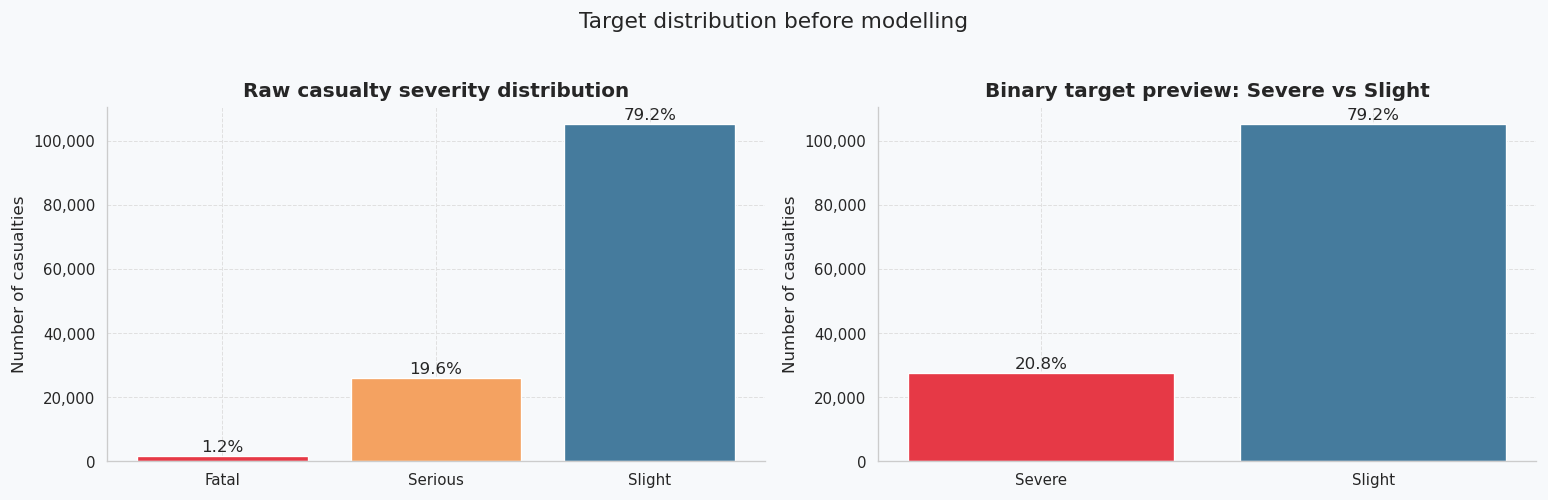

In [14]:
# Inspect the original three-class casualty severity distribution.
# STATS19 codes casualty severity as 1 = Fatal, 2 = Serious, and 3 = Slight.
label_map = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

# Raw 3-class severity
raw_severity = casualties["casualty_severity"].map(label_map)

raw_counts = raw_severity.value_counts().reindex(["Fatal", "Serious", "Slight"])
raw_pcts = (raw_counts / raw_counts.sum() * 100).round(2)

raw_summary = pd.DataFrame({
    "count": raw_counts,
    "percent": raw_pcts
})

# Create the binary modelling target.
# Fatal and serious casualties are grouped as Severe; slight casualties remain the negative class.
binary_severity = casualties["casualty_severity"].map({
    1: "Severe",
    2: "Severe",
    3: "Slight"
})

binary_counts = binary_severity.value_counts().reindex(["Severe", "Slight"])
binary_pcts = (binary_counts / binary_counts.sum() * 100).round(2)

binary_summary = pd.DataFrame({
    "count": binary_counts,
    "percent": binary_pcts
})
binary_summary = binary_summary.reset_index(drop=True)
binary_summary.index = ["Severe", "Slight"]

print("Raw casualty severity distribution:")
display(raw_summary)

print("Binary target distribution:")
display(binary_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw severity plot
bars = axes[0].bar(
    raw_counts.index,
    raw_counts.values,
    color=[FATAL_COL, SERIOUS_COL, SLIGHT_COL],
    edgecolor="white",
    linewidth=0.8
)
#adds percentage labels above each bar
for bar, pct in zip(bars, raw_pcts.values): 
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

axes[0].set_title("Raw casualty severity distribution")
axes[0].set_ylabel("Number of casualties")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Binary severity plot
bars = axes[1].bar(
    binary_counts.index,
    binary_counts.values,
    color=[SEVERE_COL, SLIGHT_COL],
    edgecolor="white",
    linewidth=0.8
)

for bar, pct in zip(bars, binary_pcts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

axes[1].set_title("Binary target preview: Severe vs Slight")
axes[1].set_ylabel("Number of casualties")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Target distribution before modelling", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

The target distribution is imbalanced. Slight casualties account for 79.2% of records, while severe casualties account for 20.8%. This imbalance means that raw accuracy alone would be misleading: a model could achieve high accuracy by mostly predicting the majority class.
Combining fatal and serious casualties is useful for modelling because fatal casualties alone represent only 1.22% of the data. 

### 3.7 Raw distributions of key numeric variables

Before cleaning, the distributions of four key numeric variables are plotted to identify any implausible values beyond the coded missingness already catalogued. Negative values in the three age columns are the sentinel code *-1* and confirm the coded-missing counts from Section 3.4. Speed limit and vehicle count are checked for impossible zero or negative values.

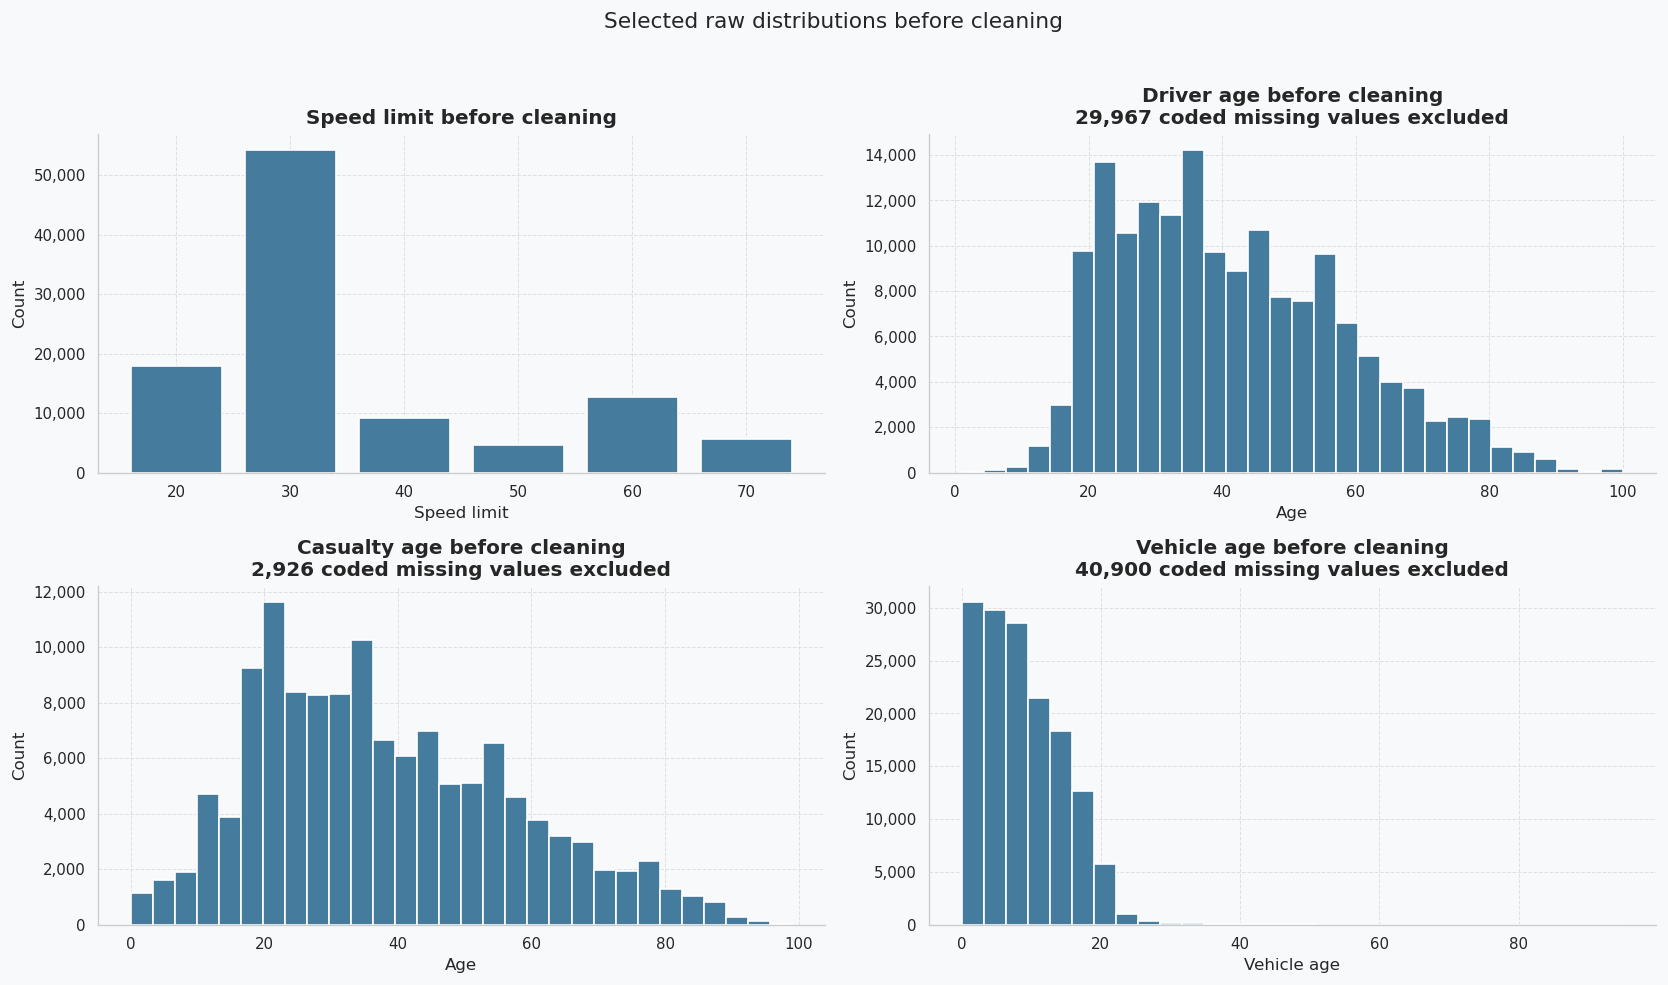

In [15]:
# Plot selected raw distributions before cleaning.
# Coded negative values are excluded from the age histograms only for visualisation.

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

# Speed limits are inspected as recorded in the collision table.

speed_counts = collisions["speed_limit"].value_counts().sort_index()

axes[0].bar(
    speed_counts.index.astype(str),
    speed_counts.values,
    color=SLIGHT_COL,
    edgecolor="white"
)
axes[0].set_title("Speed limit before cleaning")
axes[0].set_xlabel("Speed limit")
axes[0].set_ylabel("Count")

# Driver age
driver_age = vehicles["age_of_driver"]
valid_driver_age = driver_age[(driver_age >= 0) & (driver_age <= 110)]
invalid_driver_age = (driver_age < 0).sum()

axes[1].hist(
    valid_driver_age,
    bins=30,
    color=SLIGHT_COL,
    edgecolor="white"
)
axes[1].set_title(f"Driver age before cleaning\n{invalid_driver_age:,} coded missing values excluded")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

# Casualty age
casualty_age = casualties["age_of_casualty"]
valid_casualty_age = casualty_age[(casualty_age >= 0) & (casualty_age <= 110)]
invalid_casualty_age = (casualty_age < 0).sum()

axes[2].hist(
    valid_casualty_age,
    bins=30,
    color=SLIGHT_COL,
    edgecolor="white"
)
axes[2].set_title(f"Casualty age before cleaning\n{invalid_casualty_age:,} coded missing values excluded")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")

# Vehicle age
vehicle_age = vehicles["age_of_vehicle"]
valid_vehicle_age = vehicle_age[(vehicle_age >= 0) & (vehicle_age <= 100)]
invalid_vehicle_age = (vehicle_age < 0).sum()

axes[3].hist(
    valid_vehicle_age,
    bins=30,
    color=SLIGHT_COL,
    edgecolor="white"
)
axes[3].set_title(f"Vehicle age before cleaning\n{invalid_vehicle_age:,} coded missing values excluded")
axes[3].set_xlabel("Vehicle age")
axes[3].set_ylabel("Count")

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Selected raw distributions before cleaning", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Observation:**

- **Speed limit** takes only the standard UK values (20, 30, 40, 50, 60, 70 mph), with 30 mph being by far the most common (over 50,000 collisions). No impossible values are present.
- **Driver age** follows a right-skewed distribution peaking around ages 25–35, with along tail extending to the 80s. The 29,967 negative sentinel values (-1) confirmed  in Section 3.4 are excluded from the plot but will be replaced with *NaN* in Section 4.
- **Casualty age** is similarly right-skewed, with a peak in the 15–25 range consistent with higher road exposure among younger people. 2,926 negative values are excluded.
- **Vehicle age** is strongly right-skewed: most vehicles are less than 10 years old. The 40,900 negative sentinels represent the largest single category of coded missingness in the vehicles table and will be replaced with *NaN* in Section 4.

### 3.8 Implausible value checks

As a final step in raw inspection, impossible values are checked programmatically. A *speed_limit* of 0 or a *number_of_vehicles* of 0 would indicate a data error because every STATS19 record by definition involves at least one vehicle on a road with some posted speed limit.

In [16]:
# Check selected invalid, coded-missing, or implausible values.
# Negative age and vehicle-age values are expected to represent coded missing values in STATS19.

print("Impossible or implausible value checks:")

print(f"age_of_driver < 0: {(vehicles['age_of_driver'] < 0).sum():,}")
print(f"age_of_vehicle < 0: {(vehicles['age_of_vehicle'] < 0).sum():,}")
print(f"age_of_casualty < 0: {(casualties['age_of_casualty'] < 0).sum():,}")
print(f"speed_limit == 0: {(collisions['speed_limit'] == 0).sum():,}")
print(f"speed_limit < 0: {(collisions['speed_limit'] < 0).sum():,}")
print(f"number_of_vehicles == 0: {(collisions['number_of_vehicles'] == 0).sum():,}")

Impossible or implausible value checks:
age_of_driver < 0: 29,967
age_of_vehicle < 0: 40,900
age_of_casualty < 0: 2,926
speed_limit == 0: 0
speed_limit < 0: 0
number_of_vehicles == 0: 0


The age-related fields contain substantial coded negative values, especially *age_of_vehicle* and *age_of_driver*. These will be treated as missing values during cleaning rather than interpreted as real numeric values. No zero or negative speed limits were found, and every collision record contains at least one vehicle, so no cleaning is required for these checks.

#### Initial EDA Summary

This initial raw-data inspection identified coded missing values across 20 columns, two fully uninformative distance-banding columns, and coded negative missing values in three age-related fields. These issues are addressed in the cleaning and preprocessing stages before model training. The target inspection also shows a clear class imbalance, with severe casualties representing 20.8% of records and slight casualties representing 79.2%, motivating the use of imbalance-aware evaluation metrics later in the notebook.

## SECTION 4: Cleaning, Target Creation, Leakage Removal, and Merging

This section prepares the raw STATS19 tables for modelling. Clean working copies are created first so that the original raw data remain unchanged. Verified coded-missing values are then converted to *NaN*, uninformative variables are removed, and the binary modelling target is created from ***casualty_severity***.

The final modelling unit is **one row per casualty**. Fatal and serious casualties are coded as *target_severe = 1*, while slight casualties are coded as *target_severe = 0*. Before merging the tables, severity-related variables are removed from the predictor tables to reduce the risk of target leakage.

The collision, vehicle, and casualty tables are then merged using the validated keys checked earlier. Additional vehicle-context features are aggregated at collision level and joined back to each casualty record.


### 4.1 Working copies

In [17]:
# Create working copies so that the raw imported tables remain unchanged.
# All cleaning and feature preparation steps are applied to these copies.
collisions_model = collisions.copy()
vehicles_model = vehicles.copy()
casualties_model = casualties.copy()

print("Working copies created.")
print(f"collisions_model: {collisions_model.shape}")
print(f"vehicles_model: {vehicles_model.shape}")
print(f"casualties_model: {casualties_model.shape}")

Working copies created.
collisions_model: (104258, 44)
vehicles_model: (189815, 32)
casualties_model: (132977, 23)


### 4.2 Apply verified coded-missing rules

The coded-missing values identified in Section 3 are now converted to *NaN*. This is done before merging so that missing values from the collision, vehicle, and casualty tables are treated consistently in the final modelling dataset. The replacement is based on the official guide rather than a global rule, because the same numeric code can have different meanings in different STATS19 variables.

In [18]:
# Only rules with status == "MISSING" are applied here.
# VALID codes are retained as genuine categories.
# DROP columns are handled separately in Section 4.3
missing_rules = verified_code_rules_df[
    verified_code_rules_df["status"] == "MISSING"
]

# Map table name strings to the working-copy DataFrames
df_map = {
    "collisions": collisions_model,
    "vehicles": vehicles_model,
    "casualties": casualties_model
}

for _, row in missing_rules.iterrows():
    col = row["column"]
    code = row["code"]

    for df in df_map.values():
        # Only apply replacement if the column exists in this table
        if col in df.columns:
            df[col] = df[col].replace(code, np.nan)

print("Verified coded-missing values replaced with NaN.")

# Verification: check whether any verified missing codes remain
remaining_rows = []

for _, row in missing_rules.iterrows():
    col = row["column"]
    code = row["code"]

    for table_name, df in df_map.items():
        if col in df.columns:
            n_remaining = (df[col] == code).sum()

            if n_remaining > 0:
                remaining_rows.append({
                    "table": table_name,
                    "column": col,
                    "code": code,
                    "remaining_count": n_remaining
                })

remaining_missing_codes = pd.DataFrame(remaining_rows)

if remaining_missing_codes.empty:
    print("Verification passed: no verified missing codes remain.")
else:
    display(remaining_missing_codes)

Verified coded-missing values replaced with NaN.
Verification passed: no verified missing codes remain.


### 4.3 Drop uninformative columns

Two columns are dropped entirely because they contain no usable information in the 2023 STATS19 release (confirmed in Section 3.5): ***driver_distance_banding*** and ***casualty_distance_banding***. Both consist entirely of the sentinel value -1.

In [19]:
# Drop variables identified as uninformative in Section 3.
## Using the rules table here keeps the drop list in one place and avoids
# hard-coding column names in two locations.
drop_cols = verified_code_rules_df.loc[
    verified_code_rules_df["status"] == "DROP",
    "column"
].unique()

for col in drop_cols:
    for df in [collisions_model, vehicles_model, casualties_model]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

print("Dropped uninformative columns:", list(drop_cols))

Dropped uninformative columns: ['driver_distance_banding', 'casualty_distance_banding']


### 4.4 Create binary target variable

The modelling target is derived from ***casualty_severity***:

- **Fatal** and **Serious** -> *target_severe = 1*
- **Slight** -> *target_severe = 0*

The ***target_label*** string column is created for plotting purposes only and will not be included in the feature matrix. The source column ***casualty_severity*** is retained here temporarily and removed in the leakage step (Section 4.5).


In [20]:
# Safety check: confirm the source column exists before creating the target.

assert "casualty_severity" in casualties_model.columns, "casualty_severity is missing before target creation."

# Map the 3-class severity to a binary target.
# Fatal (1) and Serious (2) → Severe (1); Slight (3) → 0.
casualties_model["target_severe"] = casualties_model["casualty_severity"].map({
    1: 1,  # Fatal
    2: 1,  # Serious
    3: 0   # Slight
})

# String label retained for EDA plots in Section 5.
# This column is excluded from the feature matrix before modelling.
casualties_model["target_label"] = casualties_model["target_severe"].map({
    1: "Severe",
    0: "Slight"
})

# Confirm no NaN values in the target — every casualty must have a severity code.
n_missing_target = casualties_model["target_severe"].isna().sum()
assert n_missing_target == 0, (
    f"{n_missing_target} missing values found in target_severe. "
    "Check that casualty_severity contains only codes 1, 2, 3."
)

print("Binary target created successfully.")
print(f"\nTarget distribution (counts):")
print(casualties_model["target_label"].value_counts())
print(f"\nTarget distribution (%):")
print(
    (casualties_model["target_label"].value_counts(normalize=True) * 100)
    .round(2)
    .to_string()
)
print(f"\nMissing target values: {n_missing_target}")

Binary target created successfully.

Target distribution (counts):
target_label
Slight    105323
Severe     27654
Name: count, dtype: int64

Target distribution (%):
target_label
Slight    79.2
Severe    20.8

Missing target values: 0


### 4.5 Remove severity-related leakage variables

Before merging and modelling, variables that directly encode casualty or collision severity are removed from the feature tables. Keeping these variables would create target leakage because the model would have access to information that is either the target itself or a direct derivative of the target.

In [21]:
# These columns either are the target (casualty_severity), are directly computed from the target (enhanced/adjusted severity),
# or roll up casualty-level severity to collision level.All would give the model access to the outcome during training,
# invalidating any performance estimates.

casualty_leakage_cols = [
    "casualty_severity",  # raw source of the target
    "enhanced_casualty_severity",# DfT model score from outcome
    "casualty_injury_based",     # injury-based severity flag
    "casualty_adjusted_severity_serious",  # adjusted probability score
    "casualty_adjusted_severity_slight",  # adjusted probability score
]

collision_leakage_cols = [
    "collision_severity",     # collision-level roll-up of casualty severity
    "enhanced_severity_collision",# DfT model score at collision level
    "collision_injury_based",    # injury-based collision severity flag
    "collision_adjusted_severity_serious",  # adjusted collision probability score
    "collision_adjusted_severity_slight",   # adjusted collision probability score
]

casualties_model.drop(columns=casualty_leakage_cols, errors="ignore", inplace=True)
collisions_model.drop(columns=collision_leakage_cols, errors="ignore", inplace=True)

print("Leakage columns removed.")
print(f"Casualties table : {len(casualty_leakage_cols)} columns dropped.")
print(f"Collisions table : {len(collision_leakage_cols)} columns dropped.")

# Record column counts after leakage removal, before feature selection.
# These are used in the selection summary table below.
collision_cols_before_selection = collisions_model.shape[1]
vehicle_cols_before_selection = vehicles_model.shape[1]
casualty_cols_before_selection = casualties_model.shape[1]

print(f"\nColumn counts after leakage removal (before feature selection):")
print(f"Collisions_model : {collision_cols_before_selection}")
print(f"Vehicles_model : {vehicle_cols_before_selection}")
print(f"Casualties_model : {casualty_cols_before_selection}")

Leakage columns removed.
Casualties table : 5 columns dropped.
Collisions table : 5 columns dropped.

Column counts after leakage removal (before feature selection):
Collisions_model : 39
Vehicles_model : 31
Casualties_model : 19


### 4.6 Feature selection

After leakage removal, each table still contains columns that are not suitable for modelling:

- **Administrative identifiers** (*collision_ref_no*, *police_force*, *lsoa_of_accident_location*, etc.): unique or near-unique values that the model cannot generalise from.
- **Historic/superseded fields** (*junction_detail_historic*, *vehicle_manoeuvre_historic*, etc.): replaced by updated versions in more recent
  STATS19 releases.
- **High-cardinality reference fields** (*generic_make_model*, *lsoa_of_driver*): too many categories for meaningful one-hot encoding without strong prior feature importance evidence.
- **Redundant features**: where a banded and a continuous version of the same variable exist (e.g. *age_of_driver* and *age_band_of_driver*), only the
  continuous version is retained.

The explicit keep-lists below are the audit trail for every retention decision. Any column not in a keep-list is dropped by the final *.copy()* call.

#### 4.6a Collision feature selection.

In [22]:
# Select collision-level predictors to keep in the modelling dataset.
# High-cardinality identifiers, geographic codes, historical duplicate fields, and severity-related leakage variables are excluded.
collision_keep_cols = [
    # Join/group key
    "collision_index",

    # Temporal fields for feature engineering
    "date",
    "time",
    "day_of_week",

    # Road characteristics
    "road_type",
    "speed_limit",
    "first_road_class",
    "junction_detail",
    "junction_control",
    "second_road_class",
    "pedestrian_crossing",
    "trunk_road_flag",
    "urban_or_rural_area",

    # Environmental/site conditions
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",

    # Collision structure
    "number_of_vehicles",
]

collision_keep_cols = [c for c in collision_keep_cols if c in collisions_model.columns]
collisions_model = collisions_model[collision_keep_cols].copy()

print(f"Collision columns kept: {collisions_model.shape[1]} / {collision_cols_before_selection}")
print(collisions_model.columns.tolist())

Collision columns kept: 19 / 39
['collision_index', 'date', 'time', 'day_of_week', 'road_type', 'speed_limit', 'first_road_class', 'junction_detail', 'junction_control', 'second_road_class', 'pedestrian_crossing', 'trunk_road_flag', 'urban_or_rural_area', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'number_of_vehicles']


#### 4.6b Vehicle feature selection
Vehicle-level variables are selected to describe the casualty's associated vehicle and driver. The selected predictors include vehicle type, manoeuvre, impact characteristics, driver demographics, vehicle age, engine capacity, and propulsion type. Historical duplicate fields and high-cardinality vehicle model names are excluded to simplify the modelling task.

In [23]:
# Select own-vehicle predictors for each casualty.
# These describe the vehicle linked to the casualty record through
# collision_index and vehicle_reference.
vehicle_keep_cols = [
    # Merge keys
    "collision_index",
    "vehicle_reference",

    # Vehicle and driver predictors
    "vehicle_type",
    "towing_and_articulation",
    "vehicle_manoeuvre",
    "vehicle_direction_from",
    "vehicle_direction_to",
    "vehicle_location_restricted_lane",
    "junction_location",
    "skidding_and_overturning",
    "hit_object_in_carriageway",
    "vehicle_leaving_carriageway",
    "hit_object_off_carriageway",
    "first_point_of_impact",
    "vehicle_left_hand_drive",
    "journey_purpose_of_driver",
    "sex_of_driver",
    "age_of_driver",
    "engine_capacity_cc",
    "propulsion_code",
    "age_of_vehicle",
    "escooter_flag",
]

vehicle_keep_cols = [c for c in vehicle_keep_cols if c in vehicles_model.columns]
vehicles_model = vehicles_model[vehicle_keep_cols].copy()

print(f"Vehicle columns kept: {vehicles_model.shape[1]} / {vehicle_cols_before_selection}")
print(vehicles_model.columns.tolist())

Vehicle columns kept: 22 / 31
['collision_index', 'vehicle_reference', 'vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway', 'vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact', 'vehicle_left_hand_drive', 'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver', 'engine_capacity_cc', 'propulsion_code', 'age_of_vehicle', 'escooter_flag']


#### 4.6c Casualty feature selection.
The casualty table defines the final unit of analysis, with one row per casualty. The selected casualty-level predictors describe the casualty's role, demographic characteristics, pedestrian information, passenger status, and road-user type. The target columns are retained temporarily for EDA and modelling setup but will be excluded from the feature matrix before training.

In [24]:
# Select casualty-level predictors and target columns.
# age_band_of_casualty is excluded because the continuous age_of_casualty field is retained.
casualty_keep_cols = [
    # Keys
    "collision_index",
    "vehicle_reference",
    "casualty_reference",

    # Target
    "target_severe",
    "target_label",

    # Casualty-level predictors
    "casualty_class",                       # driver / passenger / pedestrian
    "sex_of_casualty",
    "age_of_casualty",
    "pedestrian_location",                  # where on road the pedestrian was
    "pedestrian_movement",                  # what the pedestrian was doing
    "car_passenger",                        # whether casualty was a car passenger
    "bus_or_coach_passenger",
    "pedestrian_road_maintenance_worker",   # special pedestrian status
    "casualty_type",                        # detailed casualty type code
]

casualty_keep_cols = [c for c in casualty_keep_cols if c in casualties_model.columns]
casualties_model = casualties_model[casualty_keep_cols].copy()

print(f"Casualty columns kept: {casualties_model.shape[1]} / {casualty_cols_before_selection}")
print(casualties_model.columns.tolist())

Casualty columns kept: 14 / 19
['collision_index', 'vehicle_reference', 'casualty_reference', 'target_severe', 'target_label', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type']


In [25]:
# Summarise the reduction in columns after feature selection.
# This makes the feature-selection step transparent and auditable.
selection_summary = pd.DataFrame({
    "Table": ["Collisions", "Vehicles", "Casualties"],
    "Columns before selection": [
        collision_cols_before_selection,
        vehicle_cols_before_selection,
        casualty_cols_before_selection
    ],
    "Columns kept": [
        collisions_model.shape[1],
        vehicles_model.shape[1],
        casualties_model.shape[1]
    ]
})

selection_summary["Dropped"] = (
    selection_summary["Columns before selection"] - selection_summary["Columns kept"]
)

display(selection_summary)

,Table,Columns before selection,Columns kept,Dropped
0,Collisions,39,19,20
1,Vehicles,31,22,9
2,Casualties,19,14,5


Feature selection reduced the three tables from a combined 93 columns to 55, keeping only variables that are interpretable, road-safety relevant, and free from administrative or redundant information. The explicit keep-lists above form the complete audit trail. 

### 4.7 Temporal feature engineering

The raw *date* and *time* fields are converted into simpler temporal predictors. The model uses hour, month, weekend status, night-time status, rush-hour status, and weekend-night status. These engineered features are more suitable for modelling than raw date strings and are easier to interpret in later analysis.

In [26]:
# All features are derived from collision-level fields (date, time,
# day_of_week) and carry no severity information.
# we first Check that the raw temporal columns needed for feature engineering are present.

required_time_cols = ["date", "time", "day_of_week"]

missing_time_cols = [
    col for col in required_time_cols
    if col not in collisions_model.columns
]

assert not missing_time_cols, (
    f"Missing temporal columns before feature engineering: {missing_time_cols}. "
    "Rerun Section 4 from 4.1."
)

# Parse time and date fields. Errors are coerced to NaT so parsing failures can be checked.

collisions_model["time_parsed"] = pd.to_datetime(
    collisions_model["time"],
    format="%H:%M",
    errors="coerce"
)

collisions_model["date_parsed"] = pd.to_datetime(
    collisions_model["date"],
    dayfirst=True, #UK dates are usually day/month/year.
    errors="coerce"
)

# Extract simple temporal features for modelling.

collisions_model["hour"] = collisions_model["time_parsed"].dt.hour
collisions_model["month"] = collisions_model["date_parsed"].dt.month

# DfT day_of_week coding: 1 = Sunday, 7 = Saturday
collisions_model["is_weekend"] = collisions_model["day_of_week"].isin([1, 7]).astype(int)

# Create interpretable time-of-day indicators.
collisions_model["is_night"] = collisions_model["hour"].apply(
    lambda x: 1 if pd.notna(x) and (x >= 22 or x <= 5) else 0
)

collisions_model["is_rush_hour"] = collisions_model["hour"].apply(
    lambda x: 1 if pd.notna(x) and ((7 <= x <= 9) or (16 <= x <= 18)) else 0
)

collisions_model["is_weekend_night"] = (
    (collisions_model["is_weekend"] == 1) &
    (collisions_model["is_night"] == 1)
).astype(int)

# Drop raw date/time fields after extracting model-ready temporal features.
collisions_model.drop(
    columns=["time", "date", "time_parsed", "date_parsed"],
    errors="ignore",
    inplace=True
)

print("Temporal features engineered.")
print("Missing hour values:", collisions_model["hour"].isna().sum())
print("Missing month values:", collisions_model["month"].isna().sum())

Temporal features engineered.
Missing hour values: 0
Missing month values: 0


All six temporal features were created without any missing values, confirming that all time and date strings in the 2023 STATS19 data parse correctly. The binary indicator features (*is_weekend*, *is_night*, *is_rush_hour*, *is_weekend_night*) will be passed through the preprocessing pipeline as numeric features and scaled along with other continuous variables in Section 6.

### 4.8 Vehicle-context aggregation

The modelling unit of analysis is one row per **casualty**, but each collision typically involves multiple vehicles. A casualty's own vehicle features (carried through the merge in Section 4.9) describe only the vehicle they were associated with. The collision-context aggregates created here summarise **all vehicles in the same collision**, providing each casualty row with broader contextual information about the crash.

Seventeen context features are built by grouping the vehicles table by *collision_index* and computing either a ***max*** (any-vehicle indicator) or ***mean`/`min*** (numeric aggregate)

In [27]:
# Create collision-level context features from all vehicles involved in each collision.
# These features summarise the wider collision context for each casualty-level row.
# No casualty severity information is used in this aggregation.

# Works on a copy of vehicles_model to avoid modifying the table used for the own-vehicle merge in Section 4.9.
# All intermediate indicator columns (_motorcycle, _car, etc.) are prefixed with underscore to distinguish them from the
# final aggregated features (ctx_*).

vm = vehicles_model.copy()

# Vehicle type indicators
# According to Dft Data Guide: 1=pedal cycle, 2-5/23/97=motorcycles, 9=car, 10-11=bus/minibus, 19=van, 20-21/98=HGV
vm["_motorcycle"] = vm["vehicle_type"].isin([2, 3, 4, 5, 23, 97]).astype("int8")
vm["_car"] = vm["vehicle_type"].eq(9).astype("int8")
vm["_van"] = vm["vehicle_type"].eq(19).astype("int8")
vm["_hgv"] = vm["vehicle_type"].isin([20, 21, 98]).astype("int8")
vm["_bus"] = vm["vehicle_type"].isin([10, 11]).astype("int8")
vm["_cycle"] = vm["vehicle_type"].eq(1).astype("int8")

# e-scooter_flag is present in 2023 data but guard against older releases
if "escooter_flag" in vm.columns:
    vm["_escooter"] = vm["escooter_flag"].eq(1).astype("int8")
else:
    vm["_escooter"] = 0

# # fillna(False) ensures NaN ages (missing driver age sentinel) do not incorrectly classify as young or elderly drivers.
vm["_young_driver"] = vm["age_of_driver"].lt(25).fillna(False).astype("int8")
vm["_elderly_driver"] = vm["age_of_driver"].ge(70).fillna(False).astype("int8")
vm["_male_driver"] = vm["sex_of_driver"].eq(1).fillna(False).astype("int8")

# Collision dynamics indicators
# gt(0) captures any non-zero skidding/overturning code, i.e. any skidding event.
vm["_skidding"] = vm["skidding_and_overturning"].gt(0).fillna(False).astype("int8")
vm["_left_carriageway"] = vm["vehicle_leaving_carriageway"].gt(0).fillna(False).astype("int8")
vm["_front_impact"] = vm["first_point_of_impact"].eq(1).fillna(False).astype("int8")


# Aggregate per collision
# max() gives "did any vehicle in this collision have this property?"
# mean/min() for continuous age give collision-level numeric summaries.
vehicle_context_agg = (
    vm.groupby("collision_index", as_index=False)
    .agg(
        ctx_any_motorcycle=("_motorcycle", "max"),
        ctx_any_car=("_car", "max"),
        ctx_any_van=("_van", "max"),
        ctx_any_hgv=("_hgv", "max"),
        ctx_any_bus=("_bus", "max"),
        ctx_any_cycle=("_cycle", "max"),
        ctx_any_escooter=("_escooter", "max"),

        ctx_mean_driver_age=("age_of_driver", "mean"),
        ctx_min_driver_age=("age_of_driver", "min"),
        ctx_any_young_driver=("_young_driver", "max"),
        ctx_any_elderly_driver=("_elderly_driver", "max"),
        ctx_any_male_driver=("_male_driver", "max"),

        ctx_mean_vehicle_age=("age_of_vehicle", "mean"),

        ctx_any_skidding=("_skidding", "max"),
        ctx_any_left_carriageway=("_left_carriageway", "max"),
        ctx_any_front_impact=("_front_impact", "max"),
    )
)

# Confirm one row per collision after aggregation
assert vehicle_context_agg["collision_index"].is_unique, (
    "vehicle_context_agg has duplicate collision_index values after groupby."
)

print(f"Vehicle context aggregation shape: {vehicle_context_agg.shape}")
print(f"Duplicate collision_index: "
      f"{vehicle_context_agg['collision_index'].duplicated().sum()}")

print("\nMissing values in aggregated numeric features:")
for col in ["ctx_mean_driver_age", "ctx_min_driver_age", "ctx_mean_vehicle_age"]:
    n = vehicle_context_agg[col].isna().sum()
    pct = round(n / len(vehicle_context_agg) * 100, 2)
    print(f"  {col}: {n:,} ({pct}%)")
    
display(vehicle_context_agg.head())

Vehicle context aggregation shape: (104258, 17)
Duplicate collision_index: 0

Missing values in aggregated numeric features:
  ctx_mean_driver_age: 5,687 (5.45%)
  ctx_min_driver_age: 5,687 (5.45%)
  ctx_mean_vehicle_age: 11,531 (11.06%)


,collision_index,ctx_any_motorcycle,ctx_any_car,ctx_any_van,ctx_any_hgv,ctx_any_bus,ctx_any_cycle,ctx_any_escooter,ctx_mean_driver_age,ctx_min_driver_age,ctx_any_young_driver,ctx_any_elderly_driver,ctx_any_male_driver,ctx_mean_vehicle_age,ctx_any_skidding,ctx_any_left_carriageway,ctx_any_front_impact
0,2023010419171,0,0,0,0,1,0,0,61.000000,61.0,0,0,1,13.000000,0,0,1
1,2023010419183,0,1,0,0,1,0,0,40.333333,25.0,0,0,1,4.666667,0,0,1
2,2023010419189,0,1,0,0,0,0,0,40.000000,30.0,0,0,1,11.500000,0,0,1
3,2023010419191,0,1,0,0,0,1,0,34.000000,34.0,0,0,1,NaN,1,0,1
4,2023010419192,1,1,0,0,0,0,0,28.500000,24.0,1,0,1,5.000000,0,0,1


The aggregation produced 104,258 rows; one per unique collision,  matching the collisions table exactly, confirming no collisions were lost or duplicated.

Residual missing values in *ctx_mean_driver_age*, *ctx_min_driver_age*, and *ctx_mean_vehicle_age* represent collisions where **all** vehicles in the crash hada missing age value (i.e. all drivers had age coded *-1*). These NaN values are expected and will be imputed by the median imputer inside the preprocessing pipeline in Section 6; they are not an error.

### 4.9 Three-stage merge

The final modelling table is assembled by joining the cleaned tables in three steps. The unit of analysis throughout is **one row per casualty**:

1. **Casualties <-- own vehicle** (*collision_index + vehicle_reference*): attaches the features of the vehicle the casualty was travelling in (or struck by).
2. **+ Collision features** (*collision_index*): attaches road, environmental, and temporal features for the collision.
3. **+ Vehicle-context aggregates** (*collision_index*):attaches the collision-level context features built in Section 4.8.

Each merge uses ***validate="many_to_one"*** so pandas raises an error immediately if the right-hand table is found to have duplicate keys row inflation. The ***indicator*** argument confirms that every casualty matched to exactly one vehicle and one collision record.

In [28]:
# Diagnose unmatched casualty-to-vehicle records before asserting.
merge_check = casualties_model.merge(
    vehicles_model[["collision_index", "vehicle_reference"]].drop_duplicates(),
    on=["collision_index", "vehicle_reference"],
    how="left",
    indicator=True
)

print("Casualty-to-vehicle key merge check:")
print(merge_check["_merge"].value_counts())

unmatched = merge_check[merge_check["_merge"] == "left_only"].copy()

print("\nNumber of unmatched casualty rows:", len(unmatched))

if len(unmatched) > 0:
    display(
        unmatched[
            ["collision_index", "vehicle_reference", "casualty_reference", "target_label"]
        ].head(20)
    )

    print("\nKey dtypes:")
    print("casualties_model collision_index:", casualties_model["collision_index"].dtype)
    print("vehicles_model collision_index:", vehicles_model["collision_index"].dtype)
    print("casualties_model vehicle_reference:", casualties_model["vehicle_reference"].dtype)
    print("vehicles_model vehicle_reference:", vehicles_model["vehicle_reference"].dtype)

    print("\nMissing key values:")
    print("casualties_model collision_index missing:", casualties_model["collision_index"].isna().sum())
    print("casualties_model vehicle_reference missing:", casualties_model["vehicle_reference"].isna().sum())
    print("vehicles_model collision_index missing:", vehicles_model["collision_index"].isna().sum())
    print("vehicles_model vehicle_reference missing:", vehicles_model["vehicle_reference"].isna().sum())

Casualty-to-vehicle key merge check:
_merge
both          132977
left_only          0
right_only         0
Name: count, dtype: int64

Number of unmatched casualty rows: 0


In [29]:
# Stage 1: Casualties + own vehicle features
model_df = casualties_model.merge(
    vehicles_model,
    on=["collision_index", "vehicle_reference"],
    how="left",
    validate="many_to_one",   # each casualty maps to at most one vehicle record
    indicator="vehicle_merge"
)

print(f"Stage 1 — casualties + own vehicle: {model_df.shape}")
print(model_df["vehicle_merge"].value_counts().to_string())

assert (model_df["vehicle_merge"] == "both").all(), (
    "Some casualties did not match to a vehicle record. "
    "Check the vehicles_model join keys."
)

# Stage 2: + Collision features
model_df = model_df.merge(
    collisions_model,
    on="collision_index",
    how="left",
    validate="many_to_one",   # each casualty maps to at most one collision record
    indicator="collision_merge"
)

print(f"\nStage 2 — + collision features: {model_df.shape}")
print(model_df["collision_merge"].value_counts().to_string())

assert (model_df["collision_merge"] == "both").all(), (
    "Some rows did not match to a collision record. "
    "Check the collisions_model join keys."
)

# Stage 3: + Vehicle-context aggregates
# Re-assert uniqueness of the aggregation table immediately before merging
# in case any earlier cell modified vehicle_context_agg.
assert vehicle_context_agg["collision_index"].is_unique, (
    "vehicle_context_agg must have one row per collision_index before merging."
)

model_df = model_df.merge(
    vehicle_context_agg,
    on="collision_index",
    how="left",
    validate="many_to_one"
)

print(f"\nStage 3 — + vehicle context: {model_df.shape}")

# Drop the merge indicator columns, no longer needed
model_df.drop(
    columns=["vehicle_merge", "collision_merge"],
    errors="ignore",
    inplace=True
)

# Post-merge missing value audit for context features 
ctx_cols = [c for c in vehicle_context_agg.columns if c != "collision_index"]
ctx_missing = model_df[ctx_cols].isna().sum()
ctx_missing = ctx_missing[ctx_missing > 0]

print("\nMissing values in vehicle-context features after merge:")
if ctx_missing.empty:
    print("  None.")
else:
    display(
        pd.DataFrame({
            "missing_count":   ctx_missing,
            "missing_percent": (ctx_missing / len(model_df) * 100).round(2)
        })
    )

Stage 1 — casualties + own vehicle: (132977, 35)
vehicle_merge
both          132977
left_only          0
right_only         0

Stage 2 — + collision features: (132977, 58)
collision_merge
both          132977
left_only          0
right_only         0

Stage 3 — + vehicle context: (132977, 74)

Missing values in vehicle-context features after merge:


,missing_count,missing_percent
ctx_mean_driver_age,6012,4.52
ctx_min_driver_age,6012,4.52
ctx_mean_vehicle_age,12316,9.26


All three merges completed with zero unmatched rows (*both* in every indicator column), confirming that every casualty has exactly one matching vehicle record and one matching collision record. The row count of 132,977 is preserved throughout; no casualties were lost or duplicated.

The residual missing values in *ctx_mean_driver_age* (4.5%), *ctx_min_driver_age* (4.5%), and *ctx_mean_vehicle_age* (9.3%) are expected: they correspond to collisions where all drivers or vehicles had missing ages in the raw STATS19 data. These will be handled by median imputation inside the preprocessing pipeline in Section 6.

### 4.10 Final modelling dataset audit

In [30]:
# Row count must equal the original casualties table
assert len(model_df) == len(casualties_model), (
    f"Row count mismatch: model_df has {len(model_df):,} rows but "
    f"casualties_model has {len(casualties_model):,}."
)

print(f"Final modelling dataset shape: {model_df.shape}")

print(f"\nRow-count check passed: {len(model_df):,} rows "
      f"(= original casualties table).")

print("\nTarget distribution:")
print(model_df["target_label"].value_counts().to_string())

print("\nTarget distribution (%):")
print(
    (model_df["target_label"].value_counts(normalize=True) * 100)
    .round(2)
    .to_string()
)
print(f"\nMissing target values: {model_df['target_severe'].isna().sum()}")

print(f"\nUnique collisions: {model_df['collision_index'].nunique():,}")
print(f"Total casualties: {len(model_df):,}")
print(
    f"Avg casualties per collision: "
    f"{len(model_df) / model_df['collision_index'].nunique():.2f}"
)
print(f"\nDuplicate rows: {model_df.duplicated().sum()}")

Final modelling dataset shape: (132977, 72)

Row-count check passed: 132,977 rows (= original casualties table).

Target distribution:
target_label
Slight    105323
Severe     27654

Target distribution (%):
target_label
Slight    79.2
Severe    20.8

Missing target values: 0

Unique collisions: 104,258
Total casualties: 132,977
Avg casualties per collision: 1.28

Duplicate rows: 0


### 4.11 Remaining missing values in the modelling dataset

The table below summarises all columns that still contain *NaN* values after cleaning. These represent genuine informational gaps in the STATS19 data; not data loading errors and will be handled by the imputation steps inside the *sklearn* preprocessing pipeline in Section 6 (median imputation for numeric features; constant "Missing" imputation for categorical features).

No rows are dropped at this stage. Dropping rows with missing values would reduce the training dataset and could introduce selection bias if missingness is related to collision severity.

In [31]:
# Summarise all remaining NaN values in the final modelling table.
# Only columns with at least one missing value are shown.
missing_final = model_df.isna().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

missing_final_summary = pd.DataFrame({
    "missing_count":missing_final,
    "missing_percent": (missing_final / len(model_df) * 100).round(2)
})

print(f"Columns with remaining missing values: {len(missing_final_summary)}")
display(missing_final_summary)

Columns with remaining missing values: 26


,missing_count,missing_percent
junction_control,60097,45.19
engine_capacity_cc,30538,22.96
age_of_vehicle,28601,21.51
propulsion_code,28550,21.47
ctx_mean_vehicle_age,12316,9.26
skidding_and_overturning,11515,8.66
vehicle_leaving_carriageway,11422,8.59
trunk_road_flag,10145,7.63
vehicle_manoeuvre,10120,7.61
pedestrian_crossing,8527,6.41


The largest remaining missingness occurs in *junction_control*, followed by engine_capacity_cc, vehicle-age and propulsion-related fields. This pattern is consistent with the earlier coded-missing audit. Since missingness remains after merging, the modelling pipeline must include imputation for both numeric and categorical predictors.

## Section 5: Exploratory Data Analysis on the Cleaned Modelling Dataset (EDA 2)

This section explores the **cleaned, merged modelling dataset** produced in Section 4.
Unlike Section 3 (which inspected raw tables before cleaning), EDA 2 works on the
final casualty-level table and focuses on understanding **patterns in severe injury
rate** across every feature group.

Each subsection asks: *does this variable show meaningful variation in the proportion
of casualties classified as Severe?* Features that show clear variation are more
likely to be useful predictors; the EDA findings directly inform the feature selection
decisions documented in Section 6.

> **Note on the EDA subset:** A 35-column EDA view (*eda_df*) is used for
> visualisation. The full modelling table (*model_df*, 72 columns) is kept unchanged
> and is used exclusively for modelling from Section 6 onwards.

In [32]:
### EDA dataset setup

import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# Use a smaller EDA view instead of all 72 columns.
# The full model_df is kept unchanged for modelling.
eda_cols = [
    "target_severe", "target_label",
    # Casualty-level
    "casualty_class", "sex_of_casualty", "age_of_casualty", "casualty_type",
    # Own vehicle / driver
    "vehicle_type", "age_of_driver", "vehicle_manoeuvre",
    "vehicle_leaving_carriageway", "skidding_and_overturning", "first_point_of_impact",
    # Road and infrastructure
    "speed_limit", "urban_or_rural_area", "road_type",
    "first_road_class", "number_of_vehicles",
    # Environment
    "light_conditions", "weather_conditions", "road_surface_conditions",
    # Time
    "hour", "month", "day_of_week", "is_weekend_night",
    # Collision-context aggregates
    "ctx_any_motorcycle", "ctx_any_cycle", "ctx_any_hgv",
    "ctx_any_skidding", "ctx_any_left_carriageway", "ctx_any_front_impact",
    "ctx_any_young_driver", "ctx_any_elderly_driver",
    "ctx_mean_driver_age", "ctx_min_driver_age", "ctx_mean_vehicle_age",
]

eda_cols = [c for c in eda_cols if c in model_df.columns]
eda_df = model_df[eda_cols].copy()

# Reuse global colours if already defined earlier
SEVERE_COL = globals().get("SEVERE_COL", "#E63946")
SLIGHT_COL = globals().get("SLIGHT_COL", "#457B9D")

# Section-specific colour palette (one colour per thematic group)
CASUALTY_COL = "#6C5CE7"   # purple  — casualty characteristics
ROAD_COL= "#2A9D8F"   # teal— road and infrastructure
ENV_COL= "#43AA8B"   # green— environmental conditions
TIME_COL= "#F4A261"   # amber— temporal features
VEHICLE_COL  = "#8D5A97"   # violet— vehicle / driver features
NEUTRAL_COL= "#7A7A7A"   # grey— neutral / miscellaneous
LIGHT_GRE  = "#D9D9D9"

print(f"Full modelling dataset shape: {model_df.shape}")
print(f"EDA dataset shape: {eda_df.shape}")
print(f"Columns used for EDA: {len(eda_cols)}")
print(eda_cols)

Full modelling dataset shape: (132977, 72)
EDA dataset shape: (132977, 35)
Columns used for EDA: 35
['target_severe', 'target_label', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'casualty_type', 'vehicle_type', 'age_of_driver', 'vehicle_manoeuvre', 'vehicle_leaving_carriageway', 'skidding_and_overturning', 'first_point_of_impact', 'speed_limit', 'urban_or_rural_area', 'road_type', 'first_road_class', 'number_of_vehicles', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'hour', 'month', 'day_of_week', 'is_weekend_night', 'ctx_any_motorcycle', 'ctx_any_cycle', 'ctx_any_hgv', 'ctx_any_skidding', 'ctx_any_left_carriageway', 'ctx_any_front_impact', 'ctx_any_young_driver', 'ctx_any_elderly_driver', 'ctx_mean_driver_age', 'ctx_min_driver_age', 'ctx_mean_vehicle_age']


### 5.1 Helper functions and STATS19 label maps

Reusable helper functions are defined for severe-rate tables, bar charts, lollipop charts, dumbbell plots, and binary flag comparisons. This avoids repeated plotting code and keeps the EDA section consistent. Label maps are also defined so that STATS19 numeric codes can be displayed as readable categories in the figures.

In [33]:
# 5.1a  Reusable analysis helpers
#This function creates a summary table showing the Severe rate for each category of a variable.
def severe_rate_table(df, col, min_count=100, label_map=None,
                      order=None, sort_desc=True):
    tmp = df[[col, "target_severe"]].copy()
    tmp["label"] = tmp[col].map(label_map) if label_map else tmp[col]
    tmp["label"] = tmp["label"].astype("object")
    tmp["label"] = tmp["label"].where(tmp["label"].notna(), "Missing")

    out = (
        tmp.groupby("label", dropna=False)["target_severe"]
        .agg(rate="mean", n="size")
        .reset_index()
    )
    out["rate_pct"] = out["rate"] * 100
    out = out[out["n"] >= min_count].copy()

    if order is not None:
        out["__order"] = pd.Categorical(
            out["label"], categories=order, ordered=True
        )
        out = out.sort_values("__order").drop(columns="__order")
    else:
        out = out.sort_values("rate_pct", ascending=not sort_desc)

    return out.reset_index(drop=True)


def lollipop_rate(ax, tbl, color, title, xlabel="Severe rate (%)"):
    if tbl.empty:
        ax.text(0.5, 0.5, "No groups meet min_count",
                ha="center", va="center")
        ax.axis("off")
        return

    tbl = tbl.sort_values("rate_pct", ascending=True).reset_index(drop=True)
    y   = np.arange(len(tbl))

    ax.hlines(y=y, xmin=0, xmax=tbl["rate_pct"],
              color=color, alpha=0.35, linewidth=2.5)
    ax.scatter(tbl["rate_pct"], y, s=85, color=color,
               edgecolor="white", linewidth=1.2, zorder=3)

    for i, row in tbl.iterrows():
        ax.text(row["rate_pct"] + 0.35, i,
                f"n={row['n']:,}", va="center", fontsize=8)

    ax.set_yticks(y)
    ax.set_yticklabels(tbl["label"])
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight="bold")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
    )
    ax.set_xlim(left=0)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)


def bar_rate(ax, tbl, color, title, xlabel="",
             ylabel="Severe rate (%)", rotate=0):
    if tbl.empty:
        ax.text(0.5, 0.5, "No groups meet min_count",
                ha="center", va="center")
        ax.axis("off")
        return

    bars = ax.bar(tbl["label"].astype(str), tbl["rate_pct"],
                  color=color, edgecolor="white", linewidth=0.8)

    for bar, (_, row) in zip(bars, tbl.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.35,
                f"n={row['n']:,}",
                ha="center", va="bottom", fontsize=8,
                rotation=45 if rotate else 0)

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotate)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
    )
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.grid(axis="x", visible=False)


def flag_compare_table(df, flag_specs):
    rows = []
    for col, label in flag_specs:
        if col not in df.columns:
            continue
        sub = df.loc[df[col].isin([0, 1]), [col, "target_severe"]].copy()
        if sub.empty:
            continue
        g = sub.groupby(col)["target_severe"].agg(rate="mean", n="size")
        if 0 in g.index and 1 in g.index:
            rows.append({
                "label":   label,
                "rate_no": g.loc[0, "rate"] * 100,
                "rate_yes":g.loc[1, "rate"] * 100,
                "n_yes":   int(g.loc[1, "n"]),
                "gap":     (g.loc[1, "rate"] - g.loc[0, "rate"]) * 100
            })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("rate_yes", ascending=False).reset_index(drop=True)
    return out


def dumbbell_flags(ax, tbl, title,
                   yes_color=SEVERE_COL, no_color=SLIGHT_COL):
    """
    Dumbbell chart comparing severe rate when a binary flag is absent
    (left dot) versus present (right dot).
    """
    if tbl.empty:
        ax.text(0.5, 0.5, "No valid binary flags available",
                ha="center", va="center")
        ax.axis("off")
        return

    y = np.arange(len(tbl))

    for i, row in tbl.iterrows():
        ax.plot([row["rate_no"], row["rate_yes"]], [i, i],
                color="#BFBFBF", linewidth=2.2, zorder=1)

    ax.scatter(tbl["rate_no"], y, s=70, color=no_color,
               edgecolor="white", linewidth=1.0,
               label="Absent / No", zorder=3)
    ax.scatter(tbl["rate_yes"], y, s=90, color=yes_color,
               edgecolor="white", linewidth=1.0,
               label="Present / Yes", zorder=4)

    for i, row in tbl.iterrows():
        ax.text(row["rate_yes"] + 0.35, i,
                f"n={row['n_yes']:,}", va="center", fontsize=8)

    ax.set_yticks(y)
    ax.set_yticklabels(tbl["label"])
    ax.set_xlabel("Severe rate (%)")
    ax.set_title(title, fontweight="bold")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
    )
    ax.legend(loc="lower right")
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)


def own_vehicle_group(x):
    """
    Map STATS19 vehicle_type codes to simplified human-readable groups
    for EDA display. Returns 'Missing' for NaN values.
    Codes from DfT STATS19 data guide (2024).
    """
    if pd.isna(x):return "Missing"
    if x == 1:return "Pedal cycle"
    if x in [2,3,4,5,23,97]: return "Motorcycle"
    if x == 9:return "Car"
    if x == 19:return "Van"
    if x in [10, 11]:return "Bus / coach"
    if x in [20, 21, 98]:return "HGV"
    return "Other"


# 5.1b  STATS19 category label maps

CASUALTY_CLASS_LABELS = {1: "Driver / rider", 2: "Passenger",
                         3: "Pedestrian"}
SEX_LABELS= {1: "Male", 2: "Female"}
ROAD_TYPE_LABELS= {1: "Roundabout", 2: "One way street",
                         3: "Dual carriageway", 6: "Single carriageway",
                         7: "Slip road", 9: "Unknown",
                         12: "One way / slip road"}
FIRST_ROAD_CLASS_LABELS = {1: "Motorway", 2: "A(M)", 3: "A road",
                            4: "B road", 5: "C road", 6: "Unclassified"}
URBAN_RURAL_LABELS    = {1: "Urban", 2: "Rural"}
LIGHT_LABELS= {1: "Daylight", 4: "Dark — lights lit",
                         5: "Dark — lights unlit", 6: "Dark — no lighting",
                         7: "Dark — lighting unknown"}
WEATHER_LABELS= {1: "Fine / no high winds", 2: "Raining / no high winds",
                         3: "Snowing / no high winds", 4: "Fine / high winds",
                         5: "Raining / high winds", 6: "Fog or mist",
                         7: "Other", 8: "Snowing / high winds"}
ROAD_SURFACE_LABELS   = {1: "Dry", 2: "Wet or damp", 3: "Snow",
                         4: "Frost or ice", 5: "Flood",
                         6: "Oil or diesel", 7: "Mud"}
DAY_LABELS= {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed",
                         5: "Thu", 6: "Fri", 7: "Sat"}

print("Helper functions and label maps ready.")

Helper functions and label maps ready.


### 5.2 Target distribution

The binary target distribution is confirmed on the cleaned modelling dataset. This plot serves as a final check that the merging and cleaning steps in Section 4 did not alter the class balance, and motivates the imbalance-handling strategy used in modelling.

Binary target distribution:


,count,percent (%)
target_label,,
Severe,27654,20.8
Slight,105323,79.2


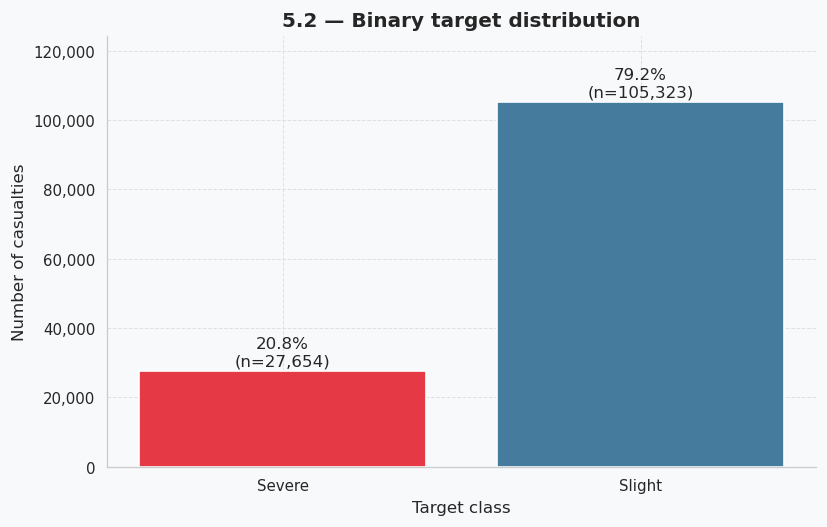

In [34]:
target_counts = (
    eda_df["target_label"]
    .value_counts()
    .reindex(["Severe", "Slight"])
)
target_pct = (target_counts / target_counts.sum() * 100).round(2)

print("Binary target distribution:")
display(
    pd.DataFrame({"count": target_counts, "percent (%)": target_pct})
)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    target_counts.index,
    target_counts.values,
    color=[SEVERE_COL, SLIGHT_COL],
    edgecolor="white",
    linewidth=1
)

for bar, pct, n in zip(bars, target_pct.values, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 700,
        f"{pct:.1f}%\n(n={n:,})",
        ha="center", va="bottom", fontsize=10
    )

ax.set_ylim(0, target_counts.max() * 1.18)
ax.set_title("5.2 — Binary target distribution", fontweight="bold")
ax.set_ylabel("Number of casualties")
ax.set_xlabel("Target class")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.tight_layout()
plt.show()

### 5.3 Casualty characteristics

This subsection examines how severe injury rate varies with **casualty age** and **casualty class** (driver/rider, passenger, or pedestrian).

A temporary age band variable (*casualty_age_band_eda*) is created for visualisation only. It is not added to *model_df*. The continuous *age_of_casualty* is used in modelling. The 2,926 NaN values (1–2 of casualties) excluded from the age band plot correspond to the -1 coded-missing values replaced in Section 4.2.

NaN in casualty_age_band_eda: 2926


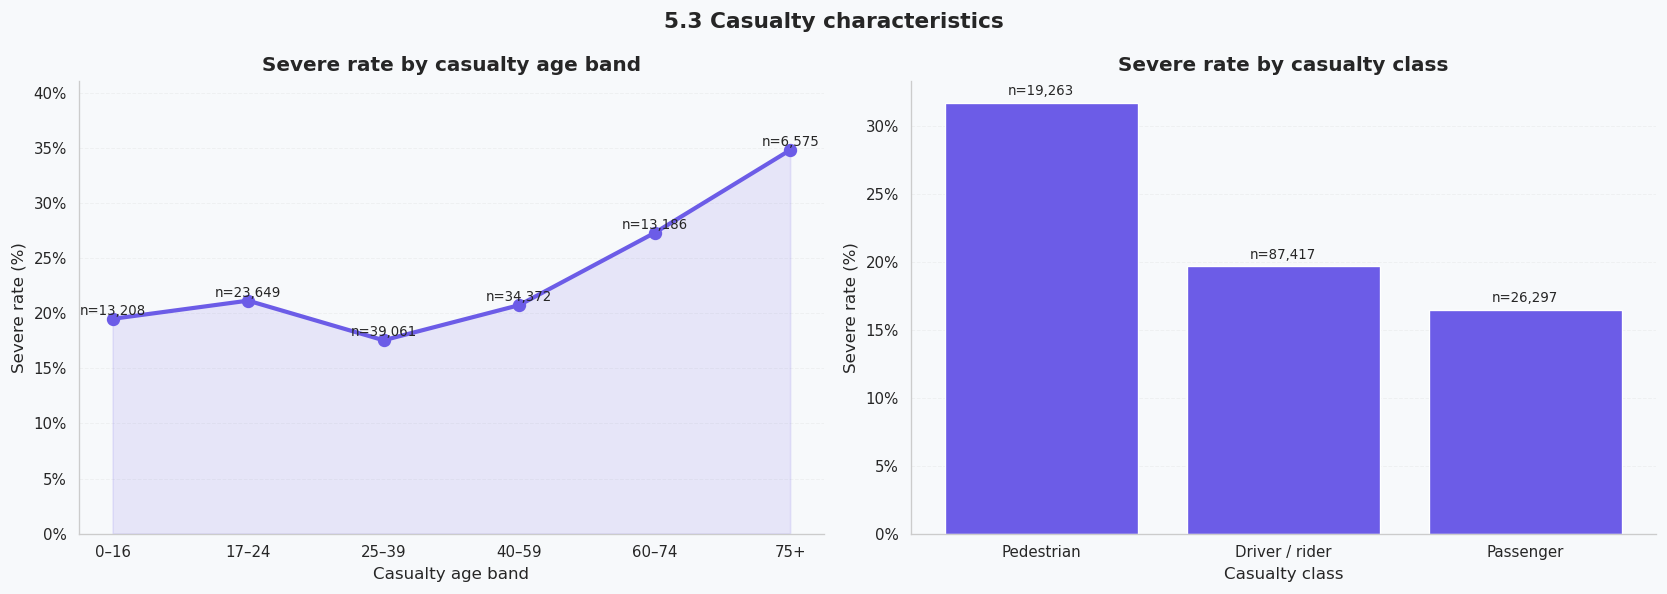

In [35]:
# Temporary age banding for EDA visualisation only.
# model_df retains the continuous age_of_casualty for modelling.

eda_df["casualty_age_band_eda"] = pd.cut(
    eda_df["age_of_casualty"],
    bins=[0, 16, 24, 39, 59, 74, 120],
    labels=["0–16", "17–24", "25–39", "40–59", "60–74", "75+"],
    include_lowest=True
)

print("NaN in casualty_age_band_eda:", eda_df["casualty_age_band_eda"].isna().sum())

# Build severe rate tables
age_band_tbl = severe_rate_table(
    eda_df,
    "casualty_age_band_eda",
    min_count=200,
    order=["0–16", "17–24", "25–39", "40–59", "60–74", "75+"],
    sort_desc=False
)


# Exclude Missing from the ordered age trend line
age_band_tbl = age_band_tbl[age_band_tbl["label"] != "Missing"].copy()

casualty_class_tbl = severe_rate_table(
    eda_df,
    "casualty_class",
    min_count=200,
    label_map=CASUALTY_CLASS_LABELS
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ordered line plot for age band
ax = axes[0]
x = np.arange(len(age_band_tbl))

ax.plot(
    x,
    age_band_tbl["rate_pct"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color=CASUALTY_COL
)

ax.fill_between(
    x,
    age_band_tbl["rate_pct"],
    alpha=0.12,
    color=CASUALTY_COL
)

for i, row in age_band_tbl.iterrows():
    ax.text(
        i,
        row["rate_pct"] + 0.35,
        f"n={row['n']:,}",
        ha="center",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(age_band_tbl["label"])
ax.set_title("Severe rate by casualty age band", fontweight="bold")
ax.set_xlabel("Casualty age band")
ax.set_ylabel("Severe rate (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_ylim(0, age_band_tbl["rate_pct"].max() * 1.18)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

# Right: bar chart for casualty class
bar_rate(
    axes[1],
    casualty_class_tbl,
    color=CASUALTY_COL,
    title="Severe rate by casualty class",
    xlabel="Casualty class",
    rotate=0
)

plt.suptitle("5.3 Casualty characteristics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** Severe injury rate shows a clear U-shaped relationship with age at the upper end. The youngest and oldest casualties have the highest severe rates: 75+ year-olds have the highest rate (approx.35%), reflecting greater physiological vulnerability to trauma. The 25–39 group has the lowest severe rate (approx.19%), likely reflecting a combination of peak physical resilience and predominantly urban, lower- speed collisions. This age gradient is a meaningful signal and ***age_of_casualty*** is retained as a continuous feature in modelling.

***Pedestrians*** have by far the highest severe rate (approx. 31%), more than 10 percentage points above drivers/riders (approx.20%) and passengers (approx.16%). Pedestrians are physically unprotected and frequently struck by faster-moving vehicles, making *casualty_class* one of the most discriminating features in the dataset.

### 5.4 Own driver and vehicle characteristics

This subsection examines severe rate by **driver age band** and three binary risk flags derived from the own-vehicle fields: skidding/overturning, leaving the carriageway, and front impact. The flags are temporary EDA variables created from the cleaned numeric codes and are not added to `model_df`.

Note: *age_of_driver* has 9,335 missing values after the -1 sentinel replacement (15.8% of vehicle records, as catalogued in Section 3.4). The age band plot excludes NaN values, as they are shown in the count printed below.

NaN in driver_age_band_eda: 9335


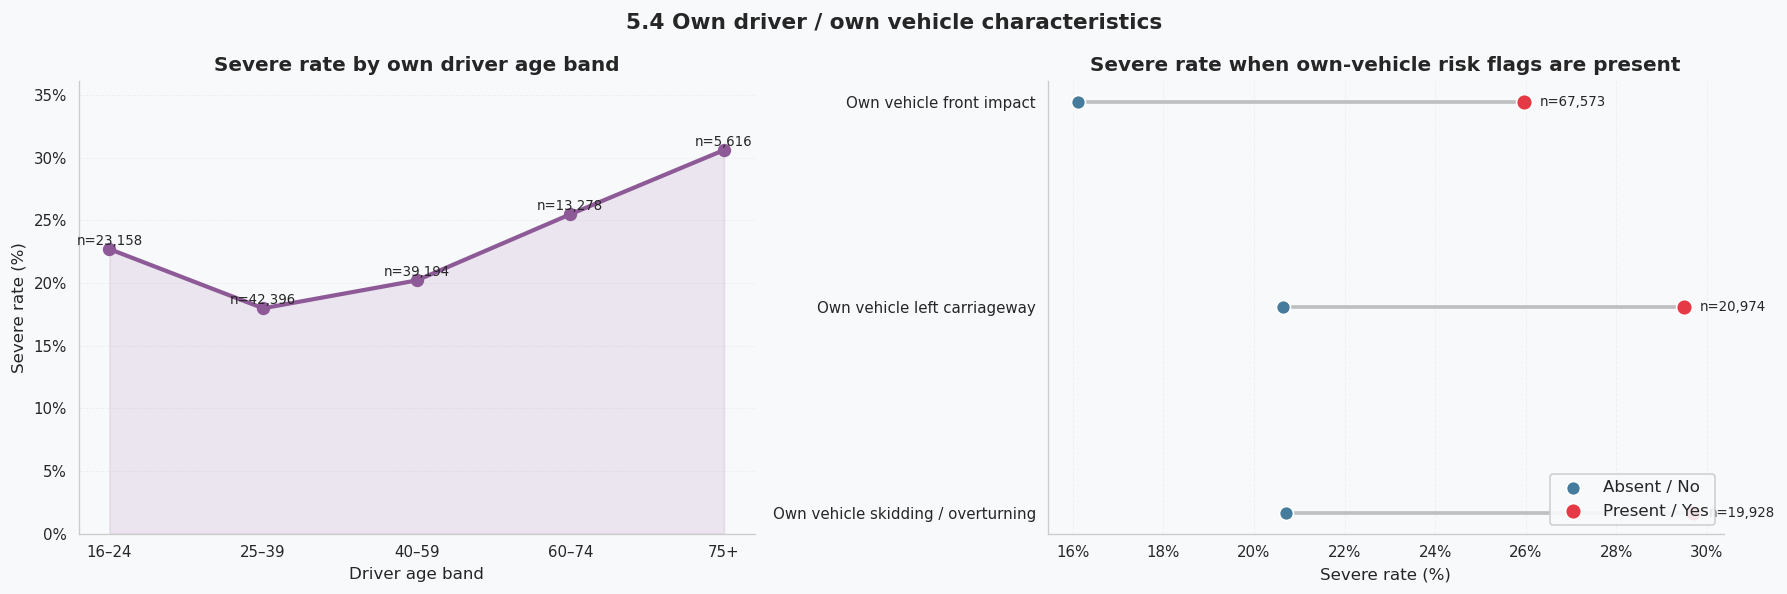

In [36]:
# Temporary banding and binary flags for EDA only.
# NaN values from the -1 age sentinel are excluded from the ordered trend line but their count is reported.
eda_df["driver_age_band_eda"] = pd.cut(
    eda_df["age_of_driver"],
    bins=[16, 24, 39, 59, 74, 120],
    labels=["16–24", "25–39", "40–59", "60–74", "75+"],
    include_lowest=True
)

print("NaN in driver_age_band_eda:", eda_df["driver_age_band_eda"].isna().sum())

driver_age_tbl = severe_rate_table(
    eda_df,
    "driver_age_band_eda",
    min_count=200,
    order=["16–24", "25–39", "40–59", "60–74", "75+"],
    sort_desc=False
)

driver_age_tbl = driver_age_tbl[driver_age_tbl["label"] != "Missing"].copy()

# Create temporary binary flags from own-vehicle fields
eda_df["own_skidding_flag"] = np.where(
    eda_df["skidding_and_overturning"].isna(),
    np.nan,
    (eda_df["skidding_and_overturning"] > 0).astype(int)
)

eda_df["own_left_carriageway_flag"] = np.where(
    eda_df["vehicle_leaving_carriageway"].isna(),
    np.nan,
    (eda_df["vehicle_leaving_carriageway"] > 0).astype(int)
)

eda_df["own_front_impact_flag"] = np.where(
    eda_df["first_point_of_impact"].isna(),
    np.nan,
    (eda_df["first_point_of_impact"] == 1).astype(int)
)

own_flag_specs = [
    ("own_skidding_flag", "Own vehicle skidding / overturning"),
    ("own_left_carriageway_flag", "Own vehicle left carriageway"),
    ("own_front_impact_flag", "Own vehicle front impact"),
]

own_flag_tbl = flag_compare_table(eda_df, own_flag_specs)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: ordered line plot for driver age band
ax = axes[0]
x = np.arange(len(driver_age_tbl))

ax.plot(
    x,
    driver_age_tbl["rate_pct"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color=VEHICLE_COL
)

ax.fill_between(
    x,
    driver_age_tbl["rate_pct"],
    alpha=0.12,
    color=VEHICLE_COL
)

for i, row in driver_age_tbl.iterrows():
    ax.text(
        i,
        row["rate_pct"] + 0.35,
        f"n={row['n']:,}",
        ha="center",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(driver_age_tbl["label"])
ax.set_title("Severe rate by own driver age band", fontweight="bold")
ax.set_xlabel("Driver age band")
ax.set_ylabel("Severe rate (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_ylim(0, driver_age_tbl["rate_pct"].max() * 1.18)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

# Right: dumbbell chart for own-vehicle flags
dumbbell_flags(
    axes[1],
    own_flag_tbl,
    title="Severe rate when own-vehicle risk flags are present",
    yes_color=SEVERE_COL,
    no_color=SLIGHT_COL
)

plt.suptitle("5.4 Own driver / own vehicle characteristics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** Severe rate follows a U-shape across driver age, with the highest rates among the **75+ group (approx. 31%)** and a secondary peak in the **16–24 group (approx. 22%)**. The lowest rate is in the 25–39 group (approx. 18%). Older drivers likely reflect greater casualty vulnerability regardless of collision severity, while the 16–24 peak may partly reflect higher-speed or higher-risk driving behaviour.*age_of_driver* is retained as a continuous feature.

All three flags are associated with meaningfully higher severe rates when present. Front impact shows the largest absolute gap:
casualties where the own vehicle had a front impact had a **26% severe rate vs 16%** when absent. There is a 10 percentage point difference. Left carriageway departure and skidding/overturning both show approx. 9 percentage point gaps. These features are retained in the modelling dataset as direct own-vehicle predictors, and are also captured at collision level in the context aggregates (Section 4.8).

### 5.5 Road and infrastructure

This subsection examines severe rate across four road-level features: speed limit, urban/rural classification, road type, and first road class. These are collision-level variables that apply equally to all casualties in the same crash.

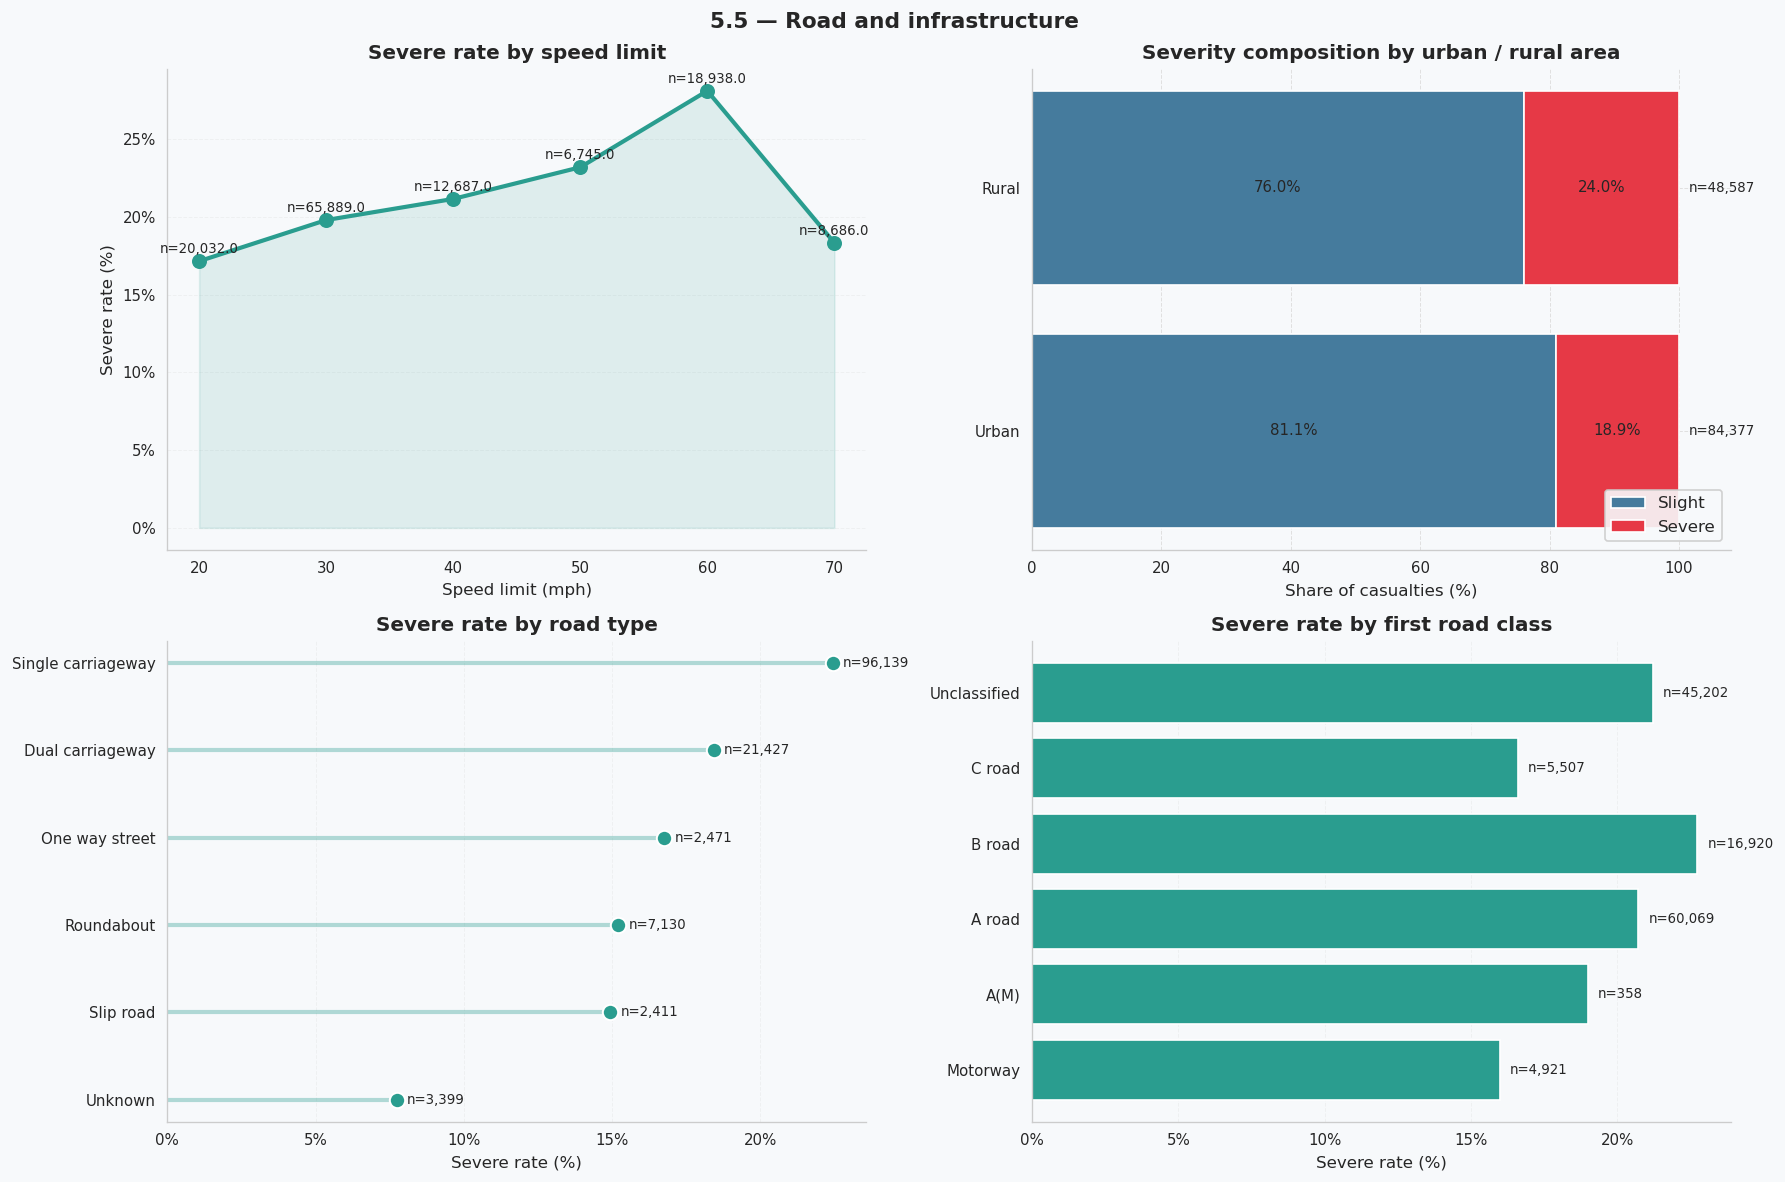

In [37]:
# Build severe rate tables for each road feature
speed_tbl = severe_rate_table(
    eda_df, "speed_limit", min_count=100,
    order=[20, 30, 40, 50, 60, 70], sort_desc=False
)

urban_tbl = severe_rate_table(
    eda_df, "urban_or_rural_area", min_count=100,
    label_map=URBAN_RURAL_LABELS,
    order=["Urban", "Rural", "Missing"], sort_desc=False
)

road_type_tbl = severe_rate_table(
    eda_df, "road_type", min_count=100,
    label_map=ROAD_TYPE_LABELS, sort_desc=True
)

road_class_tbl = severe_rate_table(
    eda_df, "first_road_class", min_count=100,
    label_map=FIRST_ROAD_CLASS_LABELS,
    order=["Motorway", "A(M)", "A road", "B road",
           "C road", "Unclassified", "Missing"],
    sort_desc=False
)

# Remove "Missing" rows from display — missingness patterns are
# already documented in Section 4.11. Including them here would
# confuse road-characteristic interpretation.
speed_tbl= speed_tbl[speed_tbl["label"] != "Missing"].copy()
urban_tbl= urban_tbl[urban_tbl["label"] != "Missing"].copy()
road_type_tbl  = road_type_tbl [road_type_tbl ["label"] != "Missing"].copy()
road_class_tbl = road_class_tbl[road_class_tbl["label"] != "Missing"].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top-left: speed limit line chart 
ax = axes[0, 0]
if not speed_tbl.empty:
    x = np.arange(len(speed_tbl))
    y = speed_tbl["rate_pct"].values

    ax.plot(x, y, marker="o", markersize=8, linewidth=2.5, color=ROAD_COL)
    ax.fill_between(x, y, 0, alpha=0.12, color=ROAD_COL)

    for i, row in speed_tbl.reset_index(drop=True).iterrows():
        ax.text(i, row["rate_pct"] + 0.5,
                f"n={row['n']:,}", ha="center", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(speed_tbl["label"].astype(str))
    ax.set_ylabel("Severe rate (%)")
    ax.set_xlabel("Speed limit (mph)")
    ax.set_title("Severe rate by speed limit", fontweight="bold")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
    )
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.grid(axis="x", visible=False)

# Top-right: urban/rural stacked bar
urban_comp = (
    eda_df.groupby("urban_or_rural_area")["target_severe"]
    .value_counts(normalize=True)
    .rename("prop")
    .mul(100)
    .reset_index()
)
urban_comp["area"] = urban_comp["urban_or_rural_area"].map(URBAN_RURAL_LABELS)

urban_pivot = (
    urban_comp.pivot(index="area", columns="target_severe", values="prop")
    .rename(columns={0: "Slight", 1: "Severe"})
    .reindex(["Urban", "Rural"])
    .fillna(0)
)

urban_n = (
    eda_df["urban_or_rural_area"]
    .map(URBAN_RURAL_LABELS)
    .value_counts()
    .reindex(["Urban", "Rural"])
)

ax = axes[0, 1]
ax.barh(urban_pivot.index, urban_pivot["Slight"],
        color=SLIGHT_COL, edgecolor="white", label="Slight")
ax.barh(urban_pivot.index, urban_pivot["Severe"],
        left=urban_pivot["Slight"],
        color=SEVERE_COL, edgecolor="white", label="Severe")

for i, area in enumerate(urban_pivot.index):
    s_val = urban_pivot.loc[area, "Slight"]
    sv_val= urban_pivot.loc[area, "Severe"]
    ax.text(s_val / 2,         i, f"{s_val:.1f}%",
            ha="center", va="center", fontsize=9)
    ax.text(s_val + sv_val / 2,i, f"{sv_val:.1f}%",
            ha="center", va="center", fontsize=9)
    ax.text(101.5, i, f"n={urban_n.loc[area]:,}",
            va="center", fontsize=8)

ax.set_xlim(0, 108)
ax.set_xlabel("Share of casualties (%)")
ax.set_title("Severity composition by urban / rural area", fontweight="bold")
ax.legend(loc="lower right")

# Bottom-left: road type lollipop 
lollipop_rate(axes[1, 0], road_type_tbl,
              color=ROAD_COL, title="Severe rate by road type")

# Bottom-right: first road class horizontal bar
ax = axes[1, 1]
if not road_class_tbl.empty:
    bars = ax.barh(road_class_tbl["label"], road_class_tbl["rate_pct"],
                   color=ROAD_COL, edgecolor="white", linewidth=1)

    for bar, n in zip(bars, road_class_tbl["n"]):
        ax.text(bar.get_width() + 0.35,
                bar.get_y() + bar.get_height() / 2,
                f"n={n:,}", va="center", fontsize=8)

    ax.set_xlabel("Severe rate (%)")
    ax.set_title("Severe rate by first road class", fontweight="bold")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
    )
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)

plt.suptitle("5.5 — Road and infrastructure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Speed limit:** Severe rate increases monotonically with speed limit up
to 60 mph (approx. 28%), then drops at 70 mph (approx. 22%). The 60 mph roads likely include many rural single carriageways where head-on and run-off collisions are common; the 70 mph drop may partly reflect motorway design features (central barriers, grade separation) that reduce collision severity despite higher speeds. *speed_limit* shows a moderate but meaningful signal and is retained.

**Urban/rural:** Rural casualties have a higher severe rate (**24%**) than urban casualties (**19%**), despite urban areas accounting for the majority of total casualties (n = 84,377 urban vs 48,587 rural). This is consistent with the road safety literature: rural roads have higher speed limits, fewer traffic management features, and longer emergency response times.

**Road type:** Single carriageway roads account for the vast majority of casualties (n = 96,139) and have a higher severe rate than dual carriageways, consistent with the absence of physical separation between opposing traffic flows.

**Road class:** Motorways have a relatively **low severe rate (approx. 17%)** despite high speeds, reflecting the protective effect of their design (barriers, no pedestrians, no junctions). Unclassified roads have the highest severe rate, likely capturing rural lanes where head-on collisions are severe but rarely fatal.

### 5.6 Environmental conditions

Severe rate is examined across three environmental variables: light conditions, weather conditions, and road surface conditions. These are all collision-level features with moderate coded missingness

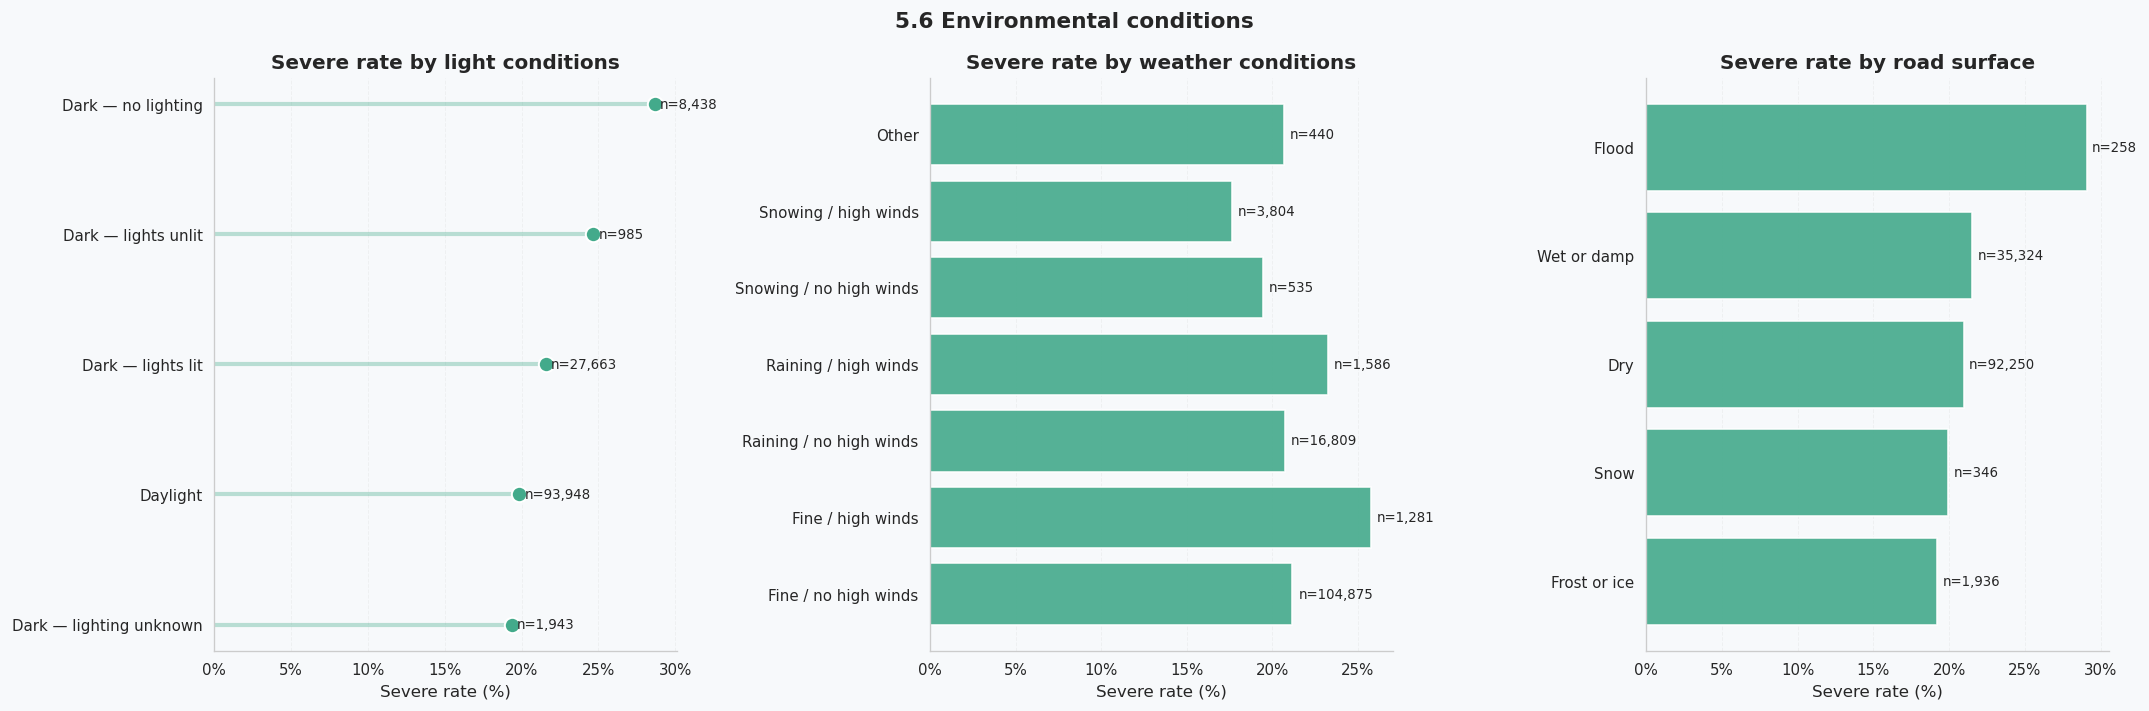

In [38]:
# Define display order from least to most severe expected condition
light_order = [
    "Daylight", "Dark: lights lit", "Dark: lights unlit",
    "Dark: no lighting", "Dark: lighting unknown"
]

weather_order = [
    "Fine / no high winds", "Fine / high winds",
    "Raining / no high winds", "Raining / high winds",
    "Snowing / no high winds", "Snowing / high winds",
    "Fog or mist", "Other"
]

surface_order = [
    "Dry", "Wet or damp", "Frost or ice", "Snow",
    "Flood", "Oil or diesel", "Mud"
]

# Build tables, excluding Missing rows for interpretability
light_tbl = severe_rate_table(
    eda_df, "light_conditions", min_count=100,
    label_map=LIGHT_LABELS, order=light_order, sort_desc=False
)
light_tbl = light_tbl[light_tbl["label"] != "Missing"].copy()

weather_tbl = severe_rate_table(
    eda_df, "weather_conditions", min_count=100,
    label_map=WEATHER_LABELS, order=weather_order, sort_desc=False
)
weather_tbl = weather_tbl[weather_tbl["label"] != "Missing"].copy()

surface_tbl = severe_rate_table(
    eda_df, "road_surface_conditions", min_count=100,
    label_map=ROAD_SURFACE_LABELS, order=surface_order, sort_desc=False
)
surface_tbl = surface_tbl[surface_tbl["label"] != "Missing"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#  Light conditions lollipop 
lollipop_rate(axes[0], light_tbl,
              color=ENV_COL, title="Severe rate by light conditions")

#  Weather conditions horizontal bar 
ax = axes[1]
if not weather_tbl.empty:
    bars = ax.barh(weather_tbl["label"], weather_tbl["rate_pct"],
                   color=ENV_COL, alpha=0.9, edgecolor="white", linewidth=1)
    for bar, (_, row) in zip(bars, weather_tbl.iterrows()):
        ax.text(bar.get_width() + 0.35,
                bar.get_y() + bar.get_height() / 2,
                f"n={row['n']:,}", va="center", fontsize=8)
    ax.set_title("Severe rate by weather conditions", fontweight="bold")
    ax.set_xlabel("Severe rate (%)")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
    )
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)

#  Road surface horizontal bar (sorted ascending for readability) 
ax = axes[2]
if not surface_tbl.empty:
    surface_tbl_plot = surface_tbl.sort_values("rate_pct", ascending=True)
    bars = ax.barh(surface_tbl_plot["label"], surface_tbl_plot["rate_pct"],
                   color=ENV_COL, alpha=0.9, edgecolor="white", linewidth=1)
    for bar, (_, row) in zip(bars, surface_tbl_plot.iterrows()):
        ax.text(bar.get_width() + 0.35,
                bar.get_y() + bar.get_height() / 2,
                f"n={int(row['n']):,}", va="center", fontsize=8)
    ax.set_title("Severe rate by road surface", fontweight="bold")
    ax.set_xlabel("Severe rate (%)")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
    )
    ax.set_xlim(left=0)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)

plt.suptitle("5.6 Environmental conditions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Light conditions:** Dark roads with no street lighting show the highest severe rate (approx. 29%), approximately 7 percentage points above daylight conditions (approx. 22%). This is consistent with reduced visibility, higher speeds on unlit rural roads, and longer emergency response times. light_conditions shows meaningful variation and is retained.

**Weather conditions:** Weather has surprisingly little variation in severe rate. All conditions fall between approx. 19% and approx. 25%. Fine weather with high winds shows a marginally elevated rate (approx. 24%), possibly capturing high-speed rural driving in adverse conditions. The similarity of rates across weather categories suggests weather alone is a weak predictor of severe injury, though it may interact with speed limit.

**Rad surface:** Flood conditions show the highest severe rate (approx. 29%, n = 258) but the very small sample limits confidence in this estimate. Wet/damp roads (approx. 21%) are only marginally above dry roads (approx. 20%), suggesting that road surface conditions are also a relatively weak standalone predictor after controlling for speed and road type.

### 5.7 Temporal patterns

This subsection examines severe rate and casualty volume by **hour of day** and **day of week**. The clock plot in the centre panel uses a polar coordinate system to visualise how severe rate varies across the 24-hour cycle, with bars coloured red when the hourly rate is above the daily average.

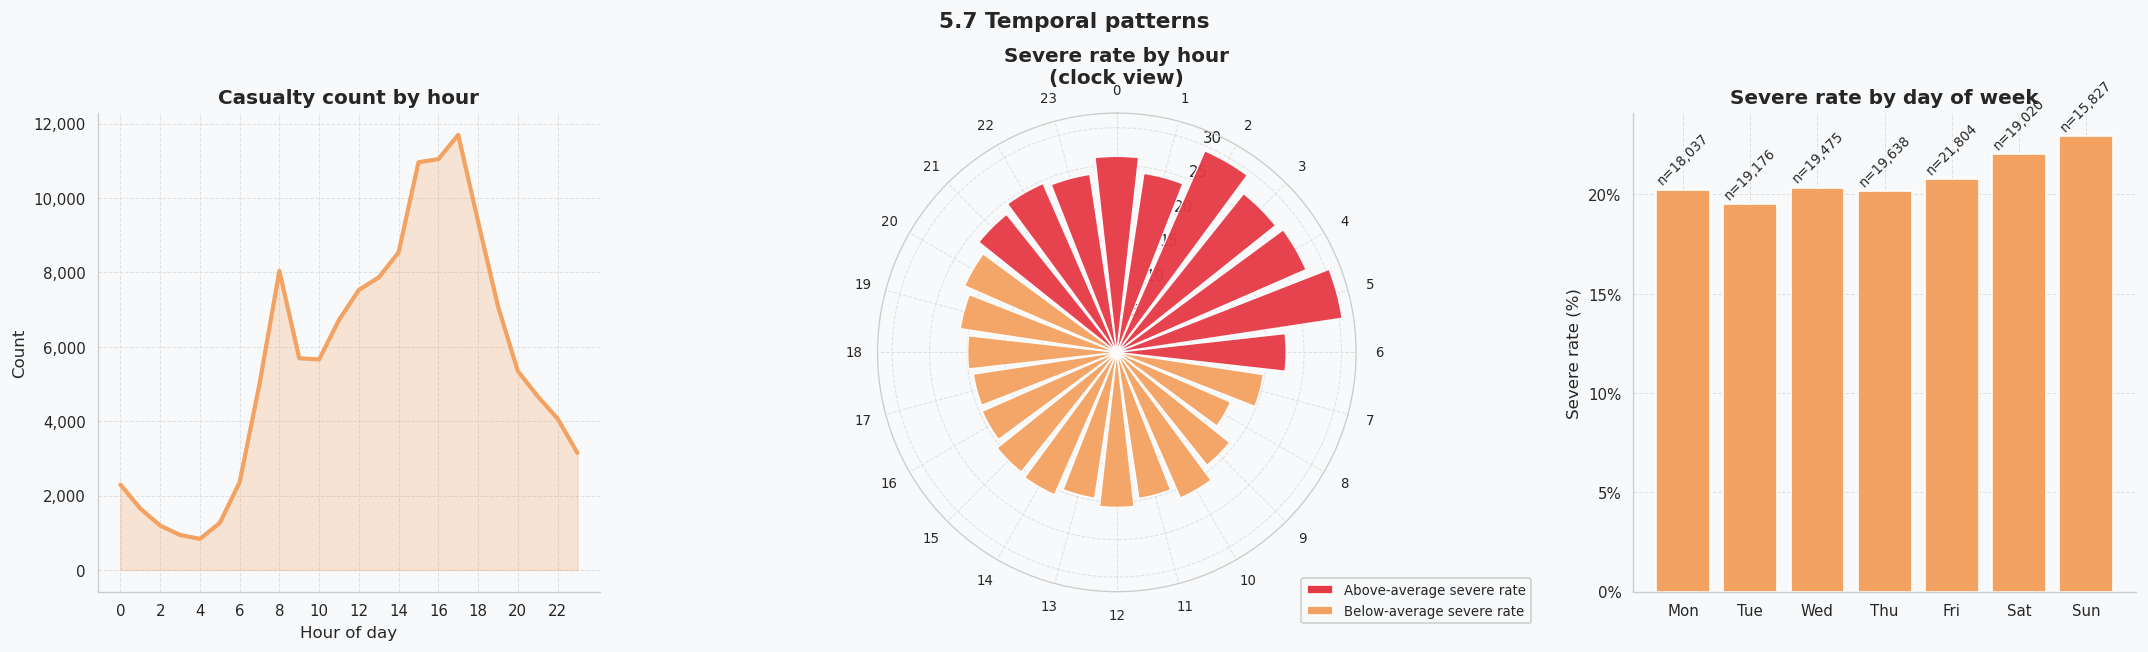

In [39]:
# Hourly casualty volume and severe rate (fill NaN hours with 0)

hourly_volume = eda_df["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)
hourly_rate = eda_df.groupby("hour")["target_severe"].mean().reindex(range(24)) * 100
hourly_rate = hourly_rate.fillna(0)

dow_tbl = (
    eda_df.groupby("day_of_week")["target_severe"]
    .agg(rate="mean", n="size")
    .reset_index()
)
dow_tbl["label"] = dow_tbl["day_of_week"].map(DAY_LABELS)
dow_tbl["rate_pct"] = dow_tbl["rate"] * 100
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_tbl["label"] = pd.Categorical(dow_tbl["label"], categories=dow_order, ordered=True)
dow_tbl = dow_tbl.sort_values("label")

fig = plt.figure(figsize=(18, 5.5))

# 1) Hourly volume
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(hourly_volume.index, hourly_volume.values, color=TIME_COL, linewidth=2.5)
ax1.fill_between(hourly_volume.index, hourly_volume.values, alpha=0.25, color=TIME_COL)
ax1.set_title("Casualty count by hour", fontweight="bold")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Count")
ax1.set_xticks(range(0, 24, 2))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 2) Polar / clock plot
ax2 = fig.add_subplot(1, 3, 2, projection="polar")
theta = np.linspace(0, 2 * np.pi, 24, endpoint=False)
width = 2 * np.pi / 24 * 0.85
bar_colors = [SEVERE_COL if v >= hourly_rate.mean() else TIME_COL for v in hourly_rate.values]

ax2.bar(
    theta,
    hourly_rate.values,
    width=width,
    bottom=0,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.95
)
ax2.set_theta_zero_location("N")
ax2.set_theta_direction(-1)
ax2.set_xticks(theta)
ax2.set_xticklabels([str(h) for h in range(24)], fontsize=8)
ax2.set_title("Severe rate by hour\n(clock view)", pad=18, fontweight="bold")

legend_elements = [
    Patch(facecolor=SEVERE_COL, label="Above-average severe rate"),
    Patch(facecolor=TIME_COL, label="Below-average severe rate")
]
ax2.legend(handles=legend_elements, loc="lower right", bbox_to_anchor=(1.38, -0.08), fontsize=8)

# 3) Day-of-week rate
ax3 = fig.add_subplot(1, 3, 3)
bars = ax3.bar(
    dow_tbl["label"].astype(str),
    dow_tbl["rate_pct"],
    color=TIME_COL,
    edgecolor="white",
    linewidth=1
)
for bar, n in zip(bars, dow_tbl["n"]):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.12,
        f"n={n:,}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=45
    )
ax3.set_title("Severe rate by day of week", fontweight="bold")
ax3.set_ylabel("Severe rate (%)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("5.7 Temporal patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Hour of day:** Casualty volume (left panel) follows the expected double-peak pattern of morning (approx. 08:00–09:00) and afternoon (approx. 16:00–17:00) rush hours. However, the clock plot (centre) shows that severe injury rate is actually **highest in the early hours (midnight–05:00)**, a period of low volume but elevated risk, likely due to higher speeds, fatigue, and impairment. Rush-hour collisions generate the most casualties but are predominantly low-severity urban incidents. The *is_night* and *is_rush_hour* binary features capture this contrast.

**DAy of week:** Severe rate is broadly flat across weekdays (approx. 20–21%) with a slight elevation on **Saturday and Sunday (~22%)**. This is consistent with higher weekend night-time driving, greater alcohol involvement, and more rural leisure journeys. The variation is modest, suggesting day of week is a weak standalone predictor but may contribute through interactions with *is_night*.

### 5.8 Collision-context flags

This subsection examines how the collision-context aggregates (built in Section 4.8) relate to severe injury rate. Each grouped bar pair compares the severe rate when a context flag is **absent** (blue, =0) versus **present** (red, =1).


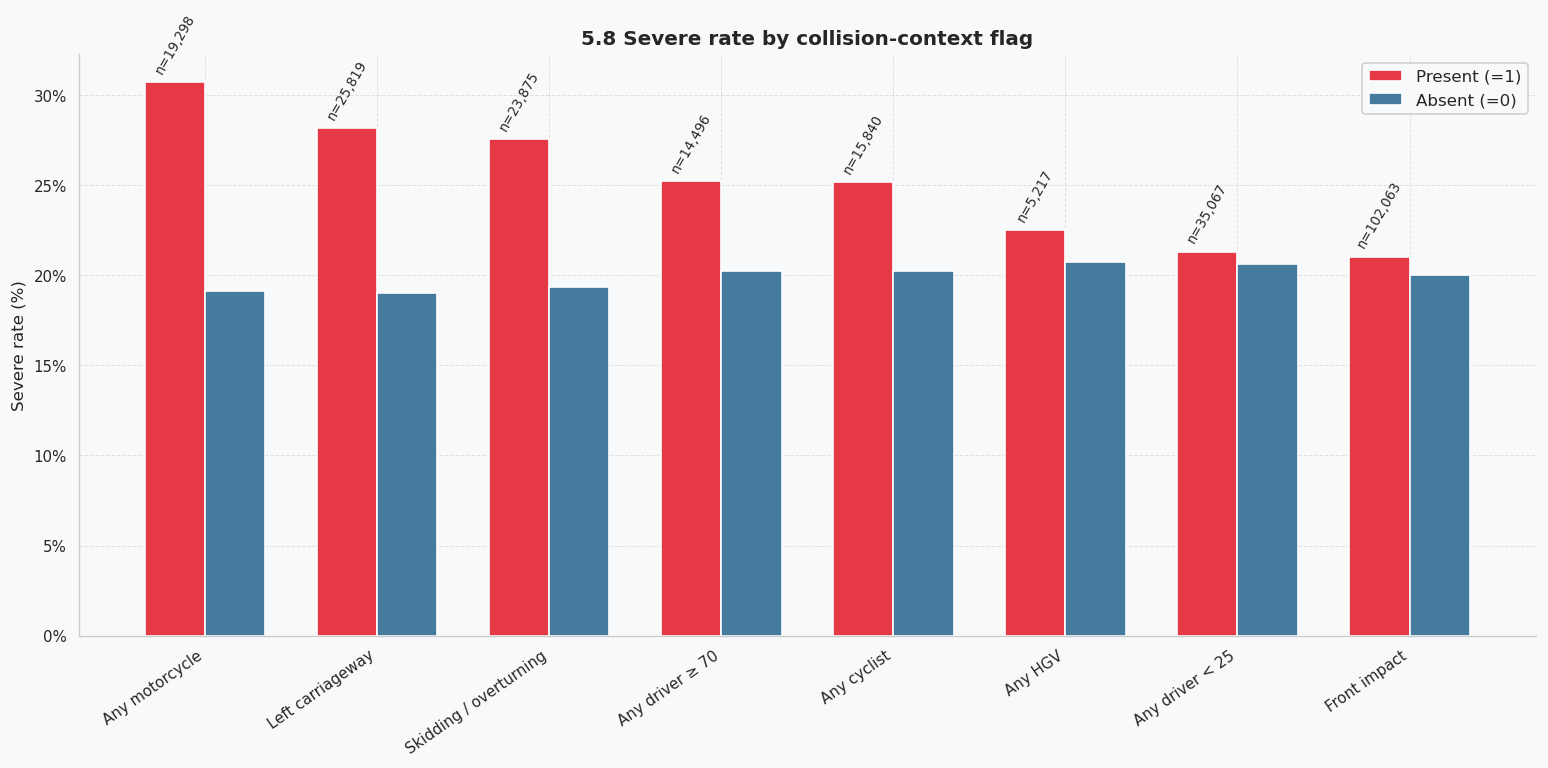

In [40]:
# Shows severe rate when each binary collision-context flag
# is present (=1) vs absent (=0). Sorted by rate_yes descending.
context_flag_specs = [
    ("ctx_any_motorcycle", "Any motorcycle"),
    ("ctx_any_hgv", "Any HGV"),
    ("ctx_any_bus", "Any bus/coach"),
    ("ctx_any_cycle", "Any cyclist"),
    ("ctx_any_skidding", "Skidding / overturning"),
    ("ctx_any_left_carriageway", "Left carriageway"),
    ("ctx_any_front_impact", "Front impact"),
    ("ctx_any_young_driver", "Any driver < 25"),
    ("ctx_any_elderly_driver", "Any driver ≥ 70")
]

# Keep only columns that actually exist
context_flag_specs_available = [
    (col, label) for col, label in context_flag_specs
    if col in eda_df.columns
]

context_flag_tbl = flag_compare_table(eda_df, context_flag_specs_available)
fig, ax = plt.subplots(figsize=(13, 6.5))

x = np.arange(len(context_flag_tbl))
width = 0.35

bars_yes = ax.bar(
    x - width/2,
    context_flag_tbl["rate_yes"],
    width=width,
    color=SEVERE_COL,
    edgecolor="white",
    linewidth=1,
    label="Present (=1)"
)

bars_no = ax.bar(
    x + width/2,
    context_flag_tbl["rate_no"],
    width=width,
    color=SLIGHT_COL,
    edgecolor="white",
    linewidth=1,
    label="Absent (=0)"
)

# Annotate present counts
for bar, n in zip(bars_yes, context_flag_tbl["n_yes"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.35,
        f"n={n:,}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=60
    )

ax.set_xticks(x)
ax.set_xticklabels(context_flag_tbl["label"], rotation=35, ha="right")
ax.set_ylabel("Severe rate (%)")
ax.set_title("5.8 Severe rate by collision-context flag", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Findings:** Motorcycle involvement shows the strongest association with severe outcomes: collisions involving at least one motorcycle have a **31% severe rate** vs 19% when no motorcycle is involved; a 12 percentage point gap. This is the largest effect of any context flag and reflects the well-documented vulnerability of motorcyclists to serious injury.

Left carriageway departure and skidding/overturning show the next largest gaps (approx. 9 and approx.8 percentage points respectively), consistent with the higher impact forces involved in loss-of-control events. Elderly drivers (≥70) and cyclist involvement show moderate gaps (approx. 5 points each).

Front impact has a large *n_yes* (n = 102,063; almost 80% of collisions have at least one front impact) but only a approx. 1 percentage point gap, meaning it discriminates poorly despite its frequency. It may still contribute to ensemble models through interactions with other features. Young driver involvement shows a negligible gap (<1 point), suggesting that the presence of a young driver in a collision does not materially predict the severity of *other* casualties in that collision.

### 5.9 Number of vehicles involved

Single-vehicle collisions (where only one vehicle is recorded) are structurally different from multi-vehicle crashes: they typically involve run-off-road events, pedestrian strikes, or cyclist falls, which tend to be higher severity. This plot checks whether *number_of_vehicles* carries severity signal.

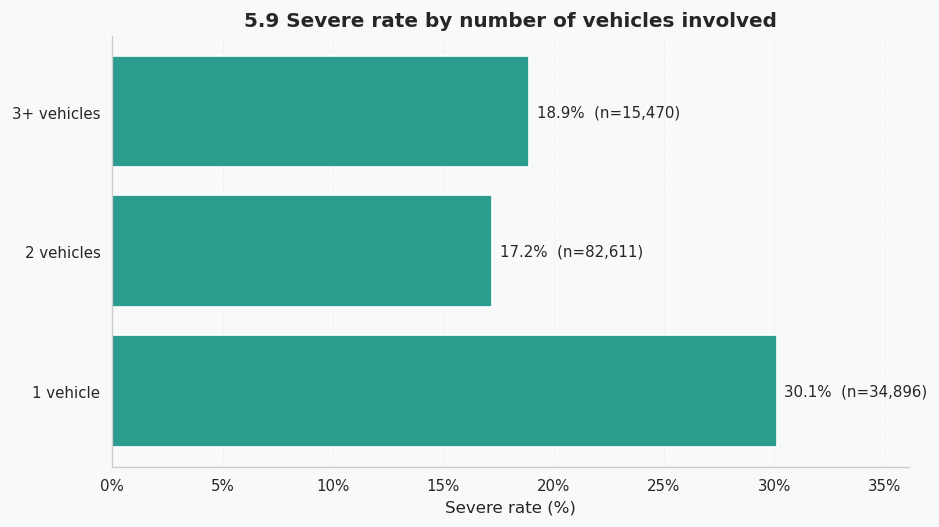

In [41]:
eda_df["vehicles_involved_band"] = pd.cut(
    eda_df["number_of_vehicles"],
    bins=[0, 1, 2, 50],
    labels=["1 vehicle", "2 vehicles", "3+ vehicles"],
    include_lowest=True
)

veh_count_tbl = severe_rate_table(
    eda_df,
    "vehicles_involved_band",
    min_count=50,
    order=["1 vehicle", "2 vehicles", "3+ vehicles"],
    sort_desc=False
)

veh_count_tbl = veh_count_tbl[veh_count_tbl["label"] != "Missing"].copy()

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.barh(
    veh_count_tbl["label"],
    veh_count_tbl["rate_pct"],
    color=ROAD_COL,
    edgecolor="white",
    linewidth=1
)

for bar, (_, row) in zip(bars, veh_count_tbl.iterrows()):
    ax.text(
        bar.get_width() + 0.35,
        bar.get_y() + bar.get_height() / 2,
        f"{row['rate_pct']:.1f}%  (n={int(row['n']):,})",
        va="center",
        fontsize=9
    )

ax.set_xlabel("Severe rate (%)")
ax.set_title("5.9 Severe rate by number of vehicles involved", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)

ax.set_xlim(0, veh_count_tbl["rate_pct"].max() + 6)

plt.tight_layout()
plt.show()

Single-vehicle collisions have the highest severe rate at **30.1%**,substantially above two-vehicle (17.2%) and three-or-more-vehicle (18.9%) collisions.his confirms that single-vehicle events which include pedestrian strikes, cyclist falls, and run-off-road crashes are disproportionately severe. Two-vehicle collisions are the most common (n = 82,611) and have the lowest severe rate, consistent with lower-speed urban rear-end and junction-type crashes dominating this category. *number_of_vehicles* is retained as a continuous feature in modelling.


### 5.10 Pearson correlation heatmap

A Pearson correlation matrix is computed across the numeric, ordinal, and binary
features to check for:

1. **Target–feature correlations**: which numeric features have the strongest
   linear relationship with target_severe.
2. **Inter-feature collinearity**: pairs of features so highly correlated that
   retaining both adds redundancy without information.

Categorically coded variables (e.g. road_type`, weather_conditions) are excluded
because Pearson correlation is not meaningful for unordered nominal codes.

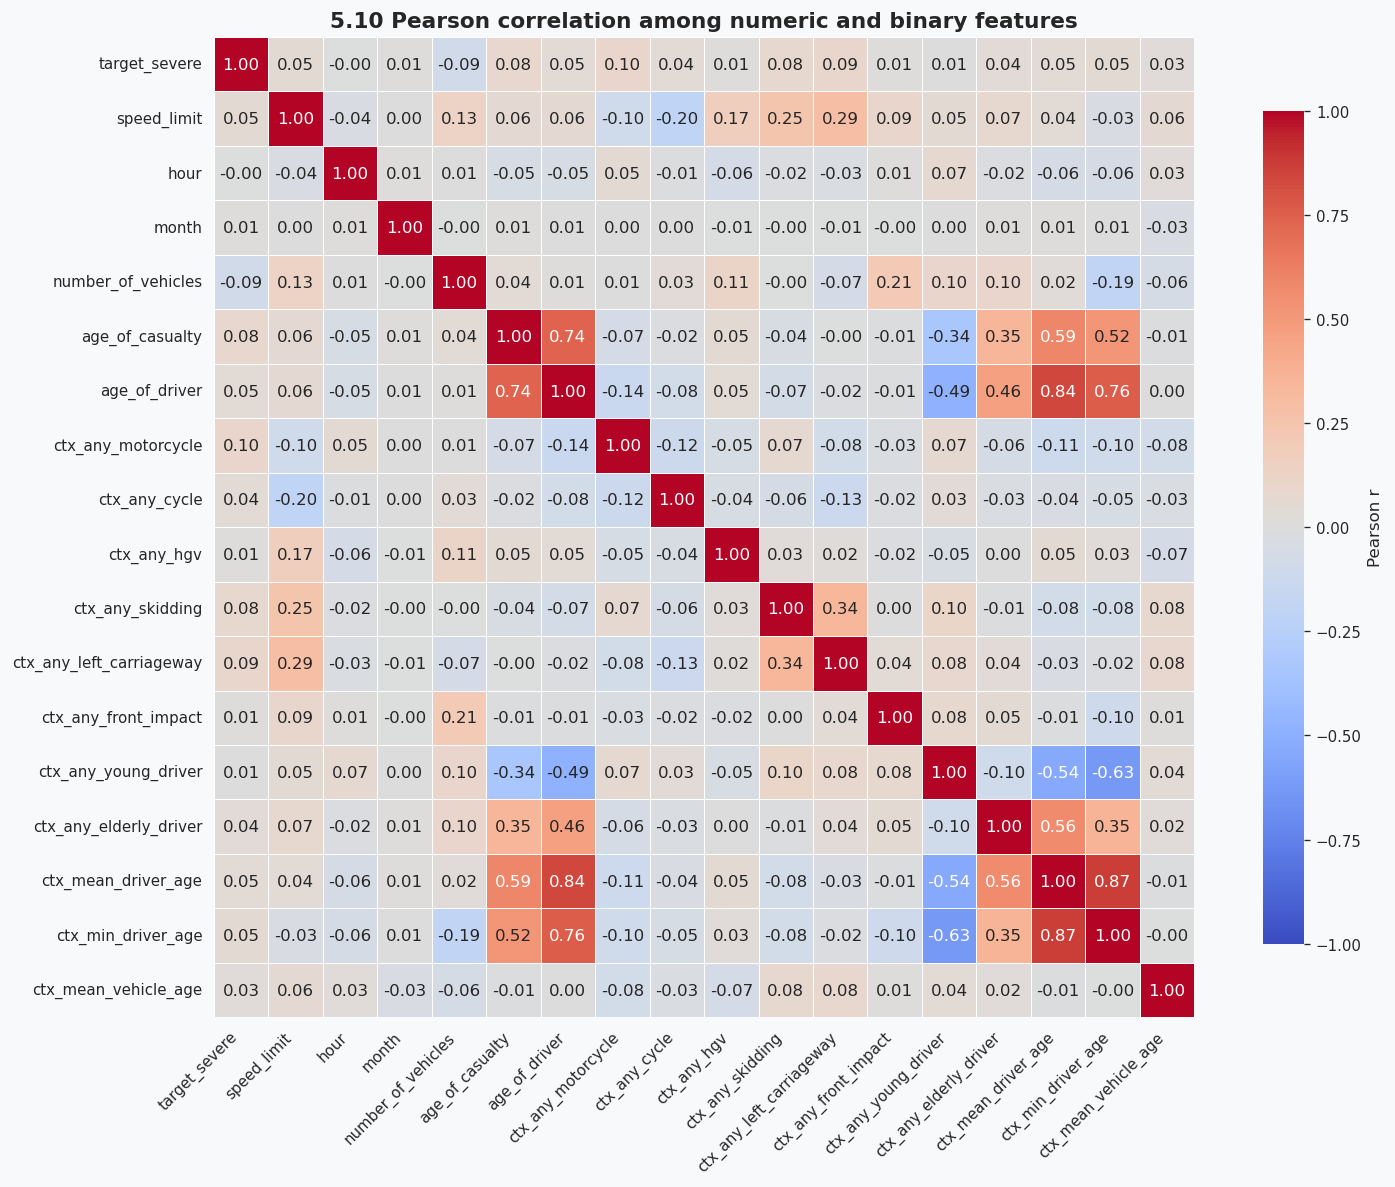

Highly correlated feature pairs (|r| >= 0.85):


,feature_1,feature_2,abs_correlation
150,ctx_mean_driver_age,ctx_min_driver_age,0.8707


In [42]:
# Only numeric, ordinal, and binary features are included.
# Nominally coded categoricals (road_type, weather_conditions, etc.)
# are excluded because Pearson r is not interpretable for them.

heatmap_cols = [
    "target_severe",          # target (binary)
    "speed_limit",            # ordinal / continuous
    "hour", "month",
    "number_of_vehicles",
    "age_of_casualty",
    "age_of_driver",
    "ctx_any_motorcycle",     # binary context flags
    "ctx_any_cycle",
    "ctx_any_hgv",
    "ctx_any_skidding",
    "ctx_any_left_carriageway",
    "ctx_any_front_impact",
    "ctx_any_young_driver",
    "ctx_any_elderly_driver",
    "ctx_mean_driver_age",    # continuous context aggregates
    "ctx_min_driver_age",
    "ctx_mean_vehicle_age",
]

heatmap_cols = [c for c in heatmap_cols if c in eda_df.columns]
corr = eda_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.85, "label": "Pearson r"},
    ax=ax
)

ax.set_title(
    "5.10 Pearson correlation among numeric and binary features",
    fontsize=13, fontweight="bold"
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Flag all feature pairs with |r| >= 0.85 for collinearity review.
# The threshold of 0.85 is conventional for flagging near-redundant
# features in linear models; tree models are less sensitive but
# high collinearity still increases variance in importance estimates.
corr_abs = corr.abs()
upper= corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1",
                     "level_1": "feature_2",
                     0:"abs_correlation"})
)
high_corr_pairs = (
    high_corr_pairs[high_corr_pairs["abs_correlation"] >= 0.85]
    .sort_values("abs_correlation", ascending=False)
)

print("Highly correlated feature pairs (|r| >= 0.85):")
if high_corr_pairs.empty:
    print("None found.")
else:
    display(high_corr_pairs.round(4))

The correlation heatmap shows mostly weak linear relationships between the numeric or binary predictors and the target. This is expected because many important predictors are categorical, non-linear, or interaction-based. One highly correlated pair is identified: ***ctx_mean_driver_age*** and ***ctx_min_driver_age*** have an absolute correlation of approximately 0.87. To reduce redundancy, ctx_min_driver_age will be removed before modelling, while ctx_mean_driver_age will be retained as the more interpretable collision-level driver-age summary.

The weak target correlations should not be interpreted as evidence that the features are useless. Tree-based models can still use non-linear relationships, interactions, and categorical splits that Pearson correlation does not capture.

## Section 6: Feature preparation, grouped train/test split, and preprocessing

This section prepares the final modelling dataset for machine learning. No models are trained in this section. The unit of analysis remains one row per casualty, while ***collision_index*** is used as the grouping variable.

The train/test split is performed by collision rather than by individual casualty. This is necessary because multiple casualties from the same collision can share collision-level and vehicle-context features. Grouped splitting prevents casualties from the same collision appearing in both the training and test sets.

Preprocessing is fitted only on the training data and then applied to the test data. This avoids leakage from the test set into imputation, scaling, and one-hot encoding.

### 6.1 Feature audit: missingness, cardinality, and dominant values

Before selecting the final feature set, candidate predictors are audited for missingness, number of unique values, and dominant-value percentage. This helps identify variables with high missingness, near-zero variance, or excessive detail.

In [43]:
# Identifiers (collision_index, vehicle_reference, casualty_reference)
# and target columns (target_severe, target_label) are excluded from
# the candidate list — they are never features.

target_col = "target_severe" #target_severe is the binary outcome.
group_col = "collision_index" #collision_index identifies the collision and is used for grouped splitting.

id_cols = [
    "collision_index",
    "vehicle_reference",
    "casualty_reference"
]

non_feature_cols = [
    "target_severe",
    "target_label"
]

#creates a list of possible model features by removing identifiers and target columns.
candidate_features = [
    c for c in model_df.columns
    if c not in id_cols + non_feature_cols
]

feature_audit = pd.DataFrame({
    "feature": candidate_features,
    "dtype": [str(model_df[c].dtype) for c in candidate_features],
    "missing_percent": [round(model_df[c].isna().mean() * 100, 2) for c in candidate_features],
    "n_unique": [model_df[c].nunique(dropna=True) for c in candidate_features], # Number of distinct non-NaN values
     # Percentage of rows taken by the single most common value
     # (including NaN as a category); >95% flags near-zero variance
    "top_value_percent": [
        round(model_df[c].value_counts(dropna=False, normalize=True).iloc[0] * 100, 2)
        for c in candidate_features
    ]
})

print("Feature audit: highest missingness:")
display(
    feature_audit
    .sort_values("missing_percent", ascending=False)
    .head(20)
)

print("Feature audit: near-zero variance / dominant value:")
display(
    feature_audit
    .sort_values("top_value_percent", ascending=False)
    .head(20)
)

Feature audit: highest missingness:


,feature,dtype,missing_percent,n_unique,top_value_percent
34,junction_control,float64,45.19,4,45.19
25,engine_capacity_cc,float64,22.96,864,22.96
27,age_of_vehicle,float64,21.51,74,21.51
26,propulsion_code,float64,21.47,11,45.95
63,ctx_mean_vehicle_age,float64,9.26,301,9.26
16,skidding_and_overturning,float64,8.66,6,76.35
18,vehicle_leaving_carriageway,float64,8.59,9,75.64
37,trunk_road_flag,float64,7.63,2,84.78
11,vehicle_manoeuvre,float64,7.61,17,59.31
36,pedestrian_crossing,float64,6.41,8,73.67


Feature audit: near-zero variance / dominant value:


,feature,dtype,missing_percent,n_unique,top_value_percent
28,escooter_flag,int64,0.00,2,99.02
57,ctx_any_escooter,int8,0.00,2,98.96
6,bus_or_coach_passenger,int64,0.00,7,98.35
7,pedestrian_road_maintenance_worker,int64,0.00,4,97.67
55,ctx_any_bus,int8,0.00,2,96.41
54,ctx_any_hgv,int8,0.00,2,96.08
10,towing_and_articulation,int64,0.00,8,96.07
21,vehicle_left_hand_drive,int64,0.00,3,95.98
50,is_weekend_night,int64,0.00,2,95.21
42,special_conditions_at_site,float64,6.26,8,91.48


The audit shows that several variables have substantial missingness, including *junction_control*, *age_of_vehicle*, *propulsion_code*, and aggregated vehicle-age features. Missingness is retained at this stage and handled later inside the preprocessing pipeline. The dominant-value audit also identifies rare-detail or near-zero-variance variables, such as *escooter_flag*, *ctx_any_escooter*, and *bus_or_coach_passenger*, which are candidates for exclusion from the compact feature set.

### 6.2 Explicit drop list

The drop list below documents every feature excluded from the compact model, grouped by exclusion reason. This is the complete audit trail; any feature not in the keep list (Section 6.3) appears here with a stated reason.

In [44]:
# Features excluded from the compact modelling set.
# Each group has an explicit reason to make the selection auditable.
drop_for_compact_model = [
    # Redundant / correlation / encoding issue
    "ctx_min_driver_age",
    "day_of_week",

    # Near-zero variance or rare detail
    "escooter_flag",
    "ctx_any_escooter",
    "bus_or_coach_passenger",
    "pedestrian_road_maintenance_worker",
    "ctx_any_bus",
    "towing_and_articulation",
    "vehicle_left_hand_drive",

    # Too granular / high-detail variables
    "vehicle_direction_from",
    "vehicle_direction_to",
    "vehicle_location_restricted_lane",
    "hit_object_in_carriageway",
    "hit_object_off_carriageway",
    "junction_location",
    "second_road_class",

    # High missingness or less central for compact model
    "propulsion_code",

    # Road-site details excluded to reduce dimensionality
    "special_conditions_at_site",
    "carriageway_hazards",

    # Excluded for compactness / weaker EDA role
    "engine_capacity_cc",
    "ctx_any_car",
    "ctx_any_van"
]
print(f"Features in drop list: {len(drop_for_compact_model)}")
print(drop_for_compact_model)

Features in drop list: 22
['ctx_min_driver_age', 'day_of_week', 'escooter_flag', 'ctx_any_escooter', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'ctx_any_bus', 'towing_and_articulation', 'vehicle_left_hand_drive', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane', 'hit_object_in_carriageway', 'hit_object_off_carriageway', 'junction_location', 'second_road_class', 'propulsion_code', 'special_conditions_at_site', 'carriageway_hazards', 'engine_capacity_cc', 'ctx_any_car', 'ctx_any_van']


### 6.3 Final selected feature set

The 42 features retained for modelling span six thematic groups. Each feature was retained because it showed meaningful variation in severe rate in Section 5 EDA **and** is free from the exclusion criteria in Section 6.2.

In [45]:
# All features listed here are present in model_df after the cleaning
# and merging steps in Section 4. The list comprehension at the end
# guards against any column that was silently dropped upstream.
selected_features = [
    # Casualty-level features
    "casualty_class",
    "sex_of_casualty",
    "age_of_casualty",
    "casualty_type",
    "pedestrian_location",
    "pedestrian_movement",

    # Own vehicle / driver features
    "vehicle_type",
    "vehicle_manoeuvre",
    "skidding_and_overturning",
    "vehicle_leaving_carriageway",
    "first_point_of_impact",
    "journey_purpose_of_driver",
    "sex_of_driver",
    "age_of_driver",
    "age_of_vehicle",

    # Road and infrastructure
    "speed_limit",
    "number_of_vehicles",
    "road_type",
    "first_road_class",
    "junction_detail",
    "junction_control",
    "urban_or_rural_area",
    "trunk_road_flag",

    # Environmental conditions
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",

    # Time features
    "hour",
    "month",
    "is_weekend",
    "is_night",
    "is_rush_hour",
    "is_weekend_night",

    # Collision-context vehicle features
    "ctx_any_motorcycle",
    "ctx_any_cycle",
    "ctx_any_hgv",
    "ctx_any_skidding",
    "ctx_any_left_carriageway",
    "ctx_any_front_impact",
    "ctx_any_young_driver",
    "ctx_any_elderly_driver",
    "ctx_mean_driver_age",
    "ctx_mean_vehicle_age",
]

selected_features = [c for c in selected_features if c in model_df.columns]

print("Selected raw feature count:", len(selected_features))
print(selected_features)

excluded_available = [
    c for c in candidate_features
    if c not in selected_features
]

print("\nAvailable candidate features excluded from compact model:", len(excluded_available))
print(excluded_available)

Selected raw feature count: 42
['casualty_class', 'sex_of_casualty', 'age_of_casualty', 'casualty_type', 'pedestrian_location', 'pedestrian_movement', 'vehicle_type', 'vehicle_manoeuvre', 'skidding_and_overturning', 'vehicle_leaving_carriageway', 'first_point_of_impact', 'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver', 'age_of_vehicle', 'speed_limit', 'number_of_vehicles', 'road_type', 'first_road_class', 'junction_detail', 'junction_control', 'urban_or_rural_area', 'trunk_road_flag', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'hour', 'month', 'is_weekend', 'is_night', 'is_rush_hour', 'is_weekend_night', 'ctx_any_motorcycle', 'ctx_any_cycle', 'ctx_any_hgv', 'ctx_any_skidding', 'ctx_any_left_carriageway', 'ctx_any_front_impact', 'ctx_any_young_driver', 'ctx_any_elderly_driver', 'ctx_mean_driver_age', 'ctx_mean_vehicle_age']

Available candidate features excluded from compact model: 25
['car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_ma

The final feature set contains **42 raw features** spanning casualty, vehicle,
road, environment, temporal, and collision-context dimensions. After one-hot
encoding of the 21 categorical features, the preprocessed matrix expands to
190 columns (confirmed in Section 6.8). No feature selection is applied
inside the modelling pipeline — the set defined here is used consistently
across all models in Sections 7–12, ensuring fair comparison.

### 6.4 Create feature matrix, target vector, and group identifier

*X* contains the 42 selected raw features. *y* is the binary target (***target_severe***).
*groups* is the *collision_index* vector used to enforce group-aware splitting
ensuring all casualties from the same collision are assigned to the same partition
and no collision-level information leaks between train and test.

In [46]:
# Safety checks before extracting arrays
assert target_col in model_df.columns, "Target column missing."
assert group_col in model_df.columns, "Group column missing."

# Extract feature matrix, target, and group key
X = model_df[selected_features].copy()
y = model_df[target_col].copy()
groups = model_df[group_col].copy()

print("Compact feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Groups shape:", groups.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Compact feature matrix shape: (132977, 42)
Target shape: (132977,)
Groups shape: (132977,)

Target distribution:
target_severe
0    105323
1     27654
Name: count, dtype: int64

Target distribution (%):
target_severe
0    79.2
1    20.8
Name: proportion, dtype: float64


### 6.5 Group-aware train/test split

A standard random train/test split would assign rows to train or test independently.

***GroupShuffleSplit*** with ***groups=collision_index*** ensures that **all casualties
from a given collision are assigned to the same partition**. The overlap assertion
below verifies this.

The 80/20 split is applied at the collision level (not the casualty level), producing
approximately 80% of casualties in training and 20% in the held-out test set.

In [47]:
# GroupShuffleSplit splits by collision_index (the group key),
# so all casualties from the same collision go to the same fold.
# This prevents the model from exploiting shared collision-level
# features across train and test rows.

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

Train shape: (106307, 42)
Test shape: (26670, 42)
Train target shape: (106307,)
Test target shape: (26670,)


#### 6.5b Verify no collision appears in both train and test.

In [48]:
# This is the key leakage check for grouped splitting.
# If any collision_index appears in both sets, casualties from that collision would have shared features across partitions.
train_collisions = set(groups_train)
test_collisions = set(groups_test)

overlap = train_collisions & test_collisions

assert len(overlap) == 0, "Collision leakage in split."

print(f"Collision overlap between train and test: {len(overlap)}  ✓")
print(f"Unique collisions in train : {len(train_collisions):,}")
print(f"Unique collisions in test: {len(test_collisions):,}")

print(f"\nTrain severe rate : {y_train.mean():.3f}")
print(f"Test severe rate  : {y_test.mean():.3f}")

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3).to_string())

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3).to_string())

Collision overlap between train and test: 0  ✓
Unique collisions in train : 83,406
Unique collisions in test: 20,852

Train severe rate : 0.207
Test severe rate  : 0.212

Train class distribution:
target_severe
0    0.793
1    0.207

Test class distribution:
target_severe
0    0.788
1    0.212


### 6.6 Feature type classification

Each of the 42 selected features is classified as either **numeric** or
**categorical** to control how the preprocessing pipeline handles it

In [49]:
# Binary numeric: 0/1 integer flags; no category codes to decode.
# Continuous numeric: genuine numeric quantities (age, speed, count).
# Categorical: STATS19 numerically coded nominal variables.

# Every column in X_train must be assigned to exactly one group the assertion at the end enforces this.

binary_numeric_cols = [
    "is_weekend",
    "is_night",
    "is_rush_hour",
    "is_weekend_night",

    "ctx_any_motorcycle",
    "ctx_any_cycle",
    "ctx_any_hgv",
    "ctx_any_young_driver",
    "ctx_any_elderly_driver",
    "ctx_any_skidding",
    "ctx_any_left_carriageway",
    "ctx_any_front_impact",
]

continuous_numeric_cols = [
    "speed_limit",
    "number_of_vehicles",
    "hour",
    "month",
    "age_of_casualty",
    "age_of_driver",
    "age_of_vehicle",
    "ctx_mean_driver_age",
    "ctx_mean_vehicle_age",
]

numeric_features = [
    col for col in binary_numeric_cols + continuous_numeric_cols
    if col in X_train.columns
]

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

unaccounted = [
    c for c in X_train.columns
    if c not in numeric_features + categorical_features
]

print("\nUnaccounted columns:", unaccounted)

assert len(unaccounted) == 0, "Some columns are not assigned to numeric or categorical features."

Number of numeric features: 21
['is_weekend', 'is_night', 'is_rush_hour', 'is_weekend_night', 'ctx_any_motorcycle', 'ctx_any_cycle', 'ctx_any_hgv', 'ctx_any_young_driver', 'ctx_any_elderly_driver', 'ctx_any_skidding', 'ctx_any_left_carriageway', 'ctx_any_front_impact', 'speed_limit', 'number_of_vehicles', 'hour', 'month', 'age_of_casualty', 'age_of_driver', 'age_of_vehicle', 'ctx_mean_driver_age', 'ctx_mean_vehicle_age']

Number of categorical features: 21
['casualty_class', 'sex_of_casualty', 'casualty_type', 'pedestrian_location', 'pedestrian_movement', 'vehicle_type', 'vehicle_manoeuvre', 'skidding_and_overturning', 'vehicle_leaving_carriageway', 'first_point_of_impact', 'journey_purpose_of_driver', 'sex_of_driver', 'road_type', 'first_road_class', 'junction_detail', 'junction_control', 'urban_or_rural_area', 'trunk_road_flag', 'light_conditions', 'weather_conditions', 'road_surface_conditions']

Unaccounted columns: []


All 42 features are assigned: **21 numeric** (12 binary + 9 continuous) and
**21 categorical**. The categorical group includes all STATS19 coded variables whose
integer codes represent nominal categories rather than ordered quantities. After
one-hot encoding these 21 categorical features expand to approximately 169 binary
columns, producing a final preprocessed matrix of 190 features (confirmed in
Section 6.8).

### 6.7 Preprocessing pipeline

A single *sklearn* *ColumnTransformer* pipeline is constructed with two branches:

**Numeric branch** (*numeric_transformer*):
1. *SimpleImputer(strategy="median")* : replaces NaN with the column median.
   Median is preferred over mean for skewed distributions (e.g. age, speed limit).
2. *StandardScaler()* : centres and scales to unit variance. Required for
   Logistic Regression (gradient descent convergence); harmless for tree models.

**Categorical branch** (*categorical_transformer*):
1. *FunctionTransformer(astype object)* : converts numeric-coded columns to Python
   object dtype before imputation, so the imputer treats them as strings.
2. *SimpleImputer(strategy="constant", fill_value="Missing")* : replaces NaN with
   the literal string "Missing", which becomes its own one-hot category. This
   preserves missingness as a potentially predictive signal rather than discarding it.
3. *FunctionTransformer(astype str)* : converts all values to string for the OHE.
4. *OneHotEncoder(handle_unknown="ignore", sparse_output=True)*: one-hot encodes
   all categories seen in training. Unseen categories at test time are ignored
   (all-zero row) rather than raising an error.


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

# Imbalance is not handled in preprocessing.
# In later model sections, class_weight='balanced' will be used where supported.

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Many categorical variables are numeric-coded, e.g. road_type and vehicle_type.
# They are converted to object, imputed, then converted to string before one-hot encoding.
categorical_transformer = Pipeline(
    steps=[
        ("to_object", FunctionTransformer(lambda X: X.astype(object), validate=False)),
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("to_string", FunctionTransformer(lambda X: X.astype(str), validate=False)),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop" #means any column not listed is dropped.
)

print("Preprocessing pipeline created.")
print(f"Numeric branch  : {len(numeric_features)} input features")
print(f"Categorical branch: {len(categorical_features)} input features")

Preprocessing pipeline created.
Numeric branch  : 21 input features
Categorical branch: 21 input features


### 6.8 Preprocessing validation

**Leakage guarantee:** The preprocessor is fitted on the full ***X_train*** and applied to ***X_test*** here for
two purposes only:

1. **Shape check**: confirm the output matrix has the expected number of rows and
   that no rows were dropped.
2. **NaN check** : confirm that all missing values were handled (imputation
   produced no residual NaN).

> **Important:** This fit is for validation only. All downstream model pipelines use *clone(preprocessor)* to obtain a fresh unfitted copy.

In [51]:
import scipy.sparse as sp
# This is a one-off validation step only.
# Downstream pipelines clone the preprocessor and refit per fold.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)   # transform only — no fit

print(f"Processed training matrix : {X_train_processed.shape}")
print(f"Processed test matrix: {X_test_processed.shape}")

# Row counts must match the unprocessed splits exactly
assert X_train_processed.shape[0] == X_train.shape[0], (
    "Row count changed during preprocessing of training data."
)
assert X_test_processed.shape[0] == X_test.shape[0], (
    "Row count changed during preprocessing of test data."
)
print("Row-count assertion passed.")

# Check no NaN values remain after imputation
if sp.issparse(X_train_processed):
    assert not np.isnan(X_train_processed.data).any(), \
        "NaN values found in sparse processed training data."
    assert not np.isnan(X_test_processed.data).any(), \
        "NaN values found in sparse processed test data."
else:
    assert not np.isnan(X_train_processed).any(), \
        "NaN values found in processed training data."
    assert not np.isnan(X_test_processed).any(), \
        "NaN values found in processed test data."

print("NaN check passed: no missing values remain after imputation.")

Processed training matrix : (106307, 190)
Processed test matrix: (26670, 190)
Row-count assertion passed.
NaN check passed: no missing values remain after imputation.


### 6.9 Extract processed feature names

***FunctionTransformer*** does not implement ***get_feature_names_out***, so feature names
for the preprocessed matrix must be constructed manually. These names are needed
later for SHAP interpretation in Section 11 to label each feature contribution.

In [52]:
# Manually extract feature names because FunctionTransformer does not expose get_feature_names_out.
# Numeric: prefix "num__" + original feature name
num_feature_names = np.array([
    f"num__{col}" for col in numeric_features
])

# Categorical: extract from the fitted OneHotEncoder then prefix "cat__"
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
cat_feature_names = np.array([
    f"cat__{name}" for name in cat_feature_names
])

# Concatenate in the same order as ColumnTransformer output
# (numeric block first, then categorical block)
feature_names = np.concatenate([num_feature_names, cat_feature_names])

print(f"Total processed feature names : {len(feature_names)}")
print(f"Processed matrix columns: {X_train_processed.shape[1]}")

assert len(feature_names) == X_train_processed.shape[1], (
    "Feature-name count does not match processed matrix column count. "
    "Check that numeric_features and categorical_features are up to date."
)

print("Feature-name alignment check passed.")
print("\nFirst 30 processed feature names:")
print(feature_names[:30])

Total processed feature names : 190
Processed matrix columns: 190
Feature-name alignment check passed.

First 30 processed feature names:
['num__is_weekend' 'num__is_night' 'num__is_rush_hour'
 'num__is_weekend_night' 'num__ctx_any_motorcycle' 'num__ctx_any_cycle'
 'num__ctx_any_hgv' 'num__ctx_any_young_driver'
 'num__ctx_any_elderly_driver' 'num__ctx_any_skidding'
 'num__ctx_any_left_carriageway' 'num__ctx_any_front_impact'
 'num__speed_limit' 'num__number_of_vehicles' 'num__hour' 'num__month'
 'num__age_of_casualty' 'num__age_of_driver' 'num__age_of_vehicle'
 'num__ctx_mean_driver_age' 'num__ctx_mean_vehicle_age'
 'cat__casualty_class_1' 'cat__casualty_class_2' 'cat__casualty_class_3'
 'cat__sex_of_casualty_1.0' 'cat__sex_of_casualty_2.0'
 'cat__sex_of_casualty_Missing' 'cat__casualty_type_0.0'
 'cat__casualty_type_1.0' 'cat__casualty_type_10.0']


## Section 7: Untuned Baseline Models: 10-Fold Grouped Cross-Validation

This section evaluates the untuned baseline models using 10-fold stratified grouped cross-validation on the training set only. The held-out test set is not used here and remains reserved for final evaluation.

The purpose is to establish a fair untuned baseline before hyperparameter tuning. 

Macro-F1 is used as the primary metric because the target is imbalanced and macro-F1 gives equal weight to the Severe and Slight classes. G-Mean, balanced accuracy, severe precision, severe recall, severe F1, slight recall, average precision, and ROC-AUC are also reported.

The fold-level results from this section are saved as `untuned_fold_scores_df` and reused in Section 9 for a fair selected-vs-untuned comparison under the same 10-fold grouped CV protocol.

### 7.1 Imports and setup

In [53]:
# 7.1 Imports and CV setup

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    make_scorer
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available — XGBoost baseline will be skipped.")
    
if XGBOOST_AVAILABLE:
    class FoldBalancedXGBClassifier(XGBClassifier):
        """
        XGBoost classifier that recomputes scale_pos_weight
        from the labels available in each fit call.
        This keeps XGBoost imbalance handling fold-specific
        during cross-validation and tuning.
        """
        def fit(self, X, y, **kwargs):
            y_arr = np.asarray(y)

            neg_count = np.sum(y_arr == 0)
            pos_count = np.sum(y_arr == 1)

            self.set_params(
                scale_pos_weight=neg_count / max(pos_count, 1)
            )

            return super().fit(X, y_arr, **kwargs)

# Colour fallbacks in case these were not defined earlier.
SEVERE_COL = globals().get("SEVERE_COL", "#E63946")
SLIGHT_COL = globals().get("SLIGHT_COL", "#457B9D")
NEUTRAL_COL = globals().get("NEUTRAL_COL", "#7A7A7A")

# report_cv is reused in Section 9 for the tuned-vs-untuned comparison.
REPORT_CV_SPLITS = 10

report_cv = StratifiedGroupKFold(
    n_splits=REPORT_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Section 7 imports complete.")
print(f"report_cv: StratifiedGroupKFold(n_splits={REPORT_CV_SPLITS})")

Section 7 imports complete.
report_cv: StratifiedGroupKFold(n_splits=10)


### 7.2 Evaluation helper

A single helper function is used to evaluate every fitted binary classifier. The positive class is Severe = 1 throughout.

**G-Mean** is defined as the geometric mean of per-class recall:

$$\text{G-Mean} = \sqrt{\text{recall}_{\text{Severe}} \times \text{recall}_{\text{Slight}}}$$

It becomes zero if either class has zero recall, making it useful for imbalanced classification.

In [54]:
def gmean_score(y_true, y_pred):
    """
    Geometric mean of Severe recall and Slight recall.
    """
    recall_severe = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_slight = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return float(np.sqrt(recall_severe * recall_slight))


gmean_scorer = make_scorer(gmean_score)
severe_recall_scorer = make_scorer(
    recall_score,
    pos_label=1,
    zero_division=0
)


def evaluate_binary_model(model_name, fitted_model, X_eval, y_eval):
    """
    Evaluate a fitted binary classifier on a labelled evaluation set.
    Positive class:
        Severe casualty = 1
    Metrics:
        macro-F1, G-Mean, balanced accuracy, severe precision,
        severe recall, slight recall, average precision, and ROC-AUC.
    """
    y_pred = fitted_model.predict(X_eval)

    if hasattr(fitted_model, "predict_proba"):
        y_score = fitted_model.predict_proba(X_eval)[:, 1]
    elif hasattr(fitted_model, "decision_function"):
        y_score = fitted_model.decision_function(X_eval)
    else:
        y_score = None

    recall_severe = recall_score(
        y_eval,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall_slight = recall_score(
        y_eval,
        y_pred,
        pos_label=0,
        zero_division=0
    )

    results = {
        "model": model_name,
        "macro_f1": f1_score(
            y_eval,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "gmean": float(np.sqrt(recall_severe * recall_slight)),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "severe_precision": precision_score(
            y_eval,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "severe_recall": recall_severe,
        "severe_f1": f1_score(
            y_eval,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "slight_recall": recall_slight,
    }

    if y_score is not None:
        results["average_precision"] = average_precision_score(y_eval, y_score)
        results["roc_auc"] = roc_auc_score(y_eval, y_score)
    else:
        results["average_precision"] = np.nan
        results["roc_auc"] = np.nan

    return results


print("G-Mean scorer and evaluate_binary_model helper defined.")

G-Mean scorer and evaluate_binary_model helper defined.


### 7.3 Untuned model definitions

Fresh model pipelines are created for each fold. Each pipeline includes *clone(preprocessor)*, so imputation, scaling, and one-hot encoding are fitted only on the fold-training data.

For XGBoost, *scale_pos_weight* is calculated from the fold-training labels only. This avoids using validation-fold label information when setting the imbalance weight.

In [55]:
# Majority-class no-skill baseline.
def make_dummy_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", DummyClassifier(strategy="most_frequent"))
        ]
    )

#Regularised linear baseline with class weighting.
def make_logreg_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", LogisticRegression(
                max_iter=1000, #Allows enough iterations for convergence
                class_weight="balanced",
                solver="liblinear",
                penalty="l2",  #Regularisation to reduce overfitting
                random_state=RANDOM_STATE
            ))
        ]
    )

#Untuned Random Forest baseline with simple regularisation
def make_rf_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", RandomForestClassifier(
                n_estimators=100, #Build 100 tress
                max_depth=None,
                min_samples_leaf=10, #Regularises trees by requiring at least 10 samples per leaf
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1 #Uses all available CPU cores
            ))
        ]
    )

# Untuned XGBoost baseline.
def make_xgb_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", FoldBalancedXGBClassifier(
                n_estimators=80, #Number of boosting trees
                max_depth=3,  #Shallow trees, reducing overfitting
                learning_rate=0.08,  #Shrinks each tree’s contribution
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss", #Optimises classification probability loss
                tree_method="hist", #Faster histogram-based training
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    )

print("Untuned model builders defined.")

Untuned model builders defined.


### 7.4 Run untuned grouped 10-fold cross-validation

Each untuned model is evaluated across the same ten grouped folds. The results are stored at fold level so that Section 9 can compare untuned and selected model configurations under the same grouped CV protocol.

In [56]:
# Each model × fold combination produces one row in the results table. 
# The fold_scores list is converted to a DataFrame after
# the loop and stored as untuned_fold_scores_df for Section 9.
untuned_fold_rows = []

for fold, (train_idx, val_idx) in enumerate(
    report_cv.split(X_train, y_train, groups=groups_train),
    start=1
):
    X_fold_train = X_train.iloc[train_idx].copy()
    X_fold_val = X_train.iloc[val_idx].copy()

    y_fold_train = y_train.iloc[train_idx].copy()
    y_fold_val = y_train.iloc[val_idx].copy()

    groups_fold_train = groups_train.iloc[train_idx].copy()
    groups_fold_val = groups_train.iloc[val_idx].copy()

    # Confirm no collision appears in both fold-training and fold-validation data.
    overlap = set(groups_fold_train) & set(groups_fold_val)

    assert len(overlap) == 0, (
        f"Collision-level leakage detected in fold {fold}: "
        f"{len(overlap)} overlapping collisions."
    )
    #This creates fresh model pipelines for the fold.
    fold_models = {
        "Dummy baseline": make_dummy_pipeline(),
        "Logistic Regression": make_logreg_pipeline(),
        "Random Forest": make_rf_pipeline()
    }

    if XGBOOST_AVAILABLE:
        fold_models["XGBoost"] = make_xgb_pipeline()

    print(f"\nFold {fold}/{REPORT_CV_SPLITS}")
    print(f"Training rows: {X_fold_train.shape[0]:,}")
    print(f"Validation rows: {X_fold_val.shape[0]:,}")
    print(f"Training severe rate: {y_fold_train.mean():.3f}")
    print(f"Validation severe rate: {y_fold_val.mean():.3f}")

    for model_name, model in fold_models.items():
        fitted_model = model.fit(X_fold_train, y_fold_train) #fits the full pipeline.

        fold_results = evaluate_binary_model(
            model_name=model_name,
            fitted_model=fitted_model,
            X_eval=X_fold_val,
            y_eval=y_fold_val
        )

        fold_results["version"] = "untuned"
        fold_results["fold"] = fold

        untuned_fold_rows.append(fold_results)

        print(
            f"  {model_name}: "
            f"macro-F1={fold_results['macro_f1']:.4f}, "
            f"severe recall={fold_results['severe_recall']:.4f}"
        )

untuned_fold_scores_df = pd.DataFrame(untuned_fold_rows)

col_order = [
    "model","version",
    "fold", "macro_f1",
    "gmean", "balanced_accuracy",
    "severe_precision", "severe_recall", "severe_f1",
    "slight_recall","average_precision",
    "roc_auc"
]

untuned_fold_scores_df = untuned_fold_scores_df[col_order]

print("\nUntuned 10-fold CV complete.")
print("Fold-level results shape:", untuned_fold_scores_df.shape)

display(untuned_fold_scores_df.round(4))


Fold 1/10
Training rows: 95,668
Validation rows: 10,639
Training severe rate: 0.206
Validation severe rate: 0.213
  Dummy baseline: macro-F1=0.4403, severe recall=0.0000
  Logistic Regression: macro-F1=0.6079, severe recall=0.6993
  Random Forest: macro-F1=0.6386, severe recall=0.5988
  XGBoost: macro-F1=0.5960, severe recall=0.7235

Fold 2/10
Training rows: 95,582
Validation rows: 10,725
Training severe rate: 0.207
Validation severe rate: 0.203
  Dummy baseline: macro-F1=0.4436, severe recall=0.0000
  Logistic Regression: macro-F1=0.6054, severe recall=0.7059
  Random Forest: macro-F1=0.6388, severe recall=0.6107
  XGBoost: macro-F1=0.5927, severe recall=0.7349

Fold 3/10
Training rows: 95,670
Validation rows: 10,637
Training severe rate: 0.207
Validation severe rate: 0.208
  Dummy baseline: macro-F1=0.4421, severe recall=0.0000
  Logistic Regression: macro-F1=0.6011, severe recall=0.7008
  Random Forest: macro-F1=0.6329, severe recall=0.6129
  XGBoost: macro-F1=0.5848, severe recall

,model,version,fold,macro_f1,gmean,balanced_accuracy,severe_precision,severe_recall,severe_f1,slight_recall,average_precision,roc_auc
0,Dummy baseline,untuned,1,0.4403,0.0000,0.5000,0.0000,0.0000,0.0000,1.0000,0.2132,0.5000
1,Logistic Regression,untuned,1,0.6079,0.6732,0.6737,0.3500,0.6993,0.4665,0.6481,0.4363,0.7381
2,Random Forest,untuned,1,0.6386,0.6685,0.6726,0.3901,0.5988,0.4724,0.7464,0.4501,0.7478
3,XGBoost,untuned,1,0.5960,0.6687,0.6708,0.3392,0.7235,0.4619,0.6181,0.4386,0.7377
4,Dummy baseline,untuned,2,0.4436,0.0000,0.5000,0.0000,0.0000,0.0000,1.0000,0.2026,0.5000
5,Logistic Regression,untuned,2,0.6054,0.6770,0.6776,0.3384,0.7059,0.4575,0.6493,0.4203,0.7436
6,Random Forest,untuned,2,0.6388,0.6753,0.6787,0.3799,0.6107,0.4684,0.7467,0.4383,0.7554
7,XGBoost,untuned,2,0.5927,0.6732,0.6758,0.3275,0.7349,0.4531,0.6166,0.4195,0.7435
8,Dummy baseline,untuned,3,0.4421,0.0000,0.5000,0.0000,0.0000,0.0000,1.0000,0.2077,0.5000
9,Logistic Regression,untuned,3,0.6011,0.6703,0.6709,0.3385,0.7008,0.4565,0.6411,0.4382,0.7428


### 7.5 Untuned CV summary

The table below reports the mean and standard deviation across the ten grouped validation folds. Models are ranked by mean macro-F1, the primary metric.

In [57]:
# 7.5 Summarise untuned CV performance

metric_cols = [
    "macro_f1", "gmean",
    "balanced_accuracy", "severe_precision",
    "severe_recall", "severe_f1",
    "slight_recall", "average_precision",
    "roc_auc"
]
#groups results by model and calculates mean and standard deviation for each metric.
untuned_cv_summary = (
    untuned_fold_scores_df
    .groupby("model")[metric_cols]
    .agg(["mean", "std"])
)
#flattens multi-level column names
untuned_cv_summary.columns = [
    f"{metric}_{stat}"
    for metric, stat in untuned_cv_summary.columns
]

untuned_cv_summary = (
    untuned_cv_summary
    .reset_index()
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

untuned_cv_summary_df = untuned_cv_summary.copy()
print("Untuned CV summary")
display(untuned_cv_summary_df.round(4))

Untuned CV summary


,model,macro_f1_mean,macro_f1_std,gmean_mean,gmean_std,balanced_accuracy_mean,balanced_accuracy_std,severe_precision_mean,severe_precision_std,severe_recall_mean,severe_recall_std,severe_f1_mean,severe_f1_std,slight_recall_mean,slight_recall_std,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std
0,Random Forest,0.6323,0.0058,0.6689,0.0070,0.6720,0.0066,0.3752,0.0076,0.6082,0.0110,0.4641,0.0074,0.7357,0.0066,0.4391,0.0068,0.7470,0.0066
1,Logistic Regression,0.6019,0.0038,0.6716,0.0041,0.6723,0.0041,0.3387,0.0050,0.7025,0.0065,0.4570,0.0050,0.6422,0.0046,0.4289,0.0071,0.7393,0.0060
2,XGBoost,0.5881,0.0049,0.6664,0.0055,0.6693,0.0056,0.3271,0.0054,0.7308,0.0095,0.4519,0.0057,0.6078,0.0064,0.4274,0.0064,0.7383,0.0052
3,Dummy baseline,0.4423,0.0009,0.0000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.2069,0.0029,0.5000,0.0000


**Findings from the untuned CV summary:**

Random Forest achieves the highest mean macro-F1 (0.6323) among the untuned models. Its higher slight recall (0.7357) relative to severe recall (0.6082) shows that, at the default threshold, it is more conservative in predicting Severe than Logistic Regression or XGBoost.

Logistic Regression achieves higher severe recall (0.7025) than Random Forest, meaning it identifies more Severe casualties. However, its macro-F1 is lower because this recall gain comes with lower severe precision.

Untuned XGBoost has the highest severe recall (0.7308), but the lowest macro-F1 among the real models. This shows that the untuned XGBoost configuration is strongly recall-oriented and produces more false Severe predictions.

The dummy baseline has G-Mean = 0.000 because it never predicts Severe. All real models substantially outperform this no-skill reference.

The standard deviations across the 10 folds are small, suggesting that the model rankings are not driven by a single unusual fold.

### 7.6 Full untuned metric comparison

The table below shows the mean value for each metric across the ten grouped folds. This gives a fuller view of the precision-recall trade-off for each untuned model.

In [58]:
#Select onnly mean columns from the summary table
mean_cols = [f"{metric}_mean" for metric in metric_cols]

untuned_mean_display = untuned_cv_summary_df[["model"] + mean_cols].copy()
untuned_mean_display.columns = ["model"] + metric_cols

print("Full untuned metric comparison")
display(
    untuned_mean_display
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
    .round(4)
)


Full untuned metric comparison


,model,macro_f1,gmean,balanced_accuracy,severe_precision,severe_recall,severe_f1,slight_recall,average_precision,roc_auc
0,Random Forest,0.6323,0.6689,0.6720,0.3752,0.6082,0.4641,0.7357,0.4391,0.7470
1,Logistic Regression,0.6019,0.6716,0.6723,0.3387,0.7025,0.4570,0.6422,0.4289,0.7393
2,XGBoost,0.5881,0.6664,0.6693,0.3271,0.7308,0.4519,0.6078,0.4274,0.7383
3,Dummy baseline,0.4423,0.0000,0.5000,0.0000,0.0000,0.0000,1.0000,0.2069,0.5000


The full metric table confirms that macro-F1 alone does not tell the whole story. Random Forest gives the strongest overall class balance, while Logistic Regression and XGBoost are more recall-oriented for the Severe class. This is important for the project because severe-casualty detection is valuable, but excessive false Severe predictions reduce precision and practical usefulness.

These results are untuned baselines only. Section 8 selects hyperparameters, and Section 9 will re-evaluate the selected model configurations using the same 10-fold grouped CV setup for a fair comparison.

### 7.7 Section 7 summary

This section established untuned baseline performance using 10-fold stratified grouped cross-validation on the training set only. The grouped design prevents collision-level leakage, and the fold-level results provide the baseline for the fair comparison in Section 9.

| Model | Mean macro-F1 | Mean G-Mean | Mean severe recall | Mean severe F1 | Main interpretation |
|---|---:|---:|---:|---:|---|
| Dummy baseline | 0.4423 | 0.0000 | 0.0000 | 0.0000 | No-skill floor; never predicts Severe |
| Logistic Regression | 0.6019 | 0.6716 | 0.7025 | 0.4570 | Strong linear baseline; recall-oriented |
| Random Forest | 0.6323 | 0.6689 | 0.6082 | 0.4641 | Best untuned macro-F1; conservative Severe prediction |
| XGBoost | 0.5881 | 0.6664 | 0.7308 | 0.4519 | Highest severe recall but weaker class balance |

The untuned Random Forest gives the best macro-F1, while Logistic Regression and XGBoost detect more Severe casualties at the cost of lower severe precision and lower slight recall. This establishes a clear baseline for Section 8 hyperparameter tuning.

The fold-level results are stored in *untuned_fold_scores_df*, and the summary results are stored in *untuned_cv_summary_df*. These outputs are carried forward to Section 9, where selected model configurations are evaluated using the same 10-fold grouped CV protocol.

The held-out test set has not been used.

**References:**

- Pedregosa et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Breiman, L. (2001). Random forests. *Machine Learning*, 45, 5–32.
- Chen, T. & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794.
- Wilcoxon, F. (1945). Individual comparisons by ranking methods. *Biometrics Bulletin*, 1(6), 80–83.
- Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *Journal of Machine Learning Research*, 7, 1–30.

## Section 8: Hyperparameter Tuning

This section tunes Logistic Regression, Random Forest, and XGBoost using stratified grouped cross-validation on the training set only. 

The primary tuning metric is **macro F1**. This directly optimises the precision/recall balance at the classification stage and gives equal weight to the Severe and Slight classes. Macro F1 is threshold-dependent, which is why threshold tuning is performed separately in Section 10 after the best model is selected.

The hyperparameter search is deliberately constrained for computational feasibility. Grouped cross-validation with one-hot preprocessing is expensive on the full STATS19 training set, especially for Random Forest and XGBoost. The search should therefore be interpreted as a coursework-feasible tuning procedure rather than an exhaustive optimisation.

### 8.1 Tuning setup

**Cross-validation strategy: StratifiedGroupKFold(n_splits=3**

Three stratified grouped folds are used as a computationally feasible compromise. With 106,307 training rows and three models to tune, five-fold tuning was too slow on a personal machine. Three folds still preserve the approximate 79/21 class ratio per fold and ensure all casualties from the same collision stay together, preventing collision-level leakage.

The limitation of three folds is acknowledged: with only three fold scores per model, any fold-level statistical comparison from Section 8 alone has very low power. Section 9 addresses this by re-evaluating the selected model configurations using the same *report_cv* 10-fold object used in Section 7, producing ten paired fold scores per model under identical evaluation conditions for a fair selected-vs-untuned comparison.

REFIT_METRIC = "macro_f1" means RandomizedSearchCV selects the best parameter combination by highest mean macro F1 across the three tuning folds, then refits that pipeline on the full X_train automatically. The refitted pipeline is stored in tuned_models and carried forward to Section 9.

**References:**

- Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *IJCAI*, 14(2), 1137–1143.
- Bergstra, J. & Bengio, Y. (2012). Random search for hyper-parameter optimization. *JMLR*, 13, 281–305.
- scikit-learn. Cross-validation: Evaluating estimator performance.

In [59]:
# 8.1 Tuning setup

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import make_scorer, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not available. XGBoost tuning will be skipped.")

assert "FoldBalancedXGBClassifier" in globals(), (
    "FoldBalancedXGBClassifier is missing. Run Section 7.1 first."
)
#    Geometric mean of Severe recall and Slight recall.

def gmean_score(y_true, y_pred):
    recall_severe = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_slight = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return float(np.sqrt(recall_severe * recall_slight))


gmean_scorer = make_scorer(gmean_score)

severe_recall_scorer = make_scorer(
    recall_score,
    pos_label=1,
    zero_division=0
)
severe_f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)
# Runtime-aware grouped CV setup.
# Three folds are used because RF/XGBoost tuning with more folds is expensive.
N_SPLITS_TUNING = 3

tuning_cv = StratifiedGroupKFold(
    n_splits=N_SPLITS_TUNING,
    shuffle=True,
    random_state=RANDOM_STATE
)

tuning_scoring = {
    "macro_f1": "f1_macro",
    "gmean": gmean_scorer,
    "balanced_accuracy": "balanced_accuracy",
    "severe_recall": severe_recall_scorer,
    "severe_f1": severe_f1_scorer,
    "average_precision": "average_precision",
    "roc_auc": "roc_auc"
}

REFIT_METRIC = "macro_f1"

# Reset collectors so rerunning Section 8 does not accumulate duplicates.
tuned_models = {}
tuning_results = []

print("Tuning setup ready.")
print(f"CV folds: {N_SPLITS_TUNING}")
print(f"Refit metric: {REFIT_METRIC}")
print(f"Metrics tracked: {list(tuning_scoring.keys())}")

Tuning setup ready.
CV folds: 3
Refit metric: macro_f1
Metrics tracked: ['macro_f1', 'gmean', 'balanced_accuracy', 'severe_recall', 'severe_f1', 'average_precision', 'roc_auc']


### 8.2 Tuning helper: run_random_search

A single helper function runs RandomizedSearchCV for any model and displays a full ranked table of every candidate combination after the search completes. This makes the tuning process transparent because a marker can see exactly which parameter combinations were evaluated and how each performed.

std_macro_f1 is reported alongside the mean because a combination with a marginally lower mean but substantially lower standard deviation may be more stable across folds.

The deduplication guard ensures that re-running an individual tuning cell does not create duplicate rows in the results collector.

Random search is well-suited to large spaces because it finds configurations as good as grid search in fewer evaluations (Bergstra & Bengio, 2012).

In [60]:
#Run RandomizedSearchCV using stratified grouped cross-validation. The search is fitted on X_train only. 
#The held-out test set is not used. The best estimator is selected using macro-F1.
def run_random_search(model_name, pipeline, param_distributions, n_iter):
    print(f"\nTuning: {model_name}")
    print(
        f"n_iter={n_iter}, n_splits={N_SPLITS_TUNING}, "
        f"total fits={n_iter * N_SPLITS_TUNING}"
    )

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=tuning_scoring,
        refit=REFIT_METRIC,
        cv=tuning_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
        error_score="raise"
    )

    # groups ensures collision-level grouping inside CV
    search.fit(X_train, y_train, groups=groups_train)

    # Save to global dictionary
    tuned_models[model_name] = search.best_estimator_
    best_idx = search.best_index_

    # Prepare summary record
    summary_row = {
        "model": model_name,
        "n_iter": n_iter,
        "n_folds": N_SPLITS_TUNING,
        "total_fits": n_iter * N_SPLITS_TUNING,
        "best_macro_f1": search.cv_results_["mean_test_macro_f1"][best_idx],
        "best_gmean": search.cv_results_["mean_test_gmean"][best_idx],
        "best_balanced_accuracy": search.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "best_severe_recall": search.cv_results_["mean_test_severe_recall"][best_idx],
        "best_severe_f1": search.cv_results_["mean_test_severe_f1"][best_idx],
        "best_average_precision": search.cv_results_["mean_test_average_precision"][best_idx],
        "best_roc_auc": search.cv_results_["mean_test_roc_auc"][best_idx],
        "best_params": search.best_params_
    }

    # Deduplication guard for safe reruns
    tuning_results[:] = [r for r in tuning_results if r["model"] != model_name]
    tuning_results.append(summary_row)

    # Build results table for display
    cv_results = search.cv_results_
    param_cols = {}
    
    # Dynamically find the classifier prefix (handles 'classifier__', 'clf__', etc.)
    for key in cv_results.keys():
        if key.startswith("param_"):
            # Clean 'param_classifier__' or 'param_stepname__'
            clean_name = key.replace("param_", "") 
            param_cols[clean_name] = cv_results[key]

    results_table = pd.DataFrame(param_cols)
    results_table["candidate_index"] = np.arange(len(results_table))

    # Map CV results to columns
    metrics_map = {
        "mean_macro_f1": "mean_test_macro_f1",
        "std_macro_f1": "std_test_macro_f1",
        "mean_gmean": "mean_test_gmean",
        "mean_balanced_acc": "mean_test_balanced_accuracy",
        "mean_severe_recall": "mean_test_severe_recall",
        "mean_severe_f1": "mean_test_severe_f1",
        "mean_AP": "mean_test_average_precision",
        "mean_roc_auc": "mean_test_roc_auc"
    }

    for col_name, cv_key in metrics_map.items():
        results_table[col_name] = cv_results[cv_key].round(4)

    # Sort by primary metric
    results_table = results_table.sort_values("mean_macro_f1", ascending=False).reset_index(drop=True)
    results_table.insert(0, "rank", results_table.index + 1)
    results_table.insert(1, "selected", "")

    # Mark the winner
    results_table.loc[results_table["candidate_index"] == best_idx, "selected"] = "★"

    print(f"\n{model_name} — candidates ranked by mean macro-F1:")
    display(results_table.drop(columns=["candidate_index"]))

    print("\nBest combination selected:")
    print(f"Mean macro-F1: {summary_row['best_macro_f1']:.4f}")
    print(f"Mean G-Mean: {summary_row['best_gmean']:.4f}")
    print(f"Mean severe recall: {summary_row['best_severe_recall']:.4f}")
    print("Best parameters:")
    print(search.best_params_)

    return search


print("run_random_search helper defined.")

run_random_search helper defined.


### 8.3 Tune Logistic Regression

Logistic Regression is tuned only over the L2 regularisation strength `C`. L2 is retained because it matches the untuned regularised linear baseline and avoids the substantially slower L1 sparse-feature search on the one-hot encoded STATS19 design matrix.

Six values of *C* are evaluated under 3-fold stratified grouped CV. *class_weight="balanced" is fixed because it is a principled response to the 80/20 class imbalance and is not treated as a hyperparameter.

**Reference:**

- scikit-learn. LogisticRegression documentation.

In [61]:
# Logistic Regression search space:
# L2 only, tuning regularisation strength C.
# L2 matches the untuned regularised linear baseline and avoids slow L1 fits
# on the one-hot encoded STATS19 feature matrix.

LOGREG_N_ITER = 6

logreg_tune_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            penalty="l2",
            random_state=RANDOM_STATE
        ))
    ]
)
#Search Space - tests six values of C
logreg_param_dist = {
    "classifier__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
}

logreg_search = run_random_search(
    model_name="Logistic Regression",
    pipeline=logreg_tune_pipeline,
    param_distributions=logreg_param_dist,
    n_iter=LOGREG_N_ITER
)


Tuning: Logistic Regression
n_iter=6, n_splits=3, total fits=18
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Logistic Regression — candidates ranked by mean macro-F1:


,rank,selected,classifier__C,mean_macro_f1,std_macro_f1,mean_gmean,mean_balanced_acc,mean_severe_recall,mean_severe_f1,mean_AP,mean_roc_auc
0,1,★,0.50,0.6013,0.0025,0.6707,0.6713,0.7005,0.4560,0.4275,0.7388
1,2,,10.00,0.6012,0.0026,0.6704,0.6710,0.6995,0.4557,0.4273,0.7386
2,3,,1.00,0.6011,0.0025,0.6704,0.6710,0.6998,0.4557,0.4274,0.7387
3,4,,5.00,0.6011,0.0025,0.6703,0.6709,0.6995,0.4556,0.4273,0.7386
4,5,,0.10,0.6009,0.0025,0.6705,0.6712,0.7012,0.4558,0.4274,0.7389
5,6,,0.01,0.6006,0.0026,0.6709,0.6716,0.7036,0.4562,0.4244,0.7377



Best combination selected:
Mean macro-F1: 0.6013
Mean G-Mean: 0.6707
Mean severe recall: 0.7005
Best parameters:
{'classifier__C': 0.5}


The ranked table shows all six Logistic Regression configurations sorted by mean macro-F1. The selected configuration is `C=0.5` with L2 regularisation. The scores are extremely close across the tested `C` values, suggesting that Logistic Regression performance is relatively insensitive to regularisation strength once `class_weight="balanced"` and the one-hot encoded feature set are fixed.

The small `std_macro_f1` values show that Logistic Regression performance is stable across the three grouped tuning folds. The selected Logistic Regression model is carried forward as the regularised linear baseline for Section 9.

### 8.4 Tune Random Forest

Random Forest tuning is deliberately constrained because it is computationally expensive on the full training set with grouped cross-validation and one-hot preprocessing. The search focuses on the four parameters that most directly control the bias-variance trade-off: ***n_estimators***, ***max_depth***, ***min_samples_leaf***, and ***max_features***.

***RF_N_ITER = 15*** samples 15 candidates from a 64-combination search space. Because the untuned Random Forest was a strong baseline, its exact configuration is also evaluated as a sentinel candidate under the same tuning CV. This prevents the random search from appearing worse simply because it did not sample the strong baseline configuration.

In this run, the sentinel configuration slightly outperformed the best randomly sampled RF configuration on mean macro-F1. Therefore, the sentinel configuration is retained as the selected Random Forest candidate for Section 9.

**References:**
- Breiman, L. (2001). Random forests. *Machine Learning*, 45, 5–32.
- scikit-learn. (2024). RandomForestClassifier.
  https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [62]:
# Random Forest is expensive with grouped CV and one-hot preprocessing.
# The search is deliberately constrained for runtime feasibility.
# n_jobs=1 avoids nested parallelism because RandomizedSearchCV already uses n_jobs=-1.
# The strong untuned RF configuration is also evaluated separately as a sentinel candidate.

RF_N_ITER = 15

rf_tune_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]
)

rf_param_dist = {
    "classifier__n_estimators": [100, 200],  #Number of trees
    "classifier__max_depth": [10, 15, 20, None], #Maximum depth of each tree
    "classifier__min_samples_leaf": [5, 10, 20, 30],  #Minimum samples required in a leaf node
    "classifier__max_features": ["sqrt", "log2"] #Number of features considered at each split
}

rf_search = run_random_search(
    model_name="Random Forest",
    pipeline=rf_tune_pipeline,
    param_distributions=rf_param_dist,
    n_iter=RF_N_ITER
)


Tuning: Random Forest
n_iter=15, n_splits=3, total fits=45
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Random Forest — candidates ranked by mean macro-F1:


,rank,selected,classifier__n_estimators,classifier__min_samples_leaf,classifier__max_features,classifier__max_depth,mean_macro_f1,std_macro_f1,mean_gmean,mean_balanced_acc,mean_severe_recall,mean_severe_f1,mean_AP,mean_roc_auc
0,1,★,100,5,log2,None,0.6305,0.0018,0.6648,0.6684,0.5990,0.4600,0.4328,0.7440
1,2,,100,10,sqrt,20,0.6260,0.0013,0.6703,0.6718,0.6274,0.4621,0.4350,0.7449
2,3,,100,5,log2,20,0.6209,0.0005,0.6698,0.6706,0.6380,0.4596,0.4320,0.7424
3,4,,100,5,sqrt,15,0.6183,0.0004,0.6699,0.6704,0.6453,0.4588,0.4331,0.7427
4,5,,100,20,sqrt,None,0.6164,0.0029,0.6740,0.6741,0.6660,0.4618,0.4344,0.7446
5,6,,100,10,log2,None,0.6153,0.0017,0.6714,0.6715,0.6592,0.4592,0.4318,0.7426
6,7,,100,20,sqrt,20,0.6145,0.0028,0.6739,0.6739,0.6714,0.4612,0.4348,0.7449
7,8,,200,5,log2,15,0.6095,0.0017,0.6699,0.6699,0.6704,0.4564,0.4300,0.7400
8,9,,200,20,log2,None,0.6051,0.0022,0.6723,0.6727,0.6944,0.4580,0.4300,0.7415
9,10,,100,20,log2,20,0.6029,0.0015,0.6707,0.6712,0.6951,0.4562,0.4280,0.7400



Best combination selected:
Mean macro-F1: 0.6305
Mean G-Mean: 0.6648
Mean severe recall: 0.5990
Best parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'log2', 'classifier__max_depth': None}


In [63]:
from sklearn.model_selection import cross_validate

# Explicitly evaluate the strong untuned RF configuration under the same tuning CV.
# This prevents RandomizedSearchCV from missing the untuned baseline configuration.

untuned_rf_config = {
    "classifier__n_estimators": 100,
    "classifier__max_depth": None,
    "classifier__min_samples_leaf": 10,
    "classifier__max_features": "sqrt",
}

untuned_rf_pipeline = clone(rf_tune_pipeline).set_params(**untuned_rf_config)

sentinel_cv = cross_validate(
    untuned_rf_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=tuning_cv,
    scoring=tuning_scoring,
    n_jobs=-1
)

sentinel_macro_f1 = sentinel_cv["test_macro_f1"].mean()
sentinel_macro_f1_std = sentinel_cv["test_macro_f1"].std()

print("Untuned RF sentinel under tuning CV:")
print(f"Macro-F1: {sentinel_macro_f1:.4f} ± {sentinel_macro_f1_std:.4f}")
print(f"G-Mean: {sentinel_cv['test_gmean'].mean():.4f}")
print(f"Balanced accuracy: {sentinel_cv['test_balanced_accuracy'].mean():.4f}")
print(f"Severe recall: {sentinel_cv['test_severe_recall'].mean():.4f}")
print(f"Severe F1: {sentinel_cv['test_severe_f1'].mean():.4f}")
print(f"Average precision: {sentinel_cv['test_average_precision'].mean():.4f}")
print(f"ROC-AUC: {sentinel_cv['test_roc_auc'].mean():.4f}")

print(f"\nRandomizedSearchCV best RF macro-F1: {rf_search.best_score_:.4f}")

if sentinel_macro_f1 > rf_search.best_score_:
    print("Untuned RF sentinel beats the sampled RF search winner.")
    print("Using untuned RF configuration as the Random Forest candidate carried into Section 9.")

    tuned_models["Random Forest"] = (
        clone(untuned_rf_pipeline)
        .set_params(classifier__n_jobs=-1)
        .fit(X_train, y_train)
    )

    tuning_results[:] = [
        row for row in tuning_results
        if row["model"] != "Random Forest"
    ]

    tuning_results.append({
        "model": "Random Forest",
        "n_iter": RF_N_ITER,
        "n_iter_note": f"{RF_N_ITER} random candidates + 1 untuned sentinel",
        "n_folds": N_SPLITS_TUNING,
        "total_fits": (RF_N_ITER * N_SPLITS_TUNING) + N_SPLITS_TUNING,
        "best_macro_f1": sentinel_macro_f1,
        "best_gmean": sentinel_cv["test_gmean"].mean(),
        "best_balanced_accuracy": sentinel_cv["test_balanced_accuracy"].mean(),
        "best_severe_recall": sentinel_cv["test_severe_recall"].mean(),
        "best_severe_f1": sentinel_cv["test_severe_f1"].mean(),
        "best_average_precision": sentinel_cv["test_average_precision"].mean(),
        "best_roc_auc": sentinel_cv["test_roc_auc"].mean(),
        "best_params": untuned_rf_config
    })

else:
    print("RandomizedSearchCV RF winner beats the untuned sentinel.")
    print("Keeping sampled RF tuned model.")

    # Section 9 refits models manually fold-by-fold, so RF can safely use all cores there.
    tuned_models["Random Forest"].set_params(classifier__n_jobs=-1)

Untuned RF sentinel under tuning CV:
Macro-F1: 0.6316 ± 0.0009
G-Mean: 0.6675
Balanced accuracy: 0.6708
Severe recall: 0.6053
Severe F1: 0.4627
Average precision: 0.4366
ROC-AUC: 0.7456

RandomizedSearchCV best RF macro-F1: 0.6305
Untuned RF sentinel beats the sampled RF search winner.
Using untuned RF configuration as the Random Forest candidate carried into Section 9.


**Random Forest sentinel result**

Because the untuned Random Forest was a strong baseline, its exact configuration was evaluated as a sentinel candidate under the same tuning cross-validation used by `RandomizedSearchCV`.

In this run, the sentinel configuration slightly outperformed the best randomly sampled Random Forest configuration on mean macro-F1. Therefore, the sentinel configuration is retained as the Random Forest candidate carried forward to Section 9.

This means that, under the constrained random-search budget, Random Forest tuning did not improve beyond the original regularised baseline. This is treated as a valid modelling result rather than an error.

### 8.5 Tune XGBoost

The search space is informed by Chen & Guestrin (2016) and the XGBoost
documentation:

n_iter=15 samples 15 of the 3,840-combination space.

For XGBoost, scale_pos_weight is recomputed inside each fit call from the labels available in that fold. This matches the untuned XGBoost baseline and avoids using validation-fold class proportions to set the imbalance weight.


**References:**
- Chen, T. & Guestrin, C. (2016). XGBoost: A scalable tree boosting
  system. *ACM KDD*, 785–794.
- XGBoost developers. (2024). XGBoost parameters.
  https://xgboost.readthedocs.io/en/stable/parameter.html
- Bergstra, J. & Bengio, Y. (2012). Random search for hyper-parameter
  optimization. *JMLR*, 13, 281–305.
- Tong, Y. (2025). Non-linear determinants of pedestrian injury severity: Evidence from administrative data in Great Britain. arXiv:2512.04022. Preprint.

In [64]:
# XGBoost tuning.
# FoldBalancedXGBClassifier recomputes scale_pos_weight inside each fit call
# using only the labels available in that fold-training split.

XGB_N_ITER = 15

if XGBOOST_AVAILABLE:
    xgb_tune_pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", FoldBalancedXGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                # Use 1 here because RandomizedSearchCV already parallelises.
                n_jobs=1
            ))
        ]
    )
# Search space
    xgb_param_dist = {
        "classifier__n_estimators": [100, 200, 300, 500], #Number of boosting trees
        "classifier__max_depth": [3, 4, 5, 6], #Maximum depth of each tree
        "classifier__learning_rate": [0.01, 0.05, 0.08, 0.1, 0.2],  #How much each tree contributes
        "classifier__subsample": [0.7, 0.8, 0.9, 1.0], #Fraction of rows used per tree
        "classifier__colsample_bytree": [0.7, 0.8, 1.0], #Fraction of features used per tree
        "classifier__min_child_weight": [1, 3, 5, 10] #Regularisation controlling minimum child-node weight
    }

    xgb_search = run_random_search(
        model_name="XGBoost",
        pipeline=xgb_tune_pipeline,
        param_distributions=xgb_param_dist,
        n_iter=XGB_N_ITER
    )
else:
    print("XGBoost not available; skipping tuning.")


Tuning: XGBoost
n_iter=15, n_splits=3, total fits=45
Fitting 3 folds for each of 15 candidates, totalling 45 fits

XGBoost — candidates ranked by mean macro-F1:


,rank,selected,classifier__subsample,classifier__n_estimators,classifier__min_child_weight,classifier__max_depth,classifier__learning_rate,classifier__colsample_bytree,mean_macro_f1,std_macro_f1,mean_gmean,mean_balanced_acc,mean_severe_recall,mean_severe_f1,mean_AP,mean_roc_auc
0,1,★,0.9,200,3,6,0.20,0.7,0.6224,0.0010,0.6693,0.6704,0.6328,0.4598,0.4295,0.7391
1,2,,0.7,500,10,5,0.20,1.0,0.6206,0.0014,0.6603,0.6627,0.6066,0.4519,0.4186,0.7315
2,3,,0.9,300,5,4,0.20,0.7,0.6169,0.0014,0.6758,0.6758,0.6715,0.4634,0.4387,0.7452
3,4,,0.7,500,3,4,0.10,0.7,0.6166,0.0024,0.6776,0.6776,0.6794,0.4650,0.4405,0.7469
4,5,,1.0,200,1,4,0.20,0.7,0.6131,0.0013,0.6771,0.6772,0.6884,0.4638,0.4400,0.7466
5,6,,0.8,300,10,4,0.10,0.8,0.6127,0.0017,0.6792,0.6795,0.6982,0.4657,0.4434,0.7488
6,7,,1.0,200,3,4,0.10,0.8,0.6065,0.0008,0.6762,0.6768,0.7063,0.4619,0.4410,0.7469
7,8,,0.9,300,1,4,0.05,0.7,0.6049,0.0017,0.6764,0.6773,0.7127,0.4620,0.4422,0.7480
8,9,,0.9,200,5,4,0.08,1.0,0.6044,0.0015,0.6754,0.6763,0.7102,0.4610,0.4412,0.7473
9,10,,1.0,100,10,5,0.10,1.0,0.6031,0.0007,0.6748,0.6758,0.7123,0.4603,0.4388,0.7463



Best combination selected:
Mean macro-F1: 0.6224
Mean G-Mean: 0.6693
Mean severe recall: 0.6328
Best parameters:
{'classifier__subsample': 0.9, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 3, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.7}


The selected XGBoost configuration achieved the highest mean macro-F1 among the sampled candidates. Other candidates achieved higher severe recall, severe F1, average precision, or ROC-AUC, showing the expected trade-off between threshold-dependent class balance and severe-class detection. Because macro-F1 is the predefined refit metric, the highest macro-F1 candidate is retained for Section 9. Section 9 re-evaluates this tuned XGBoost model under the same 10-fold grouped CV protocol as the untuned baselines.

### 8.6 Tuning results summary

The table below reports the mean 3-fold CV score for each model's best
parameter combination, sorted by macro F1. These are cross-validation
estimates on the training set only.


In [65]:
# 8.6 Tuning results summary

tuning_results_df = pd.DataFrame(tuning_results)

# Keep optional notes clean, especially for RF sentinel.
if "n_iter_note" not in tuning_results_df.columns:
    tuning_results_df["n_iter_note"] = ""
else:
    tuning_results_df["n_iter_note"] = tuning_results_df["n_iter_note"].fillna("")

metric_cols = [
    "best_macro_f1",
    "best_gmean",
    "best_balanced_accuracy",
    "best_severe_recall",
    "best_severe_f1",
    "best_average_precision",
    "best_roc_auc"
]

tuning_results_df[metric_cols] = tuning_results_df[metric_cols].round(4)

print(
    f"Tuning results — mean {N_SPLITS_TUNING}-fold CV scores "
    "for best parameter combination:"
)

display(
    tuning_results_df
    .sort_values("best_macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("\nBest hyperparameters selected:")
for row in tuning_results:
    print(f"\n  {row['model']}")
    for param, val in row["best_params"].items():
        clean_param = param.replace("classifier__", "")
        print(f"{clean_param}: {val}")

Tuning results — mean 3-fold CV scores for best parameter combination:


,model,n_iter,n_folds,total_fits,best_macro_f1,best_gmean,best_balanced_accuracy,best_severe_recall,best_severe_f1,best_average_precision,best_roc_auc,best_params,n_iter_note
0,Random Forest,15,3,48,0.6316,0.6675,0.6708,0.6053,0.4627,0.4366,0.7456,"{'classifier__n_estimators': 100, 'classifier_...",15 random candidates + 1 untuned sentinel
1,XGBoost,15,3,45,0.6224,0.6693,0.6704,0.6328,0.4598,0.4295,0.7391,"{'classifier__subsample': 0.9, 'classifier__n_...",
2,Logistic Regression,6,3,18,0.6013,0.6707,0.6713,0.7005,0.4560,0.4275,0.7388,{'classifier__C': 0.5},



Best hyperparameters selected:

  Logistic Regression
C: 0.5

  Random Forest
n_estimators: 100
max_depth: None
min_samples_leaf: 10
max_features: sqrt

  XGBoost
subsample: 0.9
n_estimators: 200
min_child_weight: 3
max_depth: 6
learning_rate: 0.2
colsample_bytree: 0.7


The tuning summary shows that the Random Forest sentinel configuration achieved the highest Section 8 macro-F1 score (0.6316), followed by tuned XGBoost (0.6224) and Logistic Regression (0.6013).

This does not mean RF tuning improved the model. Instead, it means the original regularised RF configuration remained stronger than the sampled RF tuning candidates and was retained as the selected RF candidate.

XGBoost shows the clearest improvement relative to its untuned baseline, increasing from 0.5881 in Section 7 to 0.6224 during tuning. Logistic Regression changes very little, suggesting that the regularised linear baseline was already close to its best sampled configuration.

These Section 8 scores are used only for selecting model configurations. They are not the final model comparison because they come from the 3-fold tuning procedure. Section 9 re-evaluates all selected configurations using the same 10-fold grouped CV protocol as the untuned baselines.

### 8.7 Directional before-vs-after tuning comparison

The before-vs-after chart is diagnostic only because the two sides use different CV protocols. The untuned scores come from the 10-fold reporting CV in Section 7, while the selected scores come from the 3-fold tuning CV in Section 8.

Diagnostic only: before and after scores use different CV protocols. Use Section 9 for the fair tuned-vs-untuned comparison.


,model,Before tuning,After tuning,Change
0,Logistic Regression,0.6019,0.6013,-0.0006
1,Random Forest,0.6323,0.6316,-0.0007
2,XGBoost,0.5881,0.6224,0.0343


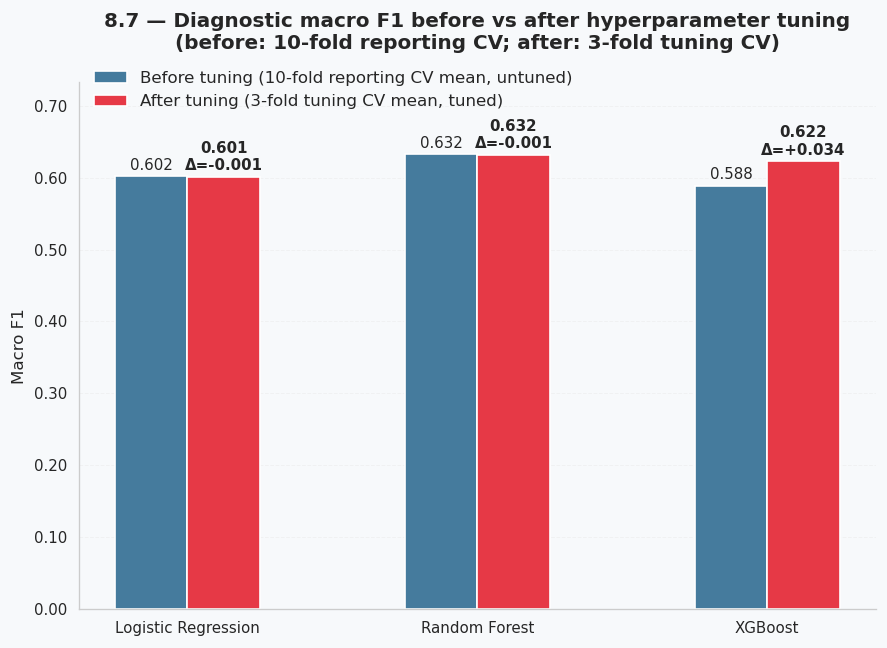

In [66]:
# 8.7 Diagnostic before-vs-after tuning comparison

# "Before" = Section 7 untuned reporting-CV mean macro F1
# "After"= Section 8 best tuning-CV mean macro F1
#
# Note: these use different CV protocols.
# This comparison is diagnostic only and is not used for final conclusions.
# The fair tuned-vs-untuned comparison is performed in Section 9.

model_order = ["Logistic Regression", "Random Forest", "XGBoost"]

before_df = (
    untuned_cv_summary_df[["model", "macro_f1_mean"]]
    .copy()
    .query("model in @model_order")
    .drop_duplicates(subset="model", keep="last")
    .rename(columns={"macro_f1_mean": "Before tuning"})
)

after_df = (
    tuning_results_df[["model", "best_macro_f1"]]
    .copy()
    .query("model in @model_order")
    .drop_duplicates(subset="model", keep="last")
    .rename(columns={"best_macro_f1": "After tuning"})
)
#Comparing both
compare_df = before_df.merge(after_df, on="model", how="inner")

compare_df["model"] = pd.Categorical(
    compare_df["model"],
    categories=model_order,
    ordered=True
)

compare_df = compare_df.sort_values("model").reset_index(drop=True)
compare_df["Change"] = compare_df["After tuning"] - compare_df["Before tuning"]

print(
    "Diagnostic only: before and after scores use different CV protocols. "
    "Use Section 9 for the fair tuned-vs-untuned comparison."
)

display(compare_df.round(4))
#Plotting a bar chart to show the comparison of before vs after
x = np.arange(len(compare_df))
width = 0.25

fig, ax = plt.subplots(figsize=(7.5, 5.5))

bars_before = ax.bar(
    x - width / 2,
    compare_df["Before tuning"],
    width=width,
    color=SLIGHT_COL,
    edgecolor="white",
    linewidth=1,
    label=f"Before tuning ({report_cv.n_splits}-fold reporting CV mean, untuned)"
)

bars_after = ax.bar(
    x + width / 2,
    compare_df["After tuning"],
    width=width,
    color=SEVERE_COL,
    edgecolor="white",
    linewidth=1,
    label=f"After tuning ({N_SPLITS_TUNING}-fold tuning CV mean, tuned)"
)

for bar in bars_before:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.005,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for i, bar in enumerate(bars_after):
    h = bar.get_height()
    delta = compare_df.loc[i, "Change"]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.005,
        f"{h:.3f}\nΔ={delta:+.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(compare_df["model"])
ax.set_ylabel("Macro F1")
ax.set_title(
    "8.7 — Diagnostic macro F1 before vs after hyperparameter tuning\n"
    f"(before: {report_cv.n_splits}-fold reporting CV; "
    f"after: {N_SPLITS_TUNING}-fold tuning CV)",
    fontweight="bold",
    pad=20
)

y_max = max(
    compare_df["After tuning"].max(),
    compare_df["Before tuning"].max()
) + 0.1

ax.set_ylim(0, y_max)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.05))

plt.tight_layout()
plt.show()

XGBoost shows the clearest tuning improvement, increasing from 0.5881 to 0.6224 macro-F1. Logistic Regression changes very little. Random Forest is almost unchanged because the sentinel baseline configuration was retained as the selected RF candidate.

### 8.8 Final selected model hyperparameter values


In [67]:
# 8.8 Final selected model hyperparameter values
#After tuning, allowing the models to use all CPU cores again
if "XGBoost" in tuned_models:
    tuned_models["XGBoost"].set_params(classifier__n_jobs=-1)

if "Random Forest" in tuned_models:
    tuned_models["Random Forest"].set_params(classifier__n_jobs=-1)


important_keys = [
    # Logistic Regression
    "C", "penalty",
    "solver","class_weight",
    "max_iter",

    # Random Forest
    "n_estimators","max_depth",
    "min_samples_leaf","max_features",

    # XGBoost
    "learning_rate", "subsample",
    "colsample_bytree","min_child_weight",
    "scale_pos_weight","eval_metric",
    "tree_method",

    # Common
    "random_state", "n_jobs"
]

# Remove accidental duplicates while preserving order.
important_keys = list(dict.fromkeys(important_keys))

all_best_params = []

for model_name, model in tuned_models.items():
    #Extracting the classifier params from each pipeline
    classifier = model.named_steps["classifier"]
    params = classifier.get_params()

    for key in important_keys:
        if key in params:
            all_best_params.append({
                "model": model_name,
                "hyperparameter": key,
                "value": params[key]
            })

all_best_params_df = pd.DataFrame(all_best_params)

# For FoldBalancedXGBClassifier, scale_pos_weight is recomputed during each fit.
# Replace any stored numeric value with a clear description.
if "XGBoost" in tuned_models:
    mask = (
        (all_best_params_df["model"] == "XGBoost") &
        (all_best_params_df["hyperparameter"] == "scale_pos_weight")
    )

    all_best_params_df.loc[
        mask,
        "value"
    ] = "recomputed per fit from training labels"

print("Final selected model hyperparameter values:")
display(all_best_params_df)

Final selected model hyperparameter values:


,model,hyperparameter,value
0,Logistic Regression,C,0.5
1,Logistic Regression,penalty,l2
2,Logistic Regression,solver,liblinear
3,Logistic Regression,class_weight,balanced
4,Logistic Regression,max_iter,1000
5,Logistic Regression,random_state,42
6,Logistic Regression,n_jobs,None
7,Random Forest,class_weight,balanced
8,Random Forest,n_estimators,100
9,Random Forest,max_depth,None


### 8.9 Section 8 summary

| Model | Search budget | Folds | Total fits | Best macro-F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 6 candidates | 3 | 18 | 0.6013 |
| Random Forest | 15 random + 1 sentinel | 3 | 48 | 0.6316 |
| XGBoost | 15 random candidates | 3 | 45 | 0.6224 |
| **Total** | | | **111** | |

Tuning used 3-fold stratified grouped CV on the training set only.
Macro-F1 was the refit metric. These scores are used only for
selecting configurations, not as the final comparison.

XGBoost showed the clearest directional improvement (0.5881 -> 0.6224),
though the two sides use different CV protocols. Logistic Regression
changed very little, suggesting the untuned linear baseline was already
near-optimal.

For Random Forest, the untuned configuration was evaluated as a
sentinel candidate (n_estimators=100, max_depth=None,
min_samples_leaf=10, max_features=sqrt). The sentinel outperformed
all 15 sampled candidates (0.6316 vs 0.6305), so it was retained as
the RF candidate for Section 9. Constrained tuning did not improve
beyond the regularised RF default.

Section 9 re-evaluates all selected configurations under the same
10-fold reporting CV as Section 7 for a fair comparison.

**Limitations:** 3-fold tuning CV was used for runtime feasibility.
RF and XGBoost searches cover a small fraction of their full
hyperparameter spaces. The Section 8.7 chart is diagnostic only.


## Section 9: Fair Tuned-vs-Untuned Comparison using 10-Fold Grouped CV and Exploratory Wilcoxon Test

This section compares the untuned models from Section 7 with the selected model configurations from Section 8 using the same 10-fold stratified grouped cross-validation protocol.

The purpose is to make the model comparison fair. Section 7 used *report_cv* to evaluate untuned models, while Section 8 used a separate 3-fold tuning CV only to select candidate hyperparameters. Therefore, the Section 8 tuning scores are not used as the final comparison. Instead, the selected pipelines are re-evaluated here using the same *report_cv* folds as Section 7.

The Wilcoxon signed-rank test is included as an exploratory paired comparison of fold-level macro-F1 scores. Because cross-validation folds are not fully independent, the test is interpreted as supporting evidence rather than definitive proof of statistical significance. The 10-fold design provides more paired fold observations than 5-fold CV, but the test remains exploratory.

For final model selection, the best overall macro-F1 model is reported separately from the strongest genuinely tuned ensemble. Because the Random Forest candidate is the unchanged sentinel baseline configuration, XGBoost is selected for Sections 10–11 as the strongest genuinely tuned ensemble.

### 9.1 Imports and setup

In [68]:
# 9.1 Imports and setup

from sklearn.base import clone
from scipy.stats import wilcoxon
import matplotlib.ticker as mticker

# Selected model configurations from Section 8..
models_to_compare = {
    "Logistic Regression": tuned_models["Logistic Regression"],
    "Random Forest": tuned_models["Random Forest"]
}

if XGBOOST_AVAILABLE and "XGBoost" in tuned_models:
    models_to_compare["XGBoost"] = tuned_models["XGBoost"]

assert len(models_to_compare) >= 2, (
    "At least two tuned models are required for Section 9."
)

# Section 7 must have produced these.
assert "untuned_fold_scores_df" in globals(), (
    "untuned_fold_scores_df is missing. Rerun Section 7 first."
)

assert "report_cv" in globals(), (
    "report_cv is missing. Rerun Section 7 first."
)

assert report_cv.n_splits == REPORT_CV_SPLITS, (
    "report_cv.n_splits does not match REPORT_CV_SPLITS."
)

print("Section 9 setup ready.")
print(f"CV protocol: report_cv with {report_cv.n_splits} grouped folds")
print(f"Models to compare: {list(models_to_compare.keys())}")
print(f"Total tuned pipeline fits: {len(models_to_compare) * report_cv.n_splits}")

Section 9 setup ready.
CV protocol: report_cv with 10 grouped folds
Models to compare: ['Logistic Regression', 'Random Forest', 'XGBoost']
Total tuned pipeline fits: 30


### 9.2 Re-evaluate tuned models using the same 10-fold grouped CV

Each tuned model is evaluated across the same ten report_cv folds used in Section 7 for the untuned baselines. This ensures the tuned and untuned scores are directly comparable fold by fold.

For XGBoost, the custom FoldBalancedXGBClassifier recomputes scale_pos_weight inside each .fit() call using only the fold-training labels.

In [69]:
# 9.2 Re-evaluate tuned models using the same grouped CV as Section 7

tuned_fold_rows = []
#Loop through the same 10 grouped CV folds
for fold, (train_idx, val_idx) in enumerate(
    report_cv.split(X_train, y_train, groups=groups_train),
    start=1
):
    #Create Fold level feature sets
    X_fold_train = X_train.iloc[train_idx].copy()
    X_fold_val = X_train.iloc[val_idx].copy()
    
    #Create Fold level target vectors
    y_fold_train = y_train.iloc[train_idx].copy()
    y_fold_val = y_train.iloc[val_idx].copy()

    #Store fold level collision IDs
    groups_fold_train = groups_train.iloc[train_idx].copy()
    groups_fold_val = groups_train.iloc[val_idx].copy()

    # Safety check: no collision appears in both fold-training and fold-validation data.
    overlap = set(groups_fold_train) & set(groups_fold_val)

    assert len(overlap) == 0, (
        f"Collision-level leakage detected in fold {fold}: "
        f"{len(overlap)} overlapping collisions."
    )

    print(f"\nFold {fold}/{report_cv.n_splits}")
    print(f"Training rows: {X_fold_train.shape[0]:,}")
    print(f"Validation rows: {X_fold_val.shape[0]:,}")
    print(f"Training severe rate: {y_fold_train.mean():.3f}")
    print(f"Validation severe rate: {y_fold_val.mean():.3f}")

    for model_name, tuned_pipeline in models_to_compare.items():

        # Clone the tuned pipeline so it is refitted from scratch on this fold.
        fitted_model = clone(tuned_pipeline)
        fitted_model.fit(X_fold_train, y_fold_train)

        fold_results = evaluate_binary_model(
            model_name=model_name,
            fitted_model=fitted_model,
            X_eval=X_fold_val,
            y_eval=y_fold_val
        )

        fold_results["version"] = "tuned"
        fold_results["fold"] = fold

        tuned_fold_rows.append(fold_results)

        print(
            f"{model_name}: "
            f"macro-F1={fold_results['macro_f1']:.4f}, "
            f"severe recall={fold_results['severe_recall']:.4f}, "
            f"severe F1={fold_results['severe_f1']:.4f}"
        )

tuned_fold_scores_df = pd.DataFrame(tuned_fold_rows)

col_order = [
    "model","version",
    "fold","macro_f1",
    "gmean","balanced_accuracy",
    "severe_precision","severe_recall",
    "severe_f1","slight_recall",
    "average_precision","roc_auc"
]

tuned_fold_scores_df = tuned_fold_scores_df[col_order]

print(f"\nTuned {report_cv.n_splits}-fold CV complete.")
print("Fold-level tuned results shape:", tuned_fold_scores_df.shape)

display(tuned_fold_scores_df.round(4))


Fold 1/10
Training rows: 95,668
Validation rows: 10,639
Training severe rate: 0.206
Validation severe rate: 0.213
Logistic Regression: macro-F1=0.6081, severe recall=0.7002, severe F1=0.4669
Random Forest: macro-F1=0.6386, severe recall=0.5988, severe F1=0.4724
XGBoost: macro-F1=0.6228, severe recall=0.6389, severe F1=0.4661

Fold 2/10
Training rows: 95,582
Validation rows: 10,725
Training severe rate: 0.207
Validation severe rate: 0.203
Logistic Regression: macro-F1=0.6052, severe recall=0.7069, severe F1=0.4576
Random Forest: macro-F1=0.6388, severe recall=0.6107, severe F1=0.4684
XGBoost: macro-F1=0.6264, severe recall=0.6484, severe F1=0.4643

Fold 3/10
Training rows: 95,670
Validation rows: 10,637
Training severe rate: 0.207
Validation severe rate: 0.208
Logistic Regression: macro-F1=0.6009, severe recall=0.7003, severe F1=0.4562
Random Forest: macro-F1=0.6329, severe recall=0.6129, severe F1=0.4663
XGBoost: macro-F1=0.6242, severe recall=0.6573, severe F1=0.4677

Fold 4/10
Train

,model,version,fold,macro_f1,gmean,balanced_accuracy,severe_precision,severe_recall,severe_f1,slight_recall,average_precision,roc_auc
0,Logistic Regression,tuned,1,0.6081,0.6736,0.6741,0.3502,0.7002,0.4669,0.6480,0.4364,0.7382
1,Random Forest,tuned,1,0.6386,0.6685,0.6726,0.3901,0.5988,0.4724,0.7464,0.4501,0.7478
2,XGBoost,tuned,1,0.6228,0.6693,0.6701,0.3668,0.6389,0.4661,0.7012,0.4431,0.7409
3,Logistic Regression,tuned,2,0.6052,0.6771,0.6777,0.3383,0.7069,0.4576,0.6486,0.4203,0.7437
4,Random Forest,tuned,2,0.6388,0.6753,0.6787,0.3799,0.6107,0.4684,0.7467,0.4383,0.7554
5,XGBoost,tuned,2,0.6264,0.6781,0.6787,0.3616,0.6484,0.4643,0.7091,0.4311,0.7474
6,Logistic Regression,tuned,3,0.6009,0.6700,0.6706,0.3383,0.7003,0.4562,0.6410,0.4382,0.7428
7,Random Forest,tuned,3,0.6329,0.6706,0.6733,0.3762,0.6129,0.4663,0.7336,0.4420,0.7464
8,XGBoost,tuned,3,0.6242,0.6772,0.6775,0.3630,0.6573,0.4677,0.6977,0.4439,0.7445
9,Logistic Regression,tuned,4,0.6022,0.6757,0.6768,0.3375,0.7155,0.4586,0.6381,0.4283,0.7464


### 9.3 Combine untuned and tuned fold-level scores

The untuned fold-level scores from Section 7 and the tuned fold-level scores from this section are combined into one table. This allows direct comparison of each model before and after tuning under the same grouped folds.

The dummy baseline remains useful as a no-skill reference in Section 7, but it is not included in the tuned-vs-untuned comparison because it is not tuned.

In [70]:
# 9.3 Combine untuned and tuned fold-level scores

comparison_fold_scores_df = pd.concat(
    [untuned_fold_scores_df, tuned_fold_scores_df],
    ignore_index=True
)

# Keep only real models for tuned-vs-untuned comparison.
comparison_fold_scores_df = comparison_fold_scores_df[
    comparison_fold_scores_df["model"] != "Dummy baseline"
].copy()

print("Combined tuned-vs-untuned fold-level table:")
print(comparison_fold_scores_df.shape)

display(
    comparison_fold_scores_df
    .sort_values(["model", "version", "fold"])
    .round(4)
)

Combined tuned-vs-untuned fold-level table:
(60, 12)


,model,version,fold,macro_f1,gmean,balanced_accuracy,severe_precision,severe_recall,severe_f1,slight_recall,average_precision,roc_auc
40,Logistic Regression,tuned,1,0.6081,0.6736,0.6741,0.3502,0.7002,0.4669,0.6480,0.4364,0.7382
43,Logistic Regression,tuned,2,0.6052,0.6771,0.6777,0.3383,0.7069,0.4576,0.6486,0.4203,0.7437
46,Logistic Regression,tuned,3,0.6009,0.6700,0.6706,0.3383,0.7003,0.4562,0.6410,0.4382,0.7428
49,Logistic Regression,tuned,4,0.6022,0.6757,0.6768,0.3375,0.7155,0.4586,0.6381,0.4283,0.7464
52,Logistic Regression,tuned,5,0.6028,0.6730,0.6736,0.3382,0.7022,0.4565,0.6450,0.4394,0.7420
55,Logistic Regression,tuned,6,0.5997,0.6688,0.6693,0.3358,0.6963,0.4531,0.6424,0.4229,0.7395
58,Logistic Regression,tuned,7,0.6000,0.6689,0.6697,0.3392,0.7024,0.4575,0.6370,0.4241,0.7309
61,Logistic Regression,tuned,8,0.6055,0.6755,0.6762,0.3426,0.7076,0.4617,0.6448,0.4325,0.7460
64,Logistic Regression,tuned,9,0.6003,0.6709,0.6717,0.3364,0.7035,0.4551,0.6398,0.4220,0.7339
67,Logistic Regression,tuned,10,0.5943,0.6630,0.6636,0.3306,0.6909,0.4472,0.6363,0.4252,0.7296


### 9.4 Tuned-vs-untuned summary

The table below reports mean and standard deviation across the ten grouped folds for each model and version. The main comparison is macro F1, but severe precision, severe recall, severe F1, G-Mean, average precision, and ROC-AUC are also shown to understand the trade-off between class-balanced performance and severe-class detection.

In [71]:
# 9.4 Tuned-vs-untuned summary

section9_metric_cols = [
    "macro_f1", "gmean",
    "balanced_accuracy","severe_precision",
    "severe_recall","severe_f1",
    "slight_recall","average_precision",
    "roc_auc"
]
#Group by model and version, tuned or untuned and caluclate mean and std dev
#for each metric
section9_summary = (
    comparison_fold_scores_df
    .groupby(["model", "version"])[section9_metric_cols]
    .agg(["mean", "std"])
)

section9_summary.columns = [
    f"{metric}_{stat}"
    for metric, stat in section9_summary.columns
]

section9_summary = (
    section9_summary
    .reset_index()
    .sort_values(["macro_f1_mean", "model"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Section 9 tuned-vs-untuned summary:")
display(section9_summary.round(4))

Section 9 tuned-vs-untuned summary:


,model,version,macro_f1_mean,macro_f1_std,gmean_mean,gmean_std,balanced_accuracy_mean,balanced_accuracy_std,severe_precision_mean,severe_precision_std,severe_recall_mean,severe_recall_std,severe_f1_mean,severe_f1_std,slight_recall_mean,slight_recall_std,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std
0,Random Forest,tuned,0.6323,0.0058,0.6689,0.0070,0.6720,0.0066,0.3752,0.0076,0.6082,0.0110,0.4641,0.0074,0.7357,0.0066,0.4391,0.0068,0.7470,0.0066
1,Random Forest,untuned,0.6323,0.0058,0.6689,0.0070,0.6720,0.0066,0.3752,0.0076,0.6082,0.0110,0.4641,0.0074,0.7357,0.0066,0.4391,0.0068,0.7470,0.0066
2,XGBoost,tuned,0.6227,0.0046,0.6742,0.0060,0.6747,0.0059,0.3609,0.0052,0.6494,0.0095,0.4640,0.0059,0.7000,0.0054,0.4370,0.0057,0.7434,0.0060
3,Logistic Regression,untuned,0.6019,0.0038,0.6716,0.0041,0.6723,0.0041,0.3387,0.0050,0.7025,0.0065,0.4570,0.0050,0.6422,0.0046,0.4289,0.0071,0.7393,0.0060
4,Logistic Regression,tuned,0.6019,0.0039,0.6716,0.0042,0.6723,0.0043,0.3387,0.0050,0.7026,0.0066,0.4570,0.0051,0.6421,0.0044,0.4289,0.0071,0.7393,0.0061
5,XGBoost,untuned,0.5881,0.0049,0.6664,0.0055,0.6693,0.0056,0.3271,0.0054,0.7308,0.0095,0.4519,0.0057,0.6078,0.0064,0.4274,0.0064,0.7383,0.0052


### 9.5 Mean metric comparison table

For readability, the table below shows only the mean value of each metric across the ten folds. Models are sorted by mean macro F1.

In [72]:
# 9.5 Mean metric comparison table

mean_cols = [f"{metric}_mean" for metric in section9_metric_cols]

section9_mean_display = section9_summary[
    ["model", "version"] + mean_cols
].copy()

section9_mean_display.columns = ["model", "version"] + section9_metric_cols

section9_mean_display = (
    section9_mean_display
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(section9_mean_display.round(4))

,model,version,macro_f1,gmean,balanced_accuracy,severe_precision,severe_recall,severe_f1,slight_recall,average_precision,roc_auc
0,Random Forest,tuned,0.6323,0.6689,0.6720,0.3752,0.6082,0.4641,0.7357,0.4391,0.7470
1,Random Forest,untuned,0.6323,0.6689,0.6720,0.3752,0.6082,0.4641,0.7357,0.4391,0.7470
2,XGBoost,tuned,0.6227,0.6742,0.6747,0.3609,0.6494,0.4640,0.7000,0.4370,0.7434
3,Logistic Regression,untuned,0.6019,0.6716,0.6723,0.3387,0.7025,0.4570,0.6422,0.4289,0.7393
4,Logistic Regression,tuned,0.6019,0.6716,0.6723,0.3387,0.7026,0.4570,0.6421,0.4289,0.7393
5,XGBoost,untuned,0.5881,0.6664,0.6693,0.3271,0.7308,0.4519,0.6078,0.4274,0.7383


### 9.6 Macro F1 before and after tuning under 10-fold grouped CV

This plot compares mean macro F1 for each model before and after tuning. Error bars show one standard deviation across the ten grouped folds.

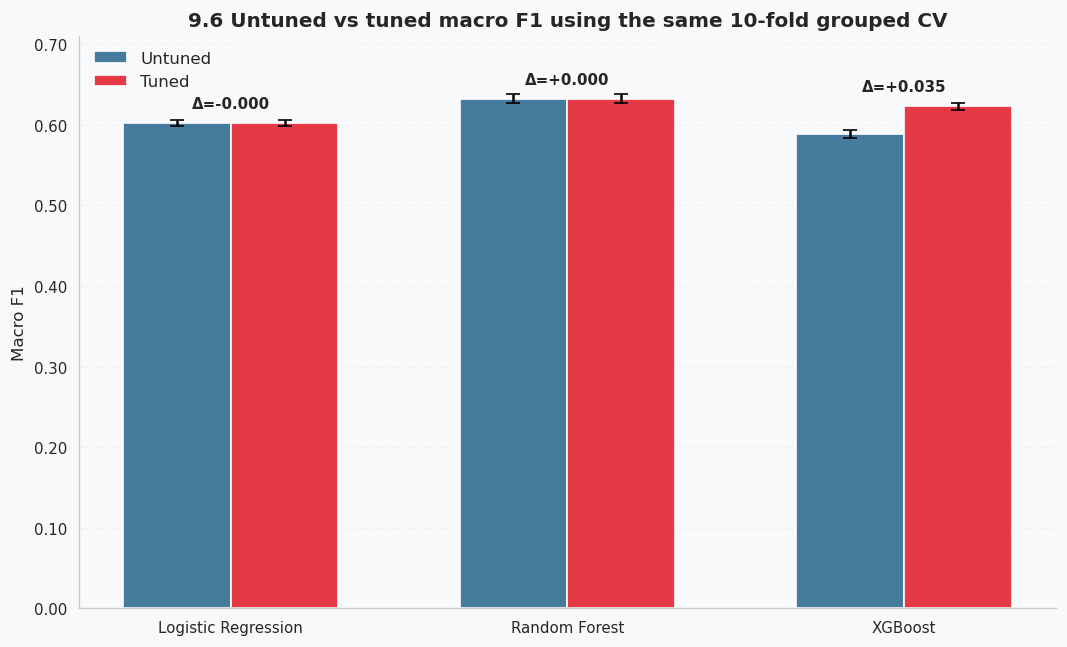

In [73]:
# 9.6 Plot macro F1 before and after tuning

plot_df = section9_summary[
    ["model", "version", "macro_f1_mean", "macro_f1_std"]
].copy()

plot_df["version"] = pd.Categorical(
    plot_df["version"],
    categories=["untuned", "tuned"],
    ordered=True
)

plot_df = plot_df.sort_values(["model", "version"]).reset_index(drop=True)

model_order = ["Logistic Regression", "Random Forest", "XGBoost"]

plot_df["model"] = pd.Categorical(
    plot_df["model"],
    categories=model_order,
    ordered=True
)
#reshapes the results so each model has two bars:untuned and tuned
pivot_mean = plot_df.pivot(
    index="model",
    columns="version",
    values="macro_f1_mean"
).reindex(model_order)

pivot_std = plot_df.pivot(
    index="model",
    columns="version",
    values="macro_f1_std"
).reindex(model_order)

x = np.arange(len(pivot_mean.index))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5.5))

bars_untuned = ax.bar(
    x - width / 2,
    pivot_mean["untuned"],
    width=width,
    yerr=pivot_std["untuned"], #The error bars show one standard deviation across the 10 folds.
    color=SLIGHT_COL,
    edgecolor="white",
    linewidth=1,
    capsize=4,
    label="Untuned"
)

bars_tuned = ax.bar(
    x + width / 2,
    pivot_mean["tuned"],
    width=width,
    yerr=pivot_std["tuned"],
    color=SEVERE_COL,
    edgecolor="white",
    linewidth=1,
    capsize=4,
    label="Tuned"
)

for i, model_name in enumerate(pivot_mean.index):
    untuned_val = pivot_mean.loc[model_name, "untuned"]
    tuned_val = pivot_mean.loc[model_name, "tuned"]
    change = tuned_val - untuned_val

    ax.text(
        x[i],
        max(untuned_val, tuned_val) + 0.015,
        f"Δ={change:+.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(pivot_mean.index)
ax.set_ylabel("Macro F1")
ax.set_title(
    f"9.6 Untuned vs tuned macro F1 using the same {report_cv.n_splits}-fold grouped CV",
    fontweight="bold"
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)

y_max = max(pivot_mean.max().max(), 0.65) + 0.06
ax.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

### 9.7 Exploratory Wilcoxon signed-rank tests

The Wilcoxon signed-rank test is used as an exploratory paired comparison of fold-level macro-F1 scores.

Three types of comparisons are reported:

1. Selected vs untuned for each model: to check whether the selected Section 8 configuration improved over the untuned model under the same ten folds.

2. Best selected model vs other selected models: to compare the strongest selected configuration against alternatives.

3. XGBoost vs Logistic Regression: to directly test the research question of whether the strongest genuinely tuned ensemble improves over the regularised linear baseline.

Because cross-validation folds are not fully independent, the p-values are interpreted cautiously. The 10-fold design provides more paired fold scores than 5-fold CV, but the tests are still treated as exploratory supporting evidence rather than definitive proof of statistical significance.

References:

- Wilcoxon, F. (1945). Individual comparisons by ranking methods. Biometrics Bulletin, 1(6), 80–83.
- Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. Journal of Machine Learning Research, 7, 1–30.
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. Neural Computation, 10(7), 1895–1923.
- Nadeau, C. & Bengio, Y. (2003). Inference for the generalization error. Machine Learning, 52, 239–281.

In [74]:
# 9.7 Exploratory Wilcoxon signed-rank tests

wilcoxon_rows = []

# A. Selected vs untuned within each model
# For each model, compare the tuned version against the untuned version using
# paired macro-F1 scores from the same cross-validation folds.
for model_name in model_order:
    if model_name not in comparison_fold_scores_df["model"].unique():
        continue

    #This creates paired tuned and untuned macro-F1 values for each fold.
    # Create a fold-by-version table.
    # Each row represents one fold, and the columns contain the untuned and
    # tuned macro-F1 scores for the same model.
    paired_model_scores = (
        comparison_fold_scores_df
        .loc[comparison_fold_scores_df["model"] == model_name]
        .pivot_table(
            index="fold",
            columns="version",
            values="macro_f1"
        )
        .dropna()
        .sort_index()
    )

    if {"untuned", "tuned"}.issubset(paired_model_scores.columns):
        #This calculates fold-level differences.
        diff = paired_model_scores["tuned"] - paired_model_scores["untuned"]

        if np.allclose(diff, 0):
            stat, p_value = 0.0, 1.0
            note = "No difference: paired fold scores are identical."
        else:
            try:
                stat, p_value = wilcoxon(
                    paired_model_scores["tuned"],
                    paired_model_scores["untuned"],
                    alternative="two-sided",
                    zero_method="wilcox"
                )
                note = ""
            except ValueError as e:
                stat, p_value = np.nan, np.nan
                note = f"Wilcoxon failed: {e}"
                print(f"Wilcoxon failed for {model_name}: {e}")

        wilcoxon_rows.append({
            "comparison_type": "selected vs untuned",
            "comparison": f"{model_name}: selected vs untuned",
            "metric": "macro_f1",
            "mean_diff": float(diff.mean()),
            "median_diff": float(diff.median()),
            "n_pairs": len(diff),
            "wilcoxon_stat": stat,
            "p_value": p_value,
            "note": note
        })


# B. Best overall selected model vs other selected models
# Identify the best tuned model based on mean macro-F1, then compare its
# fold-level tuned scores against the tuned scores of every other model.
selected_summary = (
    section9_summary
    .loc[section9_summary["version"] == "tuned"]
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

best_selected_model_name = selected_summary.loc[0, "model"]

# Create a fold-by-model table containing tuned macro-F1 scores.
# Each row represents one fold, and each column represents one tuned model.
selected_paired_scores = (
    tuned_fold_scores_df
    .pivot_table(
        index="fold",
        columns="model",
        values="macro_f1"
    )
    .dropna()
    .sort_index()
)

for other_model in selected_paired_scores.columns:
    if other_model == best_selected_model_name:
        continue

    diff = selected_paired_scores[best_selected_model_name] - selected_paired_scores[other_model]

    if np.allclose(diff, 0):
        stat, p_value = 0.0, 1.0
        note = "No difference: paired fold scores are identical."
    else:
        try:
            stat, p_value = wilcoxon(
                selected_paired_scores[best_selected_model_name],
                selected_paired_scores[other_model],
                alternative="two-sided",
                zero_method="wilcox"
            )
            note = ""
        except ValueError as e:
            stat, p_value = np.nan, np.nan
            note = f"Wilcoxon failed: {e}"
            print(f"Wilcoxon failed for {best_selected_model_name} vs {other_model}: {e}")

    wilcoxon_rows.append({
        "comparison_type": "selected model comparison",
        "comparison": f"{best_selected_model_name} vs {other_model}",
        "metric": "macro_f1",
        "mean_diff": float(diff.mean()),
        "median_diff": float(diff.median()),
        "n_pairs": len(diff),
        "wilcoxon_stat": stat,
        "p_value": p_value,
        "note": note
    })


# C. Research-question comparison:
# strongest genuinely tuned ensemble vs regularised linear baseline
# Compare the strongest genuinely tuned ensemble model against the
# regularised linear baseline.
 #
# In this analysis, XGBoost represents the tuned ensemble model and
# Logistic Regression represents the regularised linear baseline.
if {"XGBoost", "Logistic Regression"}.issubset(selected_paired_scores.columns):
    diff = selected_paired_scores["XGBoost"] - selected_paired_scores["Logistic Regression"]

    if np.allclose(diff, 0):
        stat, p_value = 0.0, 1.0
        note = "No difference: paired fold scores are identical."
    else:
        try:
            stat, p_value = wilcoxon(
                selected_paired_scores["XGBoost"],
                selected_paired_scores["Logistic Regression"],
                alternative="two-sided",
                zero_method="wilcox"
            )
            note = ""
        except ValueError as e:
            stat, p_value = np.nan, np.nan
            note = f"Wilcoxon failed: {e}"
            print(f"Wilcoxon failed for XGBoost vs Logistic Regression: {e}")

    wilcoxon_rows.append({
        "comparison_type": "research question comparison",
        "comparison": "XGBoost vs Logistic Regression",
        "metric": "macro_f1",
        "mean_diff": float(diff.mean()),
        "median_diff": float(diff.median()),
        "n_pairs": len(diff),
        "wilcoxon_stat": stat,
        "p_value": p_value,
        "note": note
    })


wilcoxon_results_df = pd.DataFrame(wilcoxon_rows)

print("Exploratory Wilcoxon signed-rank tests:")
display(wilcoxon_results_df.round(4))

print(
    "\nWilcoxon note: These tests are exploratory because cross-validation folds "
    "are not fully independent. With 10 paired folds, the test has more power "
    "than with 5 folds, but p-values are still interpreted as supporting "
    "evidence rather than definitive proof of significance."
)

Exploratory Wilcoxon signed-rank tests:


,comparison_type,comparison,metric,mean_diff,median_diff,n_pairs,wilcoxon_stat,p_value,note
0,selected vs untuned,Logistic Regression: selected vs untuned,macro_f1,-0.0000,-0.0001,10,21.0,0.5566,
1,selected vs untuned,Random Forest: selected vs untuned,macro_f1,0.0000,0.0000,10,0.0,1.0000,No difference: paired fold scores are identical.
2,selected vs untuned,XGBoost: selected vs untuned,macro_f1,0.0346,0.0340,10,0.0,0.0020,
3,selected model comparison,Random Forest vs Logistic Regression,macro_f1,0.0304,0.0312,10,0.0,0.0020,
4,selected model comparison,Random Forest vs XGBoost,macro_f1,0.0096,0.0090,10,0.0,0.0020,
5,research question comparison,XGBoost vs Logistic Regression,macro_f1,0.0208,0.0211,10,0.0,0.0020,



Wilcoxon note: These tests are exploratory because cross-validation folds are not fully independent. With 10 paired folds, the test has more power than with 5 folds, but p-values are still interpreted as supporting evidence rather than definitive proof of significance.


### 9.8 Provisional final model selection

This section reports two model-selection outcomes.

First, the best overall macro-F1 model across the selected configurations is reported. This identifies the model with the highest mean macro-F1 under the fair 10-fold grouped CV comparison.

Second, the final model carried forward to Section 10 and Section 11 is selected as the strongest genuinely tuned ensemble. This distinction is necessary because the Random Forest candidate is the unchanged sentinel baseline configuration: RF tuning did not improve over the original regularised RF baseline. Therefore, Random Forest is reported as the best overall macro-F1 configuration, while XGBoost is selected as the strongest genuinely tuned ensemble.


In [75]:
# Selection rule:
# - Report the best overall macro-F1 configuration.
# - Carry forward the strongest genuinely tuned ensemble.
# - Exclude Random Forest from the genuinely tuned set because Section 8 retained
#   the unchanged RF sentinel baseline configuration.

selected_only_summary = (
    section9_summary
    .loc[section9_summary["version"] == "tuned"]
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

overall_best_row = (
    section9_summary
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
    .loc[0]
)

genuinely_tuned_summary = (
    section9_summary
    .loc[
        (section9_summary["version"] == "tuned") &
        (section9_summary["model"] != "Random Forest")
    ]
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

final_model_name = genuinely_tuned_summary.loc[0, "model"]
final_model = tuned_models[final_model_name]

final_macro_f1 = genuinely_tuned_summary.loc[0, "macro_f1_mean"]
final_gmean = genuinely_tuned_summary.loc[0, "gmean_mean"]
final_severe_recall = genuinely_tuned_summary.loc[0, "severe_recall_mean"]
final_severe_f1 = genuinely_tuned_summary.loc[0, "severe_f1_mean"]

print(f"Best overall macro-F1 configuration: {overall_best_row['model']} ({overall_best_row['version']})")
print(f"Best overall macro-F1: {overall_best_row['macro_f1_mean']:.4f}")
print(f"Best overall G-Mean: {overall_best_row['gmean_mean']:.4f}")
print(f"Best overall severe recall: {overall_best_row['severe_recall_mean']:.4f}")

print(f"\nFinal model selected for Sections 10–11: {final_model_name}")
print("Selection rule: strongest genuinely tuned ensemble.")
print(f"Mean selected CV macro-F1: {final_macro_f1:.4f}")
print(f"Mean selected CV G-Mean: {final_gmean:.4f}")
print(f"Mean selected CV severe recall: {final_severe_recall:.4f}")
print(f"Mean selected CV severe F1: {final_severe_f1:.4f}")

print("\nWilcoxon interpretation:")
alpha = 0.05

for _, row in wilcoxon_results_df.iterrows():
    p_value = row["p_value"]

    if pd.isna(p_value):
        print(f"  {row['comparison']}: test could not be computed.")
    elif p_value < alpha:
        print(
            f"  {row['comparison']}: p={p_value:.4f}. "
            "Exploratory evidence of a consistent fold-level difference, "
            "but not definitive because CV folds are not fully independent."
        )
    else:
        print(
            f"  {row['comparison']}: p={p_value:.4f}. "
            "No strong exploratory evidence of a consistent fold-level difference."
        )

print(f"\nModel selected for Section 10 threshold tuning: {final_model_name}")
print("The held-out test set remains unused.")

Best overall macro-F1 configuration: Random Forest (tuned)
Best overall macro-F1: 0.6323
Best overall G-Mean: 0.6689
Best overall severe recall: 0.6082

Final model selected for Sections 10–11: XGBoost
Selection rule: strongest genuinely tuned ensemble.
Mean selected CV macro-F1: 0.6227
Mean selected CV G-Mean: 0.6742
Mean selected CV severe recall: 0.6494
Mean selected CV severe F1: 0.4640

Wilcoxon interpretation:
  Logistic Regression: selected vs untuned: p=0.5566. No strong exploratory evidence of a consistent fold-level difference.
  Random Forest: selected vs untuned: p=1.0000. No strong exploratory evidence of a consistent fold-level difference.
  XGBoost: selected vs untuned: p=0.0020. Exploratory evidence of a consistent fold-level difference, but not definitive because CV folds are not fully independent.
  Random Forest vs Logistic Regression: p=0.0020. Exploratory evidence of a consistent fold-level difference, but not definitive because CV folds are not fully independent.


## Section 10: Threshold Analysis for the Selected Model

This section analyses whether changing the default classification threshold
improves the selected model. Threshold tuning is performed using a grouped
validation split created from X_train only.

The primary threshold objective is macro F1. However, because this is a
road-safety application, the final threshold must not substantially reduce
Severe-class recall compared with the default threshold of 0.50. Therefore,
two thresholds are reported:

- the threshold that maximises validation macro F1;
- the safety-aware threshold that maximises macro F1 while preserving
  default-threshold Severe recall.

The selected threshold is carried forward to the final held-out test evaluation.

In [76]:
# 10.1 Setup, grouped threshold split, and validation scores
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score
)

import matplotlib.ticker as mticker

assert "final_model_name" in globals(), "final_model_name missing. Rerun Section 9."
assert "final_model" in globals(), "final_model missing. Rerun Section 9."

print(f"Selected model for threshold analysis: {final_model_name}")

assert final_model_name == "XGBoost", (
    "Section 10 is expected to run on XGBoost. "
    "Rerun Section 9.8 if a different model was selected."
)
# Grouped validation split from X_train only.
threshold_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

threshold_train_idx, threshold_val_idx = next(
    threshold_splitter.split(X_train, y_train, groups=groups_train)
)

X_threshold_train = X_train.iloc[threshold_train_idx].copy()
X_threshold_val   = X_train.iloc[threshold_val_idx].copy()

y_threshold_train = y_train.iloc[threshold_train_idx].copy()
y_threshold_val   = y_train.iloc[threshold_val_idx].copy()

groups_threshold_train = groups_train.iloc[threshold_train_idx].copy()
groups_threshold_val   = groups_train.iloc[threshold_val_idx].copy()

overlap = set(groups_threshold_train) & set(groups_threshold_val)
assert len(overlap) == 0, "Collision leakage in threshold-validation split."

print("Threshold-training shape:", X_threshold_train.shape)
print("Threshold-validation shape:", X_threshold_val.shape)
print("Training severe rate:", round(y_threshold_train.mean(), 4))
print("Validation severe rate:", round(y_threshold_val.mean(), 4))

# Clone tuned model so it is fitted only on the threshold-training split.
threshold_model = clone(final_model)
threshold_model.fit(X_threshold_train, y_threshold_train)

y_threshold_score = threshold_model.predict_proba(X_threshold_val)[:, 1]

print("\nValidation probability summary:")
print("Min :", round(y_threshold_score.min(), 4))
print("Mean:", round(y_threshold_score.mean(), 4))
print("Max :", round(y_threshold_score.max(), 4))

Selected model for threshold analysis: XGBoost
Threshold-training shape: (84999, 42)
Threshold-validation shape: (21308, 42)
Training severe rate: 0.2059
Validation severe rate: 0.2109

Validation probability summary:
Min : 0.0004
Mean: 0.4089
Max : 0.9811


### 10.2 Search candidate thresholds

Thresholds from 0.05 to 0.95 are evaluated in steps of 0.01. For each
threshold, validation probabilities are converted into class predictions.

In [77]:
# 10.2 Threshold search

def threshold_metric_row(label, threshold, y_true, y_score):
    y_pred = (y_score >= threshold).astype(int) #converting probabilites into class

    recall_severe = recall_score(
        y_true, y_pred, pos_label=1, zero_division=0
    )
    recall_slight = recall_score(
        y_true, y_pred, pos_label=0, zero_division=0
    )

    return {
        "setting": label,
        "threshold": threshold,
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "gmean": float(np.sqrt(recall_severe * recall_slight)),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "severe_precision": precision_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),
        "severe_recall": recall_severe,
        "severe_f1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "slight_recall": recall_slight,
        "predicted_severe_rate": y_pred.mean()
    }


thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)

threshold_results_df = pd.DataFrame([
    threshold_metric_row(
        label="candidate",
        threshold=t,
        y_true=y_threshold_val,
        y_score=y_threshold_score
    )
    for t in thresholds
]).drop(columns="setting")

# Default threshold performance.
default_row = threshold_metric_row(
    label="Default threshold",
    threshold=0.50,  #Default Threshold
    y_true=y_threshold_val,
    y_score=y_threshold_score
)

default_severe_recall = default_row["severe_recall"]

# Pure macro-F1 optimum.
pure_best_row = (
    threshold_results_df
    .sort_values(
        ["macro_f1", "severe_recall", "threshold"],
        ascending=[False, False, True]
    )
    .iloc[0]
)

pure_best_threshold = float(pure_best_row["threshold"])

# Safety-aware threshold:
# maximise macro-F1 while preserving default severe recall.
safety_candidates = threshold_results_df[
    threshold_results_df["severe_recall"] >= default_severe_recall
].copy()

safety_best_row = (
    safety_candidates
    .sort_values(
        ["macro_f1", "severe_recall", "threshold"],
        ascending=[False, False, True]
    )
    .iloc[0]
)

optimal_threshold = float(safety_best_row["threshold"])

threshold_comparison_df = pd.DataFrame([
    default_row,
    {
        "setting": "Pure macro-F1 threshold",
        **pure_best_row.to_dict()
    },
    {
        "setting": "Safety-aware selected threshold",
        **safety_best_row.to_dict()
    }
])

display(threshold_comparison_df.round(4))

print(f"Pure macro-F1 threshold: {pure_best_threshold:.2f}")
print(f"Safety-aware selected threshold: {optimal_threshold:.2f}")

,setting,threshold,macro_f1,gmean,balanced_accuracy,severe_precision,severe_recall,severe_f1,slight_recall,predicted_severe_rate
0,Default threshold,0.5,0.6209,0.6648,0.6661,0.3631,0.6252,0.4594,0.7069,0.3631
1,Pure macro-F1 threshold,0.6,0.6411,0.6215,0.6472,0.4198,0.4667,0.4420,0.8277,0.2344
2,Safety-aware selected threshold,0.5,0.6209,0.6648,0.6661,0.3631,0.6252,0.4594,0.7069,0.3631


Pure macro-F1 threshold: 0.60
Safety-aware selected threshold: 0.50


### 10.3 Threshold trade-off plot

The plot shows how macro F1, G-Mean, severe recall, severe precision, and
slight recall change as the threshold changes. The selected threshold is
marked with a vertical dashed line.

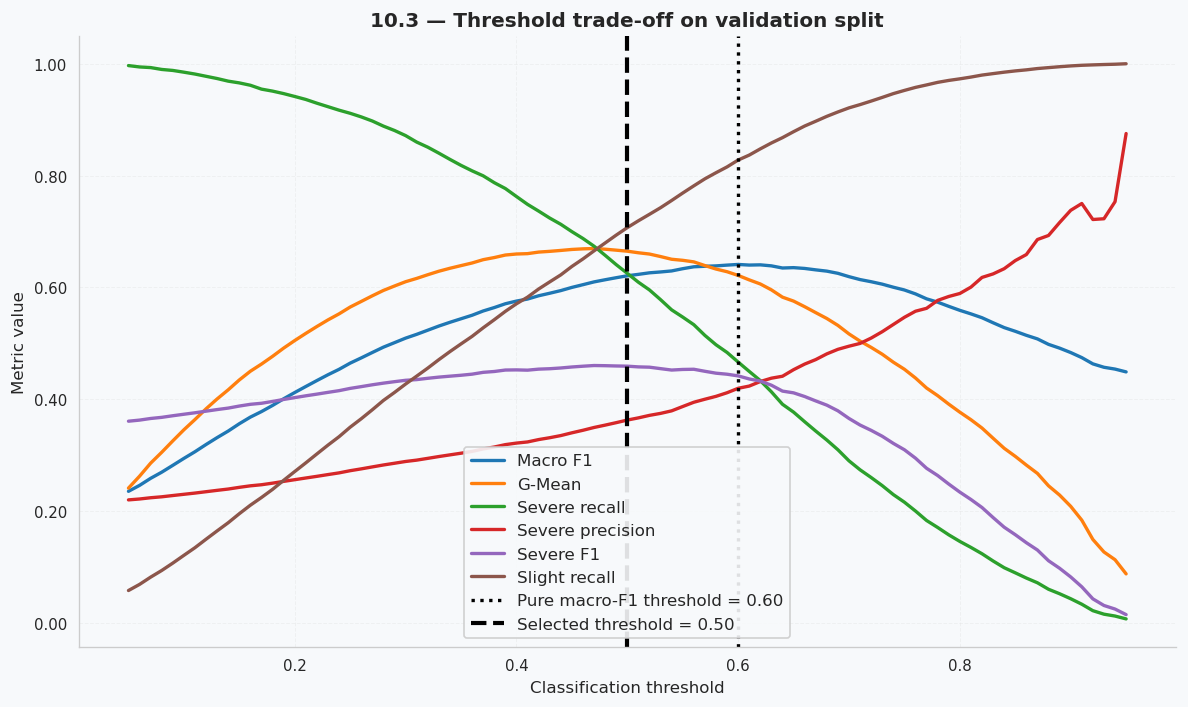

In [78]:
# 10.3 Threshold trade-off plot

fig, ax = plt.subplots(figsize=(10, 6))

plot_metrics = {
    "macro_f1": "Macro F1",
    "gmean": "G-Mean",
    "severe_recall": "Severe recall",
    "severe_precision": "Severe precision",
    "severe_f1": "Severe F1",
    "slight_recall": "Slight recall"
}

for col, label in plot_metrics.items():
    ax.plot(
        threshold_results_df["threshold"],
        threshold_results_df[col],
        linewidth=2,
        label=label
    )

ax.axvline(
    pure_best_threshold,
    linestyle=":",
    linewidth=2,
    color="black",
    label=f"Pure macro-F1 threshold = {pure_best_threshold:.2f}"
)

ax.axvline(
    optimal_threshold,
    linestyle="--",
    linewidth=2.5,
    color="black",
    label=f"Selected threshold = {optimal_threshold:.2f}"
)

ax.set_xlabel("Classification threshold")
ax.set_ylabel("Metric value")
ax.set_title(
    "10.3 — Threshold trade-off on validation split",
    fontweight="bold"
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax.grid(axis="both", linestyle="--", alpha=0.35)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

### 10.4 Final threshold decision

The pure macro-F1 threshold may improve validation macro-F1 by increasing precision and slight-class recall, but it can reduce Severe-class recall. Because this project concerns road casualty severity, missing more Severe casualties is not desirable.

Therefore, a safety-aware threshold rule was applied: maximise macro-F1 subject to Severe recall not falling below the default-threshold Severe recall. The selected threshold is stored as ***selected_threshold*** and carried forward to the final held-out test evaluation.

In Section 11, the final selected XGBoost pipeline should be refitted on the full X_trai, and this stored threshold should then be applied to X_test probabilities. The held-out test set must not be used to choose or adjust the threshold.

***References:***

- Pedregosa et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.
- Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to ROC, informedness, markedness and correlation. Journal of Machine Learning Technologies, 2(1), 37–63.

In [79]:
# 10.4 Store final threshold for Section 11

selected_threshold = optimal_threshold

print(f"Final selected model     : {final_model_name}")
print(f"Final selected threshold : {selected_threshold:.2f}")

final_threshold_summary = threshold_comparison_df.round(4)
display(final_threshold_summary)

Final selected model     : XGBoost
Final selected threshold : 0.50


,setting,threshold,macro_f1,gmean,balanced_accuracy,severe_precision,severe_recall,severe_f1,slight_recall,predicted_severe_rate
0,Default threshold,0.5,0.6209,0.6648,0.6661,0.3631,0.6252,0.4594,0.7069,0.3631
1,Pure macro-F1 threshold,0.6,0.6411,0.6215,0.6472,0.4198,0.4667,0.4420,0.8277,0.2344
2,Safety-aware selected threshold,0.5,0.6209,0.6648,0.6661,0.3631,0.6252,0.4594,0.7069,0.3631


## Section 11: Final Held-Out Test Evaluation

This section evaluates the final selected model on the held-out test set.

The final model, XGBoost, was selected in Section 9 as the strongest genuinely tuned ensemble under the fair 10-fold grouped CV comparison. The classification threshold was selected in Section 10 using a grouped validation split created from the training data only.

The held-out test set has not been used during preprocessing, feature selection, hyperparameter tuning, model comparison, or threshold selection. It is used once here to estimate final generalisation performance.

No further tuning, threshold adjustment, or model selection is performed after this point. The final XGBoost pipeline is refitted on the full training set, and the selected threshold from Section 10 is applied to the held-out test-set probabilities.

In [80]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd

# Colour fallbacks in case earlier plotting colours are not available.
SEVERE_COL = globals().get("SEVERE_COL", "#E63946")
SLIGHT_COL = globals().get("SLIGHT_COL", "#457B9D")

# Section 9 should have selected the final model.
# Section 10 should have selected the final threshold.
# The held-out test set must not be used if either step is missing.

assert "final_model_name" in globals(), (
    "final_model_name missing. Rerun Section 9.8 first."
)

assert "final_model" in globals(), (
    "final_model missing. Rerun Section 9.8 first."
)

assert final_model_name == "XGBoost", (
    "Section 11 should evaluate XGBoost as the final selected model. "
    "Rerun Section 9.8 if a different model was selected."
)

assert "selected_threshold" in globals(), (
    "selected_threshold missing. Rerun Section 10 before final test evaluation."
)

print(f"Final selected model    : {final_model_name}")
print(f"Final selected threshold: {selected_threshold:.2f}")


def evaluate_fitted_model_at_threshold(
    model_name,
    fitted_model,
    X_eval,
    y_eval,
    threshold=0.50
):

    # Get probability scores for the Severe class.
    # XGBoost supports predict_proba, so this should be the normal path.
    if hasattr(fitted_model, "predict_proba"):
        y_score = fitted_model.predict_proba(X_eval)[:, 1]
    elif hasattr(fitted_model, "decision_function"):
        y_score = fitted_model.decision_function(X_eval)
    else:
        raise AttributeError(
            "The fitted model must provide predict_proba or decision_function."
        )

    # Apply the pre-selected threshold to convert scores into class predictions.
    y_pred = (y_score >= threshold).astype(int)

    # Per-class recalls are used directly and also used to compute G-Mean.
    recall_severe = recall_score(
        y_eval,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall_slight = recall_score(
        y_eval,
        y_pred,
        pos_label=0,
        zero_division=0
    )

    results = {
        "model": model_name,
        "threshold": threshold,

        # Overall and class-balanced metrics.
        "accuracy": accuracy_score(y_eval, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "macro_f1": f1_score(
            y_eval,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "gmean": float(np.sqrt(recall_severe * recall_slight)),

        # Severe-class metrics.
        "severe_precision": precision_score(
            y_eval,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "severe_recall": recall_severe,
        "severe_f1": f1_score(
            y_eval,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        # Slight-class recall shows the other side of the trade-off.
        "slight_recall": recall_slight,

        # Prediction-rate diagnostics.
        "predicted_severe_rate": y_pred.mean(),
        "actual_severe_rate": y_eval.mean(),

        # Ranking metrics are threshold-independent.
        "average_precision": average_precision_score(y_eval, y_score),
        "roc_auc": roc_auc_score(y_eval, y_score),
    }

    return results, y_pred, y_score


print("Section 11 evaluation helper defined.")

Final selected model    : XGBoost
Final selected threshold: 0.50
Section 11 evaluation helper defined.


### 11.2 Fit final model on full training data and evaluate on the held-out test set

The final XGBoost pipeline is cloned and refitted on the full X_train. This allows the final model to use all available training data.

The held-out test set is used only after the model and threshold have already been fixed. The selected threshold from Section 10 is applied directly to the test-set predicted probabilities.

In [81]:
# 11.2 Fit final selected model and evaluate on held-out test set

# Clone the final model so the stored Section 9 object remains unchanged.
final_test_model = clone(final_model)

# Fit the full pipeline on all training data.
# The preprocessor is fitted only on X_train inside the pipeline.
final_test_model.fit(X_train, y_train)

# Evaluate once on the held-out test set using the fixed threshold.
final_test_results, y_test_pred, y_test_score = evaluate_fitted_model_at_threshold(
    model_name=final_model_name,
    fitted_model=final_test_model,
    X_eval=X_test,
    y_eval=y_test,
    threshold=selected_threshold, #0.5 is the selected threshold
)

final_test_results_df = pd.DataFrame([final_test_results])

metric_cols = [
    "threshold", "accuracy",
    "balanced_accuracy","macro_f1",
    "gmean","severe_precision",
    "severe_recall", "severe_f1",
    "slight_recall", "predicted_severe_rate",
    "actual_severe_rate", "average_precision",
    "roc_auc",
]

final_test_results_df[metric_cols] = final_test_results_df[metric_cols].round(4)

print("Final held-out test results:")
display(final_test_results_df)

print(f"\nPredicted severe rate : {y_test_pred.mean():.3f}")
print(f"Actual severe rate: {y_test.mean():.3f}")

print("\nTest-set probability summary:")
print("Min :", round(y_test_score.min(), 4))
print("Mean:", round(y_test_score.mean(), 4))
print("Max :", round(y_test_score.max(), 4))

Final held-out test results:


,model,threshold,accuracy,balanced_accuracy,macro_f1,gmean,severe_precision,severe_recall,severe_f1,slight_recall,predicted_severe_rate,actual_severe_rate,average_precision,roc_auc
0,XGBoost,0.5,0.682,0.67,0.619,0.6697,0.3612,0.6492,0.4641,0.6908,0.3813,0.2121,0.4297,0.7393



Predicted severe rate : 0.381
Actual severe rate: 0.212

Test-set probability summary:
Min : 0.0007
Mean: 0.4166
Max : 0.9759


### 11.3 Classification report

The classification report gives precision, recall, and F1-score separately for the Slight and Severe classes.

In [82]:
# 11.3 Classification report

print("Classification report — held-out test set:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Slight", "Severe"],
        digits=4,
        zero_division=0,
    )
)

Classification report — held-out test set:
              precision    recall  f1-score   support

      Slight     0.8797    0.6908    0.7739     21012
      Severe     0.3612    0.6492    0.4641      5658

    accuracy                         0.6820     26670
   macro avg     0.6205    0.6700    0.6190     26670
weighted avg     0.7697    0.6820    0.7082     26670



### 11.4 Confusion matrix

The confusion matrix shows the raw number of correct and incorrect predictions on the held-out test set.

,Predicted Slight,Predicted Severe
Actual Slight,14516,6496
Actual Severe,1985,3673


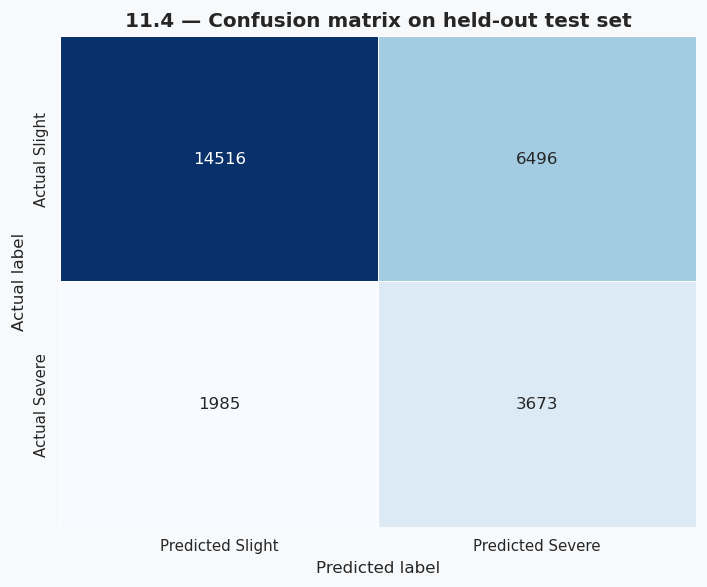

In [83]:
# 11.4 Confusion matrix

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["Actual Slight", "Actual Severe"],
    columns=["Predicted Slight", "Predicted Severe"],
)

display(cm_df)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title("11.4 — Confusion matrix on held-out test set", fontweight="bold")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

plt.tight_layout()
plt.show()

### 11.5 Normalised confusion matrix

The normalised confusion matrix is row-normalised, so each row sums to 100%.

This makes class-specific recall directly readable. The Severe row is especially important because it shows the proportion of actual Severe casualties correctly identified by the final model.

,Predicted Slight,Predicted Severe
Actual Slight,0.6908,0.3092
Actual Severe,0.3508,0.6492


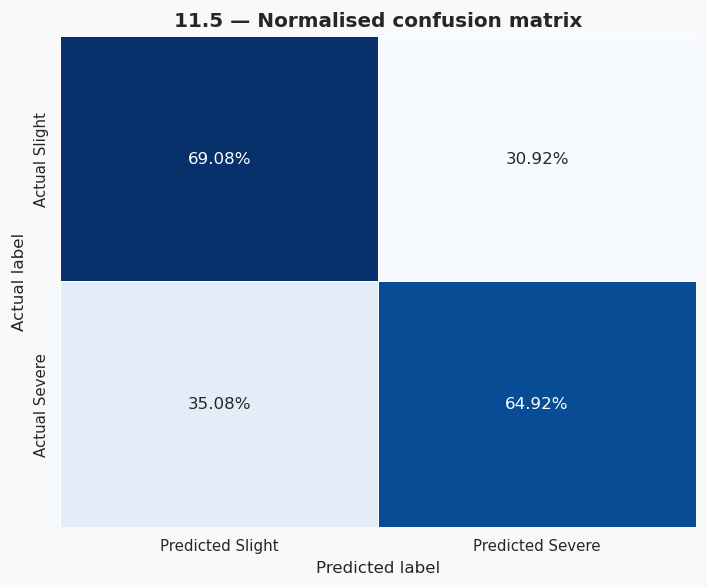

In [84]:
# 11.5 Normalised confusion matrix

cm_norm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1],
    normalize="true"
)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=["Actual Slight", "Actual Severe"],
    columns=["Predicted Slight", "Predicted Severe"],
)

display(cm_norm_df.round(4))

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title("11.5 Normalised confusion matrix", fontweight="bold")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

plt.tight_layout()
plt.show()

### 11.6 ROC curve

The ROC curve shows the trade-off between true positive rate and false positive rate across all possible thresholds. ROC-AUC is threshold-independent and complements the fixed-threshold metrics reported above.

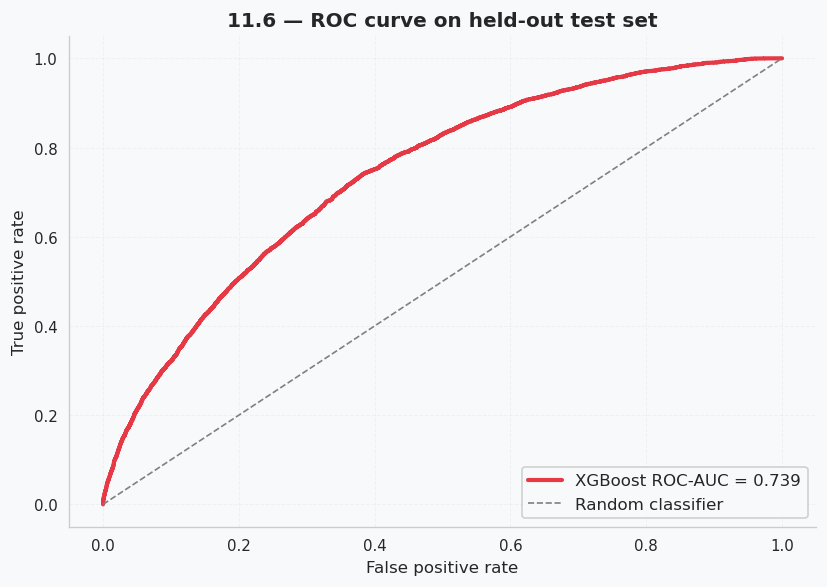

In [85]:
# 11.6 ROC curve for final selected model

fpr, tpr, _ = roc_curve(y_test, y_test_score)
roc_auc_value = roc_auc_score(y_test, y_test_score)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    fpr,
    tpr,
    linewidth=2.5,
    color=SEVERE_COL,
    label=f"{final_model_name} ROC-AUC = {roc_auc_value:.3f}",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    linewidth=1,
    label="Random classifier",
)

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("11.6 ROC curve on held-out test set", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

### 11.7 Precision-recall curve

The precision-recall curve is especially useful for imbalanced classification because it focuses on the positive Severe class.

The dashed baseline shows the Severe class prevalence in the test set. Average precision summarises the model's ranking quality for identifying Severe casualties across thresholds.

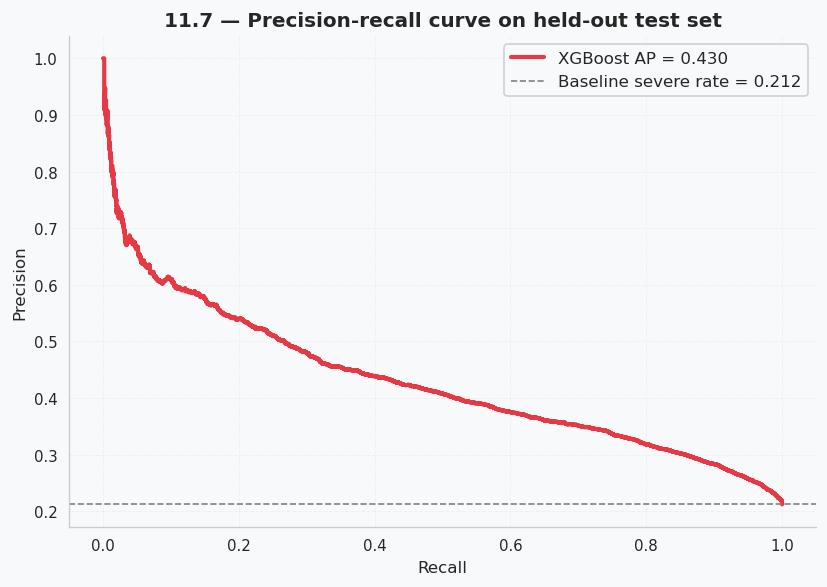

In [86]:
# 11.7 Precision-recall curve for final selected model

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_score)
ap_value = average_precision_score(y_test, y_test_score)
baseline_rate = float(y_test.mean())

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    recall_vals,
    precision_vals,
    linewidth=2.5,
    color=SEVERE_COL,
    label=f"{final_model_name} AP = {ap_value:.3f}",
)

ax.axhline(
    baseline_rate,
    linestyle="--",
    color="grey",
    linewidth=1,
    label=f"Baseline severe rate = {baseline_rate:.3f}",
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("11.7 — Precision-recall curve on held-out test set", fontweight="bold")
ax.legend(loc="upper right")
ax.grid(linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

### 11.8 Final test evaluation summary

The final summary reports the selected model, selected threshold, and held-out test performance.

These values represent the final generalisation estimate because no model or threshold choices are made after observing the test results.

***References:***

- Pedregosa et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.
- Fawcett, T. (2006). An introduction to ROC analysis. Pattern Recognition Letters, 27(8), 861–874.
- Saito, T. & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. PLOS ONE, 10(3), e0118432.

In [87]:
# 11.8 Final test evaluation summary

row = final_test_results_df.iloc[0]

print(f"""Final selected model: {final_model_name}
Selected threshold: {row['threshold']:.2f}

Held-out test performance
─────────────────────────────────────
Accuracy: {row['accuracy']:.3f}
Balanced accuracy: {row['balanced_accuracy']:.3f}
Macro-F1: {row['macro_f1']:.3f}
G-Mean: {row['gmean']:.3f}

Severe precision: {row['severe_precision']:.3f}
Severe recall: {row['severe_recall']:.3f}
Severe F1: {row['severe_f1']:.3f}
Slight recall: {row['slight_recall']:.3f}

Average precision (AP)  : {row['average_precision']:.3f}
ROC-AUC: {row['roc_auc']:.3f}

Predicted severe rate   : {row['predicted_severe_rate']:.3f}
Actual severe rate: {row['actual_severe_rate']:.3f}
""")

Final selected model: XGBoost
Selected threshold: 0.50

Held-out test performance
─────────────────────────────────────
Accuracy: 0.682
Balanced accuracy: 0.670
Macro-F1: 0.619
G-Mean: 0.670

Severe precision: 0.361
Severe recall: 0.649
Severe F1: 0.464
Slight recall: 0.691

Average precision (AP)  : 0.430
ROC-AUC: 0.739

Predicted severe rate   : 0.381
Actual severe rate: 0.212



The final XGBoost model achieved a held-out test macro-F1 of 0.619 and balanced accuracy of 0.670. Severe-class recall was 0.649, meaning the model identified approximately 65% of Severe casualties. Severe precision was lower at 0.361, showing that the model deliberately over-predicts Severe cases relative to their true prevalence. This is consistent with the safety-aware threshold decision in Section 10, where preserving Severe recall was prioritised over maximising precision.

The predicted Severe rate was 0.381 compared with an actual Severe rate of 0.212, confirming that the final model is recall-oriented. The average precision of 0.430 is substantially above the Severe-class baseline rate of 0.212, indicating that the model has useful ranking ability for identifying higher-risk casualties. The ROC-AUC of 0.739 also supports that the model separates Severe and Slight cases better than chance.

Overall, the final model provides a reasonable safety-focused trade-off: it improves Severe-casualty detection while maintaining moderate class-balanced performance on unseen data.

## Section 12: Model Interpretation with SHAP

This section interprets the final selected XGBoost model using SHAP values.

SHAP is used only after model selection, threshold selection, and final model fitting. It is not used for feature selection, hyperparameter tuning, threshold tuning, or model selection. Therefore, SHAP does not influence the final model.

To avoid using the held-out test set for interpretation, SHAP values are computed on a random sample from the training data. The aim is to identify which administrative STATS19 features most strongly influence the final model's Severe-casualty predictions.

For tree-based models such as XGBoost, SHAP values explain how each transformed feature contributes to the model output. The global importance values below are based on **mean absolute SHAP values**, so they show the ***average*** strength of each feature's contribution, not whether the feature increases or decreases risk.

**References:**

- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to 
  interpreting model predictions. *Advances in Neural Information 
  Processing Systems*, 30, 4765–4774.
- Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., 
  Nair, B., Katz, R., Himmelfarb, J., Bansal, N., & Lee, S.-I. (2020). 
  From local explanations to global understanding with explainable AI 
  for trees. *Nature Machine Intelligence*, 2, 56–67. 
  https://doi.org/10.1038/s42256-019-0138-9
- Shapley, L. S. (1953). A value for n-person games. In H. W. Kuhn & 
  A. W. Tucker (Eds.), *Contributions to the Theory of Games II* 
  (pp. 307–317). Princeton University Press.

### 12.1 Prepare transformed SHAP sample

In [88]:
#Check whether Shap Package is Installed
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP is not installed. Skipping SHAP section.")

import scipy.sparse as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Colour fallbacks in case earlier plotting colours are not available.
SEVERE_COL = globals().get("SEVERE_COL", "#E63946")
VEHICLE_COL = globals().get("VEHICLE_COL", "#2A9D8F")

assert "final_model_name" in globals(), (
    "final_model_name missing. Rerun Section 9.8 first."
)

assert "final_test_model" in globals(), (
    "final_test_model missing. Rerun Section 11 first."
)

assert final_model_name == "XGBoost", (
    "This SHAP section is written for the final XGBoost model. "
    "Rerun Section 9.8 if a different final model is currently selected."
)

if SHAP_AVAILABLE:
    print("Final model for SHAP:", final_model_name)

    # final_test_model is the final XGBoost pipeline fitted on full X_train.
    # The held-out test set is not used for SHAP.
    final_preprocessor = final_test_model.named_steps["preprocessor"]
    final_classifier = final_test_model.named_steps["classifier"]

    # Use a training-data sample for interpretation.
    # This keeps SHAP separate from held-out test evaluation.
    SHAP_SAMPLE_N = min(1000, len(X_train))

    X_shap_raw = X_train.sample(
        n=SHAP_SAMPLE_N,
        random_state=RANDOM_STATE
    )

    # Apply the fitted preprocessing pipeline.
    X_shap_processed = final_preprocessor.transform(X_shap_raw)

    # Convert to dense for easier SHAP handling on a small sample.
    if sp.issparse(X_shap_processed):
        X_shap_processed_dense = X_shap_processed.toarray()
    else:
        X_shap_processed_dense = X_shap_processed

    print("Raw SHAP sample shape:", X_shap_raw.shape)
    print("Processed SHAP sample shape:", X_shap_processed_dense.shape)

Final model for SHAP: XGBoost
Raw SHAP sample shape: (1000, 42)
Processed SHAP sample shape: (1000, 190)


### 12.2 Extract processed feature names

The model was trained after preprocessing, so SHAP operates on the transformed feature space. This includes scaled numeric features and one-hot encoded categorical levels.

The code first tries to obtain feature names directly from the fitted preprocessor. If that fails, it reconstructs the names from the numeric and categorical feature lists.

In [89]:
# 12.2 Extract processed feature names

if SHAP_AVAILABLE:
    try:
        shap_feature_names = final_preprocessor.get_feature_names_out()
    except Exception:
        # Fallback for preprocessors where get_feature_names_out is unavailable.
        assert "numeric_features" in globals(), (
            "numeric_features missing. Needed to reconstruct SHAP feature names."
        )
        assert "categorical_features" in globals(), (
            "categorical_features missing. Needed to reconstruct SHAP feature names."
        )
        #creates names for numeric features.
        num_feature_names = np.array([
            f"num__{col}" for col in numeric_features
        ])

        #extracts names for the one-hot encoded categorical features.
        ohe = final_preprocessor.named_transformers_["cat"].named_steps["onehot"]

        cat_feature_names = ohe.get_feature_names_out(categorical_features)
        cat_feature_names = np.array([
            f"cat__{name}" for name in cat_feature_names
        ])

        shap_feature_names = np.concatenate([
            num_feature_names,
            cat_feature_names
        ])

    assert len(shap_feature_names) == X_shap_processed_dense.shape[1], (
        "Feature-name count does not match the processed SHAP matrix."
    )

    print("Number of SHAP features:", len(shap_feature_names))
    print("First 20 SHAP feature names:")
    print(shap_feature_names[:20])

Number of SHAP features: 190
First 20 SHAP feature names:
['num__is_weekend' 'num__is_night' 'num__is_rush_hour'
 'num__is_weekend_night' 'num__ctx_any_motorcycle' 'num__ctx_any_cycle'
 'num__ctx_any_hgv' 'num__ctx_any_young_driver'
 'num__ctx_any_elderly_driver' 'num__ctx_any_skidding'
 'num__ctx_any_left_carriageway' 'num__ctx_any_front_impact'
 'num__speed_limit' 'num__number_of_vehicles' 'num__hour' 'num__month'
 'num__age_of_casualty' 'num__age_of_driver' 'num__age_of_vehicle'
 'num__ctx_mean_driver_age']


### 12.3 Compute SHAP values

***TreeExplainer*** is used because the final model is XGBoost. The SHAP values explain the fitted classifier after preprocessing.

For XGBoost classifiers, SHAP values are usually on the model-margin/log-odds scale rather than direct probability units. Therefore, the importance values should be interpreted as relative contribution strength, not percentage change in predicted probability.

In [90]:
# 12.3 Compute SHAP values

if SHAP_AVAILABLE:
    # TreeExplainer is appropriate for XGBoost/tree-based models.
    explainer = shap.TreeExplainer(final_classifier)

    shap_values = explainer.shap_values(X_shap_processed_dense)

    # Some SHAP versions return a list for binary classification.
    if isinstance(shap_values, list):
        shap_values_array = shap_values[1]
    else:
        shap_values_array = shap_values

    # Some SHAP versions return a 3D array for classifiers.
    if hasattr(shap_values_array, "ndim") and shap_values_array.ndim == 3:
        shap_values_array = shap_values_array[:, :, 1]

    print("SHAP values shape:", shap_values_array.shape)

    assert shap_values_array.shape[1] == X_shap_processed_dense.shape[1], (
        "SHAP values do not match the processed feature matrix."
    )

SHAP values shape: (1000, 190)


### 12.4 Global SHAP importance for transformed features

The table and plot below show the transformed features with the largest mean absolute SHAP values. For categorical variables, individual one-hot encoded levels appear separately at this stage.

Top 20 transformed SHAP features:


,feature,mean_abs_shap
0,cat__casualty_type_21.0,0.687872
1,cat__casualty_type_10.0,0.533475
2,cat__vehicle_type_17.0,0.457322
3,cat__skidding_and_overturning_Missing,0.429142
4,cat__weather_conditions_Missing,0.406785
5,num__ctx_mean_vehicle_age,0.395934
6,cat__first_road_class_2,0.384204
7,cat__casualty_type_19.0,0.380590
8,cat__casualty_type_20.0,0.369362
9,num__age_of_driver,0.354134


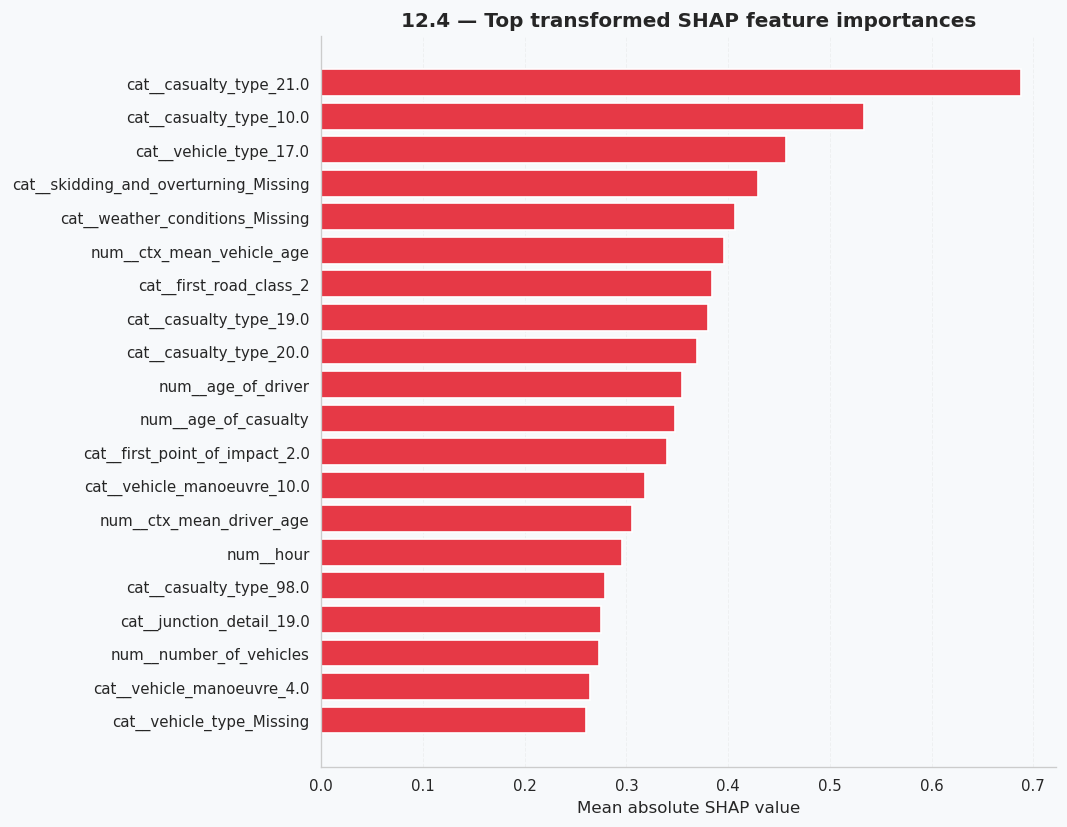

In [91]:
# 12.4 SHAP global feature importance

if SHAP_AVAILABLE:
    mean_abs_shap = np.abs(shap_values_array).mean(axis=0)

    shap_importance_df = (
        pd.DataFrame({
            "feature": shap_feature_names,
            "mean_abs_shap": mean_abs_shap #calculates mean absolute SHAP value for each transformed feature.
        })
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    print("Top 20 transformed SHAP features:")
    display(shap_importance_df.head(20))

    top_n = 20
    top_shap = (
        shap_importance_df
        .head(top_n)
        .sort_values("mean_abs_shap", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.barh(
        top_shap["feature"],
        top_shap["mean_abs_shap"],
        color=SEVERE_COL,
        edgecolor="white",
        linewidth=1
    )

    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_title(
        "12.4 — Top transformed SHAP feature importances",
        fontweight="bold"
    )
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)

    plt.tight_layout()
    plt.show()

### 12.5 SHAP summary plot

For numeric features, the colour scale shows whether high or low feature values are associated with positive or negative SHAP contributions. For one-hot encoded categorical features, high values usually mean that the category is present, while low values mean it is absent.

C:\Users\local_psxu1\Temp\ipykernel_45296\945367807.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


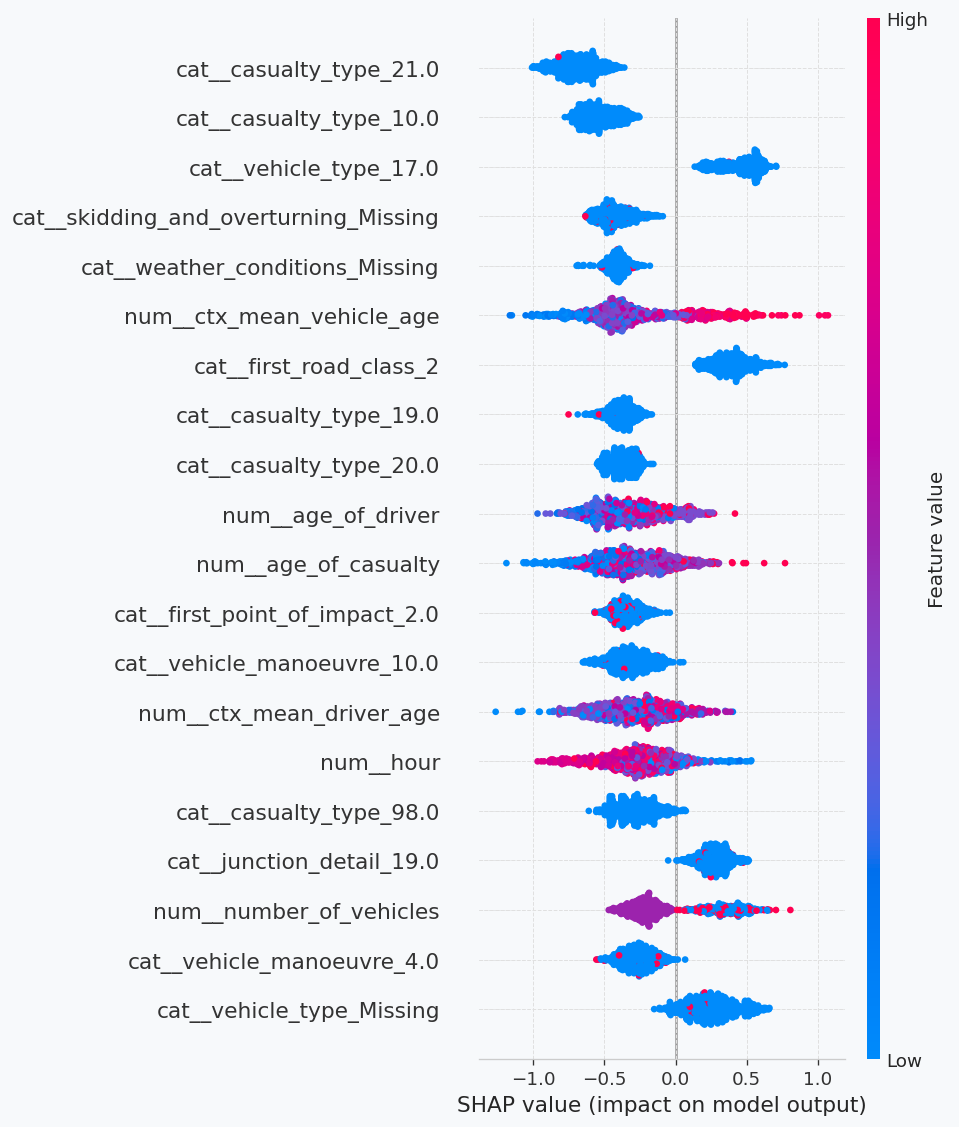

In [92]:
# 12.5 SHAP summary plot

if SHAP_AVAILABLE:
    shap.summary_plot(
        shap_values_array,
        X_shap_processed_dense,
        feature_names=shap_feature_names,
        max_display=20,
        show=True
    )

### 12.6 Grouped SHAP importance by original STATS19 feature

The transformed SHAP table separates one-hot encoded levels. For interpretation, these are grouped back to their original STATS19 variables by summing mean absolute SHAP values across levels belonging to the same original feature.

This gives a more readable view of which original variables are most influential overall.

Top 20 grouped SHAP predictors:


,original_feature,mean_abs_shap
0,casualty_type,3.867032
1,vehicle_manoeuvre,2.639596
2,vehicle_type,2.158228
3,weather_conditions,1.394487
4,road_type,0.961895
5,vehicle_leaving_carriageway,0.920412
6,junction_detail,0.891038
7,first_road_class,0.868105
8,skidding_and_overturning,0.862623
9,first_point_of_impact,0.850188


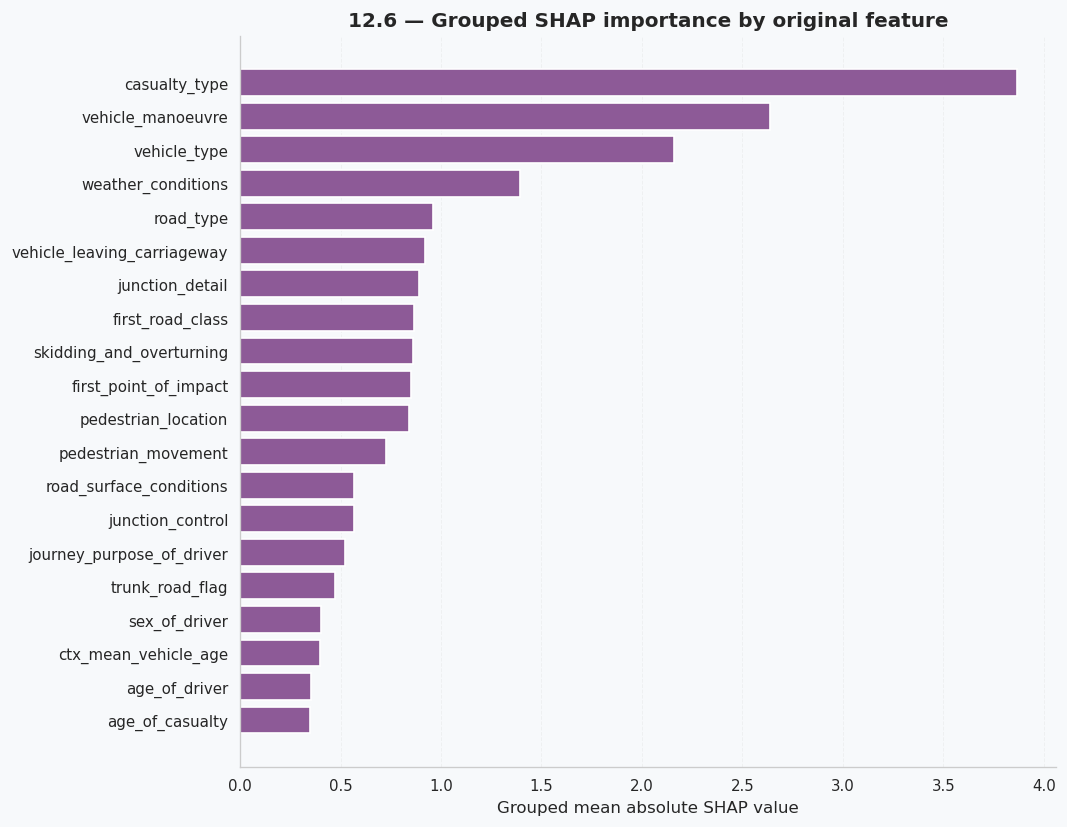

In [93]:
# 12.6 Grouped SHAP importance by original feature

if SHAP_AVAILABLE:
    assert "selected_features" in globals(), (
        "selected_features missing. Needed to group SHAP features."
    )

    def simplify_feature_name(name):
        """
        Convert transformed feature names back to original feature names.
        Longest-prefix matching prevents errors such as:
        is_weekend_night being grouped under is_weekend.
        """
        name = (   #This removes preprocessing prefixes.
            str(name)
            .replace("num__", "")
            .replace("cat__", "")
        )

        #This checks original feature names from longest to shortest.
        for original_col in sorted(selected_features, key=len, reverse=True):
            if name == original_col or name.startswith(original_col + "_"):
                return original_col

        return name

    #This adds the original feature group.
    shap_importance_df["original_feature"] = shap_importance_df["feature"].apply(
        simplify_feature_name
    )

    grouped_shap = (
        shap_importance_df
        .groupby("original_feature", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    print("Top 20 grouped SHAP predictors:")
    display(grouped_shap.head(20))

    top_grouped = (
        grouped_shap
        .head(20)
        .sort_values("mean_abs_shap", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.barh(
        top_grouped["original_feature"],
        top_grouped["mean_abs_shap"],
        color=VEHICLE_COL,
        edgecolor="white",
        linewidth=1
    )

    ax.set_xlabel("Grouped mean absolute SHAP value")
    ax.set_title(
        "12.6 — Grouped SHAP importance by original feature",
        fontweight="bold"
    )
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)

    plt.tight_layout()
    plt.show()

### 12.7 Top grouped predictors

The ranked list below summarises the strongest original STATS19 predictors according to grouped mean absolute SHAP values.

In [94]:
# 12.7 Print top grouped predictors

if SHAP_AVAILABLE:
    print("Top 10 grouped SHAP predictors:")

    for rank, (_, row) in enumerate(grouped_shap.head(10).iterrows(), start=1):
        print(
            f"{rank}. {row['original_feature']} — "
            f"{row['mean_abs_shap']:.4f}"
        )

Top 10 grouped SHAP predictors:
1. casualty_type — 3.8670
2. vehicle_manoeuvre — 2.6396
3. vehicle_type — 2.1582
4. weather_conditions — 1.3945
5. road_type — 0.9619
6. vehicle_leaving_carriageway — 0.9204
7. junction_detail — 0.8910
8. first_road_class — 0.8681
9. skidding_and_overturning — 0.8626
10. first_point_of_impact — 0.8502


### 12.8 Section 12 summary

SHAP was used only after final model selection to interpret the fitted XGBoost model. It was not used to select features, tune hyperparameters, choose the classification threshold, or alter the final model.

The transformed SHAP results show that several individual encoded categories, especially within casualty_type, vehicle_type, skidding_and_overturning, weather_conditions, and first_road_class, strongly influence the model output. Numeric context variables such as ctx_mean_vehicle_age, age_of_driver, age_of_casualty, ctx_mean_driver_age, and hour also appear among the most influential transformed features.

The grouped SHAP results provide the clearest interpretation at the original STATS19 feature level. The most influential grouped predictors are casualty_type, vehicle_manoeuvre, vehicle_type, weather_conditions, road_type, vehicle_leaving_carriageway, junction_detail, first_road_class, skidding_and_overturning`, and first_point_of_impact.

These results suggest that the final XGBoost model relies mainly on casualty role/type, vehicle characteristics, manoeuvre information, road environment, weather, junction structure, and impact-related variables when predicting severe casualty outcomes.

One limitation is that grouped SHAP importance is computed by summing mean absolute SHAP values across one-hot encoded levels. Therefore, categorical variables with many encoded levels may receive larger grouped importance values partly because they have more levels. The grouped results should therefore be interpreted as model-behaviour evidence rather than causal evidence.

Overall, SHAP supports the model's face validity: the most important predictors are plausible road-safety factors and are consistent with the modelling objective of identifying severe casualty risk.


## Section 13: Oversampling Sensitivity Analysis

This section tests whether oversampling the minority Severe class changes the performance of the final XGBoost model.

The main comparison is between:

1. **Cost-sensitive XGBoost**  the tuned XGBoost model using scale_pos_weight to handle class imbalance.
2. **Oversampled XGBoost**  the same tuned XGBoost hyperparameters, but with RandomOverSampler applied inside an imblearn pipeline and scale_pos_weight=1.

This is a supplementary sensitivity experiment, not the main modelling pipeline. The final model has already been selected in Section 9, and the final threshold has already been selected in Section 10. The results in this section are used only to discuss whether oversampling changes the performance pattern; they are not used to revise the final model.

Oversampling is applied only inside the training pipeline. The held-out test set is never oversampled.

RandomOverSampler is used instead of SMOTE because the preprocessing pipeline includes one-hot encoded categorical variables. SMOTE-based interpolation on one-hot encoded features can create fractional indicator values, which do not represent valid categories. Random oversampling avoids this by duplicating existing minority-class observations instead of synthesising new feature values.

Both sensitivity models are evaluated on the held-out test set using the fixed threshold selected in Section 10.

**References:**

- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: 
  A Python toolbox to tackle the curse of imbalanced datasets in machine 
  learning. *Journal of Machine Learning Research*, 18(17), 1–5.
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). 
  SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial 
  Intelligence Research*, 16, 321–357.
- He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE 
  Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284. 
  https://doi.org/10.1109/TKDE.2008.239

### 13.1 Import oversampling tools

In [95]:
#RandomOverSampler duplicates existing minority-class examples.
#ImbPipeline is needed because samplers like RandomOverSampler use fit_resample(), 
#not the normal sklearn fit() / transform() pattern.
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import RandomOverSampler
    IMBLEARN_AVAILABLE = True
    print("imblearn is available.")
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("imblearn is not available. Oversampling sensitivity experiment will be skipped.")

# Make the section robust if XGBoost was not imported in the current notebook state.
if "XGBOOST_AVAILABLE" not in globals():
    try:
        from xgboost import XGBClassifier
        XGBOOST_AVAILABLE = True
    except ImportError:
        XGBOOST_AVAILABLE = False
        print("XGBoost is not available. Oversampling sensitivity experiment will be skipped.")
else:
    if XGBOOST_AVAILABLE:
        from xgboost import XGBClassifier

# Use the threshold selected in Section 10.
# If Section 10 was skipped, fall back to 0.50, but print this clearly.
if "selected_threshold" in globals():
    sensitivity_threshold = selected_threshold
else:
    sensitivity_threshold = 0.50
    print("selected_threshold not found. Using default threshold = 0.50.")

print(f"Sensitivity evaluation threshold: {sensitivity_threshold:.2f}")

imblearn is available.
Sensitivity evaluation threshold: 0.50


### 13.2 Define cost-sensitive and oversampled XGBoost pipelines

In [96]:

if IMBLEARN_AVAILABLE and XGBOOST_AVAILABLE:

    assert "tuned_models" in globals(), (
        "tuned_models missing. Rerun Section 8."
    )

    assert "XGBoost" in tuned_models, (
        "Tuned XGBoost model missing. Rerun Section 8."
    )

    assert "FoldBalancedXGBClassifier" in globals(), (
        "FoldBalancedXGBClassifier missing. Rerun Section 7.1."
    )

    assert "preprocessor" in globals(), (
        "preprocessor missing. Rerun preprocessing/model setup sections."
    )

    # Extract the tuned XGBoost hyperparameters selected in Section 8.
    tuned_xgb_classifier = tuned_models["XGBoost"].named_steps["classifier"]
    tuned_xgb_all_params = tuned_xgb_classifier.get_params()

    tuned_xgb_params = {
        "n_estimators": tuned_xgb_all_params["n_estimators"],
        "max_depth": tuned_xgb_all_params["max_depth"],
        "learning_rate": tuned_xgb_all_params["learning_rate"],
        "subsample": tuned_xgb_all_params["subsample"],
        "colsample_bytree": tuned_xgb_all_params["colsample_bytree"],
        "min_child_weight": tuned_xgb_all_params["min_child_weight"],
    }

    assert all(value is not None for value in tuned_xgb_params.values()), (
        "One or more tuned XGBoost hyperparameters is None. "
        "Check tuned_models['XGBoost'].named_steps['classifier'].get_params()."
    )

    print("Tuned XGBoost hyperparameters used for sensitivity experiment:")
    print(tuned_xgb_params)

    # Arm 1: main cost-sensitive XGBoost.
    # FoldBalancedXGBClassifier recomputes scale_pos_weight from the labels
    # seen during each fit call.
    cost_sensitive_xgb_pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", FoldBalancedXGBClassifier(
                **tuned_xgb_params,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    )

    # Arm 2: RandomOverSampler + XGBoost.
    # RandomOverSampler duplicates existing Severe-class rows after preprocessing.
    # scale_pos_weight is set to 1 to avoid handling imbalance twice.
    ros_xgb_pipeline = ImbPipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("oversample", RandomOverSampler(
                random_state=RANDOM_STATE
            )),
            ("classifier", XGBClassifier(
                **tuned_xgb_params,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                scale_pos_weight=1,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    )

    print("Cost-sensitive and oversampled XGBoost pipelines created.")

else:
    print("Oversampling sensitivity pipelines not created.")

Tuned XGBoost hyperparameters used for sensitivity experiment:
{'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 3}
Cost-sensitive and oversampled XGBoost pipelines created.


### 13.3 Evaluation helper for sensitivity experiment

In [97]:
def evaluate_probability_model_at_threshold(
    model_name,
    fitted_model,
    X_eval,
    y_eval,
    threshold=0.50
):
    """
    Evaluate a fitted binary classifier at a fixed threshold.

    Positive class:
        Severe = 1

    Returns threshold-dependent metrics and ranking metrics.
    """
    if hasattr(fitted_model, "predict_proba"):
        y_score = fitted_model.predict_proba(X_eval)[:, 1]
    elif hasattr(fitted_model, "decision_function"):
        y_score = fitted_model.decision_function(X_eval)
    else:
        raise AttributeError(
            "The fitted model must provide predict_proba or decision_function."
        )

    y_pred = (y_score >= threshold).astype(int)

    recall_severe = recall_score(
        y_eval,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall_slight = recall_score(
        y_eval,
        y_pred,
        pos_label=0,
        zero_division=0
    )

    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "macro_f1": f1_score(
            y_eval,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "gmean": float(np.sqrt(recall_severe * recall_slight)),
        "severe_precision": precision_score(
            y_eval,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "severe_recall": recall_severe,
        "severe_f1": f1_score(
            y_eval,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "slight_recall": recall_slight,
        "predicted_severe_rate": y_pred.mean(),
        "actual_severe_rate": y_eval.mean(),
        "average_precision": average_precision_score(y_eval, y_score),
        "roc_auc": roc_auc_score(y_eval, y_score)
    }


print("Sensitivity evaluation helper defined.")

Sensitivity evaluation helper defined.


### 13.4 Fit and evaluate oversampling sensitivity models

In [98]:
if IMBLEARN_AVAILABLE and XGBOOST_AVAILABLE:

    sensitivity_rows = []

    sensitivity_models = {
        "XGBoost cost-sensitive": cost_sensitive_xgb_pipeline,
        "XGBoost + RandomOverSampler": ros_xgb_pipeline
    }

    for model_name, pipeline in sensitivity_models.items():
        print(f"Fitting sensitivity model: {model_name}")

        # Clone so each arm is fitted independently from scratch.
        fitted_pipeline = clone(pipeline)
        fitted_pipeline.fit(X_train, y_train)

        result = evaluate_probability_model_at_threshold(
            model_name=model_name,
            fitted_model=fitted_pipeline,
            X_eval=X_test,
            y_eval=y_test,
            threshold=sensitivity_threshold
        )

        sensitivity_rows.append(result)

    sensitivity_comparison_df = pd.DataFrame(sensitivity_rows)

    metric_cols = [
        "threshold",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "gmean",
        "severe_precision",
        "severe_recall",
        "severe_f1",
        "slight_recall",
        "predicted_severe_rate",
        "actual_severe_rate",
        "average_precision",
        "roc_auc"
    ]

    sensitivity_comparison_df[metric_cols] = (
        sensitivity_comparison_df[metric_cols].round(4)
    )

    print("Oversampling sensitivity comparison:")
    display(sensitivity_comparison_df[["model"] + metric_cols])

else:
    sensitivity_comparison_df = pd.DataFrame()
    print("Oversampling sensitivity experiment skipped.")

Fitting sensitivity model: XGBoost cost-sensitive
Fitting sensitivity model: XGBoost + RandomOverSampler
Oversampling sensitivity comparison:


,model,threshold,accuracy,balanced_accuracy,macro_f1,gmean,severe_precision,severe_recall,severe_f1,slight_recall,predicted_severe_rate,actual_severe_rate,average_precision,roc_auc
0,XGBoost cost-sensitive,0.5,0.6820,0.6700,0.6190,0.6697,0.3612,0.6492,0.4641,0.6908,0.3813,0.2121,0.4297,0.7393
1,XGBoost + RandomOverSampler,0.5,0.6865,0.6664,0.6199,0.6655,0.3628,0.6315,0.4609,0.7014,0.3693,0.2121,0.4284,0.7374


### 13.5 Plot oversampling sensitivity comparison

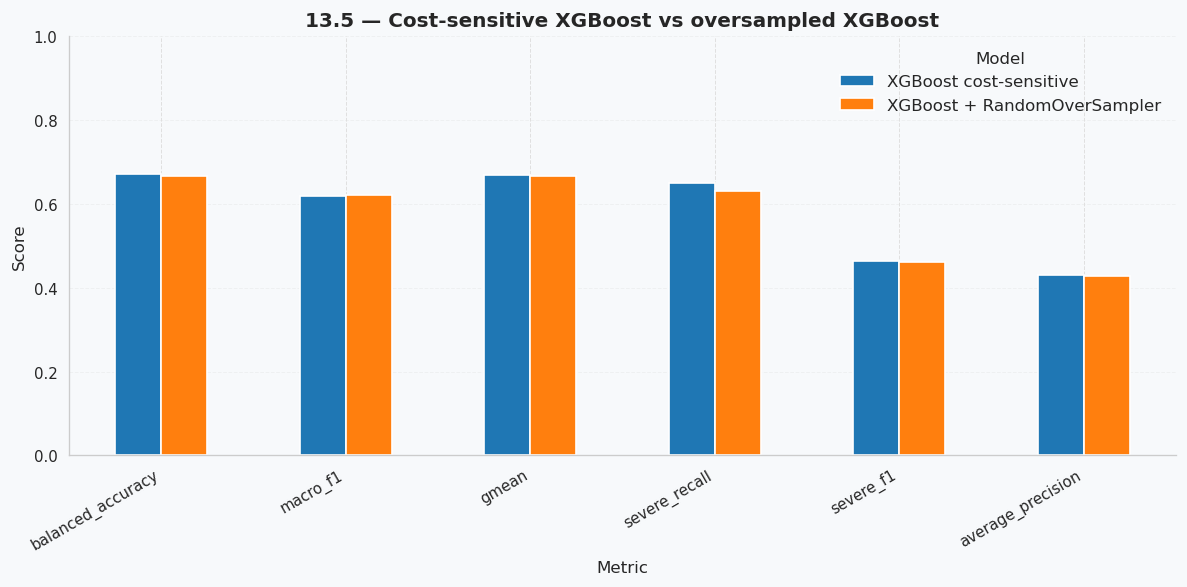

In [99]:
if IMBLEARN_AVAILABLE and XGBOOST_AVAILABLE and not sensitivity_comparison_df.empty:

    plot_metrics = [
        "balanced_accuracy",
        "macro_f1",
        "gmean",
        "severe_recall",
        "severe_f1",
        "average_precision"
    ]

    plot_df = sensitivity_comparison_df.set_index("model")[plot_metrics].T

    ax = plot_df.plot(
        kind="bar",
        figsize=(10, 5),
        edgecolor="white"
    )

    ax.set_title(
        "13.5 — Cost-sensitive XGBoost vs oversampled XGBoost",
        fontweight="bold"
    )
    ax.set_ylabel("Score")
    ax.set_xlabel("Metric")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(title="Model", frameon=False)

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

else:
    print("Oversampling sensitivity plot unavailable.")

### 13.6 Oversampling sensitivity conclusion

In [100]:
if IMBLEARN_AVAILABLE and XGBOOST_AVAILABLE and not sensitivity_comparison_df.empty:

    main_row = sensitivity_comparison_df.loc[
        sensitivity_comparison_df["model"] == "XGBoost cost-sensitive"
    ].iloc[0]

    ros_row = sensitivity_comparison_df.loc[
        sensitivity_comparison_df["model"] == "XGBoost + RandomOverSampler"
    ].iloc[0]
    
    #This calculates how much RandomOverSampler changed each metric compared with cost-sensitive XGBoost.
    changes = {
        "Balanced accuracy": ros_row["balanced_accuracy"] - main_row["balanced_accuracy"],
        "Macro-F1": ros_row["macro_f1"] - main_row["macro_f1"],
        "G-Mean": ros_row["gmean"] - main_row["gmean"],
        "Severe precision": ros_row["severe_precision"] - main_row["severe_precision"],
        "Severe recall": ros_row["severe_recall"] - main_row["severe_recall"],
        "Severe F1": ros_row["severe_f1"] - main_row["severe_f1"],
        "Average precision": ros_row["average_precision"] - main_row["average_precision"],
        "ROC-AUC": ros_row["roc_auc"] - main_row["roc_auc"],
        "Predicted severe rate": (
            ros_row["predicted_severe_rate"] -
            main_row["predicted_severe_rate"]
        )
    }

    print("Oversampling sensitivity changes:")
    for metric, change in changes.items():
        print(f"{metric:22s}: {change:+.4f}")

    recall_change = changes["Severe recall"]
    precision_change = changes["Severe precision"]
    macro_f1_change = changes["Macro-F1"]
    ap_change = changes["Average precision"]

    if recall_change > 0 and precision_change < 0:
        print(
            "\nRandom oversampling increased Severe recall but reduced Severe precision. "
            "This indicates a recall-precision trade-off rather than a clear overall improvement."
        )
    elif recall_change > 0 and precision_change >= 0:
        print(
            "\nRandom oversampling improved Severe recall without reducing Severe precision. "
            "This suggests oversampling may be beneficial for Severe-class detection."
        )
    elif recall_change <= 0 and ap_change > 0:
        print(
            "\nRandom oversampling improved average precision but did not improve Severe recall "
            "at the fixed threshold. This suggests better ranking quality but no fixed-threshold recall gain."
        )
    else:
        print(
            "\nRandom oversampling did not improve Severe recall or average precision over "
            "cost-sensitive XGBoost."
        )

    if macro_f1_change > 0:
        print(
            "Macro-F1 increased slightly under RandomOverSampler, "
            "but the change is very small and does not outweigh the reduction "
            "in Severe recall, G-Mean, Severe F1, AP, and ROC-AUC."
        )
    elif macro_f1_change < 0:
        print("Macro-F1 decreased under RandomOverSampler.")
    else:
        print("Macro-F1 was unchanged under RandomOverSampler.")

else:
    print("Oversampling sensitivity conclusion unavailable because experiment was skipped.")


Oversampling sensitivity changes:
Balanced accuracy     : -0.0036
Macro-F1              : +0.0009
G-Mean                : -0.0042
Severe precision      : +0.0016
Severe recall         : -0.0177
Severe F1             : -0.0032
Average precision     : -0.0013
ROC-AUC               : -0.0019
Predicted severe rate : -0.0120

Random oversampling did not improve Severe recall or average precision over cost-sensitive XGBoost.
Macro-F1 increased slightly under RandomOverSampler, but the change is very small and does not outweigh the reduction in Severe recall, G-Mean, Severe F1, AP, and ROC-AUC.


### 13.6 Oversampling sensitivity conclusion

The oversampling sensitivity analysis showed that RandomOverSampler did not provide a meaningful improvement over the main cost-sensitive XGBoost approach.

RandomOverSampler produced a very small increase in macro-F1, from 0.6190 to 0.6199. However, this gain was negligible and came with worse performance on several more relevant metrics. Severe-class recall decreased from 0.6492 to 0.6315, G-Mean decreased from 0.6697 to 0.6655, Severe F1 decreased from 0.4641 to 0.4609, average precision decreased from 0.4297 to 0.4284, and ROC-AUC decreased from 0.7393 to 0.7374.

This indicates that random oversampling does not improve the model's ability to identify Severe casualties. Instead, it slightly shifts the prediction behaviour while weakening several class-balanced and ranking metrics.

Therefore, the main cost-sensitive XGBoost model remains the preferred final model. Random oversampling is reported only as a sensitivity check and is not carried forward.

## Appendix: Reproducibility Checklist

This checklist is adapted from the AAAI reproducibility guidance included in the COMP4030 coursework instructions.

**Any code required for pre-processing data is included or accessible programmatically.**

✅ All preprocessing code is included in Sections 1–6 of this notebook. The raw STATS19 2023 data files are publicly available from the UK Department for Transport road safety open data source. No external preprocessing scripts are required.

---

**All source code required for conducting and analysing the experiments is included.**

✅ All modelling, hyperparameter tuning, cross-validation, threshold analysis, held-out test evaluation, SHAP interpretation, and oversampling sensitivity code is included in this notebook.

---

**All source code implementing new methods has comments detailing the implementation, with references where appropriate.**

✅ No new machine-learning algorithm is proposed in this work. The custom FoldBalancedXGBClassifier wrapper in Section 7.1 is commented to explain why scale_pos_weight is recomputed within each fold. The simplify_feature_name function in Section 12.6 is also commented and explains the longest-prefix grouping logic used for grouped SHAP interpretation.

---

**If an algorithm depends on randomness, the method used for setting seeds is described sufficiently to allow replication of results.**

✅ A single global random seed, RANDOM_STATE = 42, is used throughout the notebook. This seed is passed explicitly to all randomised components, including the train/test split, StratifiedGroupKFold, GroupShuffleSplit, RandomizedSearchCV, RandomForestClassifier, XGBClassifier, FoldBalancedXGBClassifier, RandomOverSampler, and SHAP sampling.

---

**The paper describes the evaluation metrics used and explains and justifies the motivation for choosing these metrics.**

✅ Macro-F1 is used as the primary evaluation metric because the target variable is imbalanced, and macro-F1 gives equal weight to both the Slight and Severe classes. G-Mean, balanced accuracy, Severe precision, Severe recall, Severe F1, Slight recall, average precision, and ROC-AUC are also reported. Together, these metrics provide a fuller picture of both threshold-dependent classification performance and threshold-independent ranking performance.

---

**The paper states the number of runs used to compute each reported result.**

✅ Untuned baseline results in Section 7 are computed using 10-fold stratified grouped cross-validation. Tuned-vs-untuned comparison results in Section 9 are also computed using the same 10-fold grouped CV protocol.

✅ Hyperparameter tuning in Section 8 uses 3-fold stratified grouped cross-validation for computational feasibility.

✅ The final held-out test evaluation in Section 11 is performed once, after model selection and threshold selection are complete.

✅ SHAP interpretation in Section 12 is computed on a random sample of 1,000 training rows.

✅ The oversampling sensitivity experiment in Section 13 compares two fitted XGBoost pipelines on the held-out test set as a supplementary analysis.

---

**Analysis of experiments goes beyond single-dimensional summaries of performance to include measures of variation or distributional information.**

✅ Cross-validation results report both the mean and standard deviation across the 10 grouped folds in Sections 7.5 and 9.4. Full fold-level result tables are also retained in untuned_fold_scores_df, tuned_fold_scores_df, and comparison_fold_scores_df, so the fold-level distribution of performance can be inspected directly.

---

**The significance of any improvement or decrease in performance is judged using appropriate statistical tests.**

✅ Exploratory Wilcoxon signed-rank tests are reported in Section 9.7 for paired fold-level macro-F1 comparisons across the 10 grouped folds. These tests are explicitly labelled as exploratory because cross-validation folds are not fully independent.

---

**The paper lists all final hyperparameters used in the experiments.**

✅ Final selected hyperparameters are reported in Section 8.8 and summarised below.

| Model | Final hyperparameters |
|---|---|
| Logistic Regression | C = 0.5, penalty = "l2", solver = "liblinear", class_weight = "balanced", max_iter = 1000 |
| Random Forest | n_estimators = 100, max_depth = None, min_samples_leaf = 10, max_features = "sqrt", class_weight = "balanced" |
| XGBoost | n_estimators = 200, max_depth = 6, learning_rate = 0.2, subsample = 0.9, colsample_bytree = 0.7, min_child_weight = 3, scale_pos_weight recomputed for each fit |

---

**The paper states the number and range of values tried per hyperparameter during development, along with the criterion used for selecting the final parameter setting.**

✅ Logistic Regression evaluated 6 candidates using:

- C ∈ {0.01, 0.1, 0.5, 1.0, 5.0, 10.0}
- penalty = "l2" fixed
- class_weight = "balanced" fixed

The selected Logistic Regression configuration was chosen by highest mean 3-fold CV macro-F1.

✅ Random Forest evaluated 15 randomly sampled candidates from a 64-combination search space:

- n_estimators ∈ {100, 200}
- max_depth ∈ {10, 15, 20, None}
- min_samples_leaf ∈ {5, 10, 20, 30}
- max_features ∈ {"sqrt", "log2"}
- class_weight = "balanced" fixed

An additional sentinel evaluation of the untuned Random Forest configuration was also performed. The sentinel configuration outperformed the sampled Random Forest candidates and was retained as the selected Random Forest candidate.

✅ XGBoost evaluated 15 randomly sampled candidates from a 3,840-combination search space:

- n_estimators ∈ {100, 200, 300, 500}
- max_depth ∈ {3, 4, 5, 6}
- learning_rate ∈ {0.01, 0.05, 0.08, 0.1, 0.2}
- subsample ∈ {0.7, 0.8, 0.9, 1.0}
- colsample_bytree ∈ {0.7, 0.8, 1.0}
- min_child_weight ∈ {1, 3, 5, 10}

The selected XGBoost configuration was chosen by highest mean 3-fold CV macro-F1.

✅ All hyperparameter searches used RandomizedSearchCV with REFIT_METRIC = "macro_f1" and tuning_cv = StratifiedGroupKFold(n_splits = 3, shuffle = True, random_state = 42).

---

**Final reproducibility note**

The full pipeline is leakage-controlled. Preprocessing is included inside sklearn or imblearn pipelines, so imputation, scaling, one-hot encoding, oversampling, and model fitting are learned only from the relevant training split. Grouped cross-validation is used to prevent casualties from the same collision appearing in both training and validation folds. The held-out test set is used only once for final evaluation after model selection and threshold selection are complete.